In [3]:
from GtApp import GtApp
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from astropy.table import Table, hstack
import xml.etree.ElementTree as ET
from astropy.coordinates import SkyCoord
import astropy.units as u
from LATSourceModel import SourceList
from scipy.interpolate import interp1d
import warnings
import numpy as np
import emcee
from chainconsumer import ChainConsumer
import matplotlib.pyplot as plt
from multiprocessing import Pool
import time
from scipy.interpolate import CubicSpline
from scipy.integrate import dblquad
import gt_apps as gt_apps

## Data preparation part

In [4]:
#Space craft merged file can be downloaded from https://heasarc.gsfc.nasa.gov/FTP/fermi/data/lat/mission/spacecraft/
#Be advised that since SC file is large, one might experience getting a wrong file from the data base
#In such case, re-try downloading the file several times since by the time of update of the file might cause you the damaged file.
#For photon event weekly file, you can download from https://heasarc.gsfc.nasa.gov/db-perl/W3Browse/w3query.pl
#On the website, you can try "Create Download Script" to easilly download all-sky weekly files

#You can download weekly photon file using command wget -m -P . -nH --cut-dirs=5 -np -e robots=off -N https://heasarc.gsfc.nasa.gov/FTP/fermi/data/lat/weekly/photon/
#The above will download weekly photon files in your current directory

In [2]:
def galactic_to_equatorial(l, b):
    # Create a SkyCoord object with Galactic coordinates
    galactic_coord = SkyCoord(l=l*u.degree, b=b*u.degree, frame='galactic')

    # Convert to J2000 equatorial coordinates
    equatorial_coord = galactic_coord.icrs

    # Extract RA and Dec
    ra = equatorial_coord.ra.degree
    dec = equatorial_coord.dec.degree

    return ra, dec

In [3]:
def equatorial_to_galactic(ra, dec):
    # Create a SkyCoord object with equatorial coordinates (J2000)
    equatorial_coord = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame='icrs')

    # Convert to Galactic coordinates
    galactic_coord = equatorial_coord.galactic

    # Extract l and b
    l = galactic_coord.l.degree
    b = galactic_coord.b.degree

    return l, b

In [7]:
!ls ./all_sky/data/*photon_weekly* > photon_data.txt

In [4]:
RA, DEC = galactic_to_equatorial(0, 0) #Coordinate for GC

In [6]:

# Define initial bins
first_bins = np.array([0.275, 0.357, 0.464, 0.603, 0.784, 1.02, 1.32, 1.72, 2.24, 2.91, 3.78, 4.91])
second_bins = np.array([4.91, 10.8, 23.7, 51.9])

# Calculate logarithmic widths
first_log_width = np.log10(first_bins[1]) - np.log10(first_bins[0])
second_log_width = np.log10(second_bins[1]) - np.log10(second_bins[0])

# Extend bins using the same log width as first_bins up to where it matches second_bins
extended_bins = list(first_bins)

# Use the wider log width to extend beyond the current range to 500 GeV
while extended_bins[-1] < 1000:
    next_bin = extended_bins[-1] * 10**second_log_width
    if next_bin > 1000:
        break
    extended_bins.append(next_bin)

# Convert to numpy array for easier manipulation
extended_bins = np.array(extended_bins)

# Save the bin definitions to a text file
with open('./GC_analysis/bin_definitions.txt', 'w') as f:
    for i in range(len(extended_bins) - 1):
        f.write(f"{extended_bins[i]:.3f} {extended_bins[i+1]:.3f}\n")

# Print confirmation
print("Bin definitions saved to 'bin_definitions.txt'.")

bindef=GtApp('gtbindef')
bindef['bintype']='E'
bindef['binfile']='./GC_analysis/bin_definitions.txt'
bindef['outfile']='./GC_analysis/bin_definitions.fits'
bindef['energyunits'] = 'GeV'
bindef.run()

Bin definitions saved to 'bin_definitions.txt'.
time -p gtbindef bintype="E" binfile=./GC_analysis/bin_definitions.txt outfile=./GC_analysis/bin_definitions.fits energyunits="GeV" chatter=2 clobber=yes debug=no gui=no mode="ql"
This is gtbindef version HEAD
real 2.79
user 0.01
sys 0.01


In [9]:
!ls -rf *.par*
"""
front='_front'
filters = GtApp('gtselect', 'dataSubselector')
filters['evclass']=256 #CLEAN evclass
filters['evtype']=1 #Front convert
filters['ra']='INDEF'
filters['dec']='INDEF'
filters['rad']='INDEF'
filters['emin']=100
filters['emax']=1000000
filters['zmax']=100
#filters['tmin']='INDEF'
#filters['tmax']='INDEF'
filters['tmin']=239557417 #August 4, 2008 00:00
filters['tmax']=640051200 #April 13, 2021 00:00
filters['infile']='photon_data.txt'
filters['outfile']=f'./GC_analysis/Allsky_select_12yr{front}{"_clean"}.fits'
filters.run()
"""
space_craft='./all_sky/lat_spacecraft_merged_16yr.fits'
maketime = GtApp('gtmktime', 'dataSubselector')
maketime['scfile']=space_craft
maketime['filter'] = 'DATA_QUAL==1 && LAT_CONFIG==1 && ABS(ROCK_ANGLE) < 52'
maketime['roicut'] = 'no'
maketime['evfile'] = f'./GC_analysis/Allsky_select_12yr{front}{"_clean"}.fits'
maketime['outfile'] = f'./GC_analysis/Allsky_gti_12yr{front}{"_clean"}.fits'
maketime.run()


counts_map = GtApp('gtbin', 'evtbin')
counts_map['algorithm']='CCUBE'
counts_map['evfile']=f'./GC_analysis/Allsky_gti_12yr{front}{"_clean"}.fits'
counts_map['outfile']=f'./GC_analysis/GC_ccube_12yr{front}{"_clean"}.fits'
counts_map['nxpix']=600
counts_map['nypix']=600
counts_map['binsz']=0.1
counts_map['coordsys']='GAL'
counts_map['xref']=0
counts_map['yref']=0
counts_map['axisrot']=0
counts_map['proj']='CAR'
counts_map['ebinalg']='FILE'
counts_map['ebinfile']='./GC_analysis/bin_definitions.fits'
counts_map.run()

gtbin.par	gtltcube.par  gtmodel.par   gtsrcmaps.par
gtexpcube2.par	gtmktime.par  gtselect.par
time -p gtmktime scfile=./all_sky/lat_spacecraft_merged_16yr.fits sctable="SC_DATA" filter="DATA_QUAL==1 && LAT_CONFIG==1 && ABS(ROCK_ANGLE) < 52" roicut=no evfile=./GC_analysis/Allsky_select_12yr_front_clean.fits evtable="EVENTS" outfile="./GC_analysis/Allsky_gti_12yr_front_clean.fits" apply_filter=yes overwrite=no header_obstimes=yes tstart=0.0 tstop=0.0 gtifile="default" chatter=2 clobber=yes debug=no gui=no mode="ql"
real 1123.89
user 1055.81
sys 50.68
time -p gtbin evfile=./GC_analysis/Allsky_gti_12yr_front_clean.fits scfile=NONE outfile=./GC_analysis/GC_ccube_12yr_front_clean.fits algorithm="CCUBE" ebinalg="FILE" emin=30.0 emax=200000.0 enumbins=0 denergy=0.0 ebinfile=./GC_analysis/bin_definitions.fits tbinalg="LIN" tstart=0.0 tstop=0.0 dtime=0.0 tbinfile=NONE snratio=0.0 lcemin=0.0 lcemax=0.0 nxpix=600 nypix=600 binsz=0.1 coordsys="GAL" xref=0.0 yref=0.0 axisrot=0.0 rafield="RA" decfiel

In [83]:
#CCW binning makes each bin to contain comparable events to expect similar statistics at high energy
#-> Modification of this binning should be considered

In [14]:
ltCube = GtApp('gtltcube', 'Likelihood')
ltCube['evfile']=f'./GC_analysis/Allsky_gti_12yr{front}{"_clean"}.fits'
ltCube['scfile']=space_craft
ltCube['outfile']=f'./GC_analysis/Allsky_ltcube_12yr{front}{"_clean"}.fits'
ltCube['dcostheta']=0.025
ltCube['binsz']=1
ltCube['zmax']=100
ltCube.run()

time -p gtltcube evfile="./GC_analysis/Allsky_gti_12yr_front_clean.fits" evtable="EVENTS" scfile=./all_sky/lat_spacecraft_merged_16yr.fits sctable="SC_DATA" outfile=./GC_analysis/Allsky_ltcube_12yr_front_clean.fits dcostheta=0.025 binsz=1.0 phibins=0 tmin=0.0 tmax=0.0 file_version="1" zmin=0.0 zmax=100.0 chatter=2 clobber=yes debug=no gui=no mode="ql"
Working on file ./all_sky/lat_spacecraft_merged_16yr.fits
.....................!
real 7717.81
user 7691.26
sys 6.75


In [16]:
gtexpcube2 = GtApp('gtexpcube2', 'Likelihood')
gtexpcube2['infile']=f'./GC_analysis/Allsky_ltcube_12yr{front}{"_clean"}.fits'
gtexpcube2['cmap']='none'
gtexpcube2['outfile']=f'./GC_analysis/GC_expcube_center_12yr{front}{"_clean"}.fits'
gtexpcube2['evtype']=1
gtexpcube2['coordsys']='GAL'
gtexpcube2['xref']=0
gtexpcube2['yref']=0
gtexpcube2['nxpix']=600
gtexpcube2['nypix']=600
gtexpcube2['proj']='CAR'
gtexpcube2['binsz']=0.1
gtexpcube2['bincalc']='CENTER'
gtexpcube2['irfs']='P8R3_CLEAN_V3'
gtexpcube2['ebinalg']='FILE'
gtexpcube2['ebinfile']='./GC_analysis/bin_definitions.fits'
gtexpcube2.run()

time -p gtexpcube2 infile=./GC_analysis/Allsky_ltcube_12yr_front_clean.fits cmap=none outfile=./GC_analysis/GC_expcube_center_12yr_front_clean.fits irfs="P8R3_CLEAN_V3" evtype=1 edisp_bins=0 nxpix=600 nypix=600 binsz=0.1 coordsys="GAL" xref=0.0 yref=0.0 axisrot=0.0 proj="CAR" ebinalg="FILE" emin="INDEF" emax="INDEF" enumbins="INDEF" ebinfile="./GC_analysis/bin_definitions.fits" hpx_ordering_scheme="RING" hpx_order=6 bincalc="CENTER" ignorephi=no thmax=180.0 thmin=0.0 table="EXPOSURE" chatter=2 clobber=yes debug=no mode="ql"
Computing binned exposure map....................!
real 8.51
user 8.87
sys 3.40


In [17]:
gtexpcube2 = GtApp('gtexpcube2', 'Likelihood')
gtexpcube2['infile']=f'./GC_analysis/Allsky_ltcube_12yr{front}{"_clean"}.fits'
gtexpcube2['cmap']='none'
gtexpcube2['outfile']=f'./GC_analysis/Allsky_expcube_edge_12yr{front}{"_clean"}.fits'
gtexpcube2['evtype']=1
gtexpcube2['coordsys']='GAL'
gtexpcube2['xref']=0
gtexpcube2['yref']=0
gtexpcube2['nxpix']=3600
gtexpcube2['nypix']=1800
gtexpcube2['proj']='CAR'
gtexpcube2['binsz']=0.1
gtexpcube2['bincalc']='EDGE'
gtexpcube2['irfs']='P8R3_CLEAN_V3'
gtexpcube2['ebinalg']='FILE'
gtexpcube2['ebinfile']='./GC_analysis/bin_definitions.fits'
gtexpcube2.run()

time -p gtexpcube2 infile=./GC_analysis/Allsky_ltcube_12yr_front_clean.fits cmap=none outfile=./GC_analysis/Allsky_expcube_edge_12yr_front_clean.fits irfs="P8R3_CLEAN_V3" evtype=1 edisp_bins=0 nxpix=3600 nypix=1800 binsz=0.1 coordsys="GAL" xref=0.0 yref=0.0 axisrot=0.0 proj="CAR" ebinalg="FILE" emin="INDEF" emax="INDEF" enumbins="INDEF" ebinfile="./GC_analysis/bin_definitions.fits" hpx_ordering_scheme="RING" hpx_order=6 bincalc="EDGE" ignorephi=no thmax=180.0 thmin=0.0 table="EXPOSURE" chatter=2 clobber=yes debug=no mode="ql"
Computing binned exposure map....................!
real 154.33
user 151.09
sys 5.21


In [23]:
source_list=SourceList(DR=2, catalog_file='./GC_analysis/gll_psc_v23.xml', ROI=[266, -29, 35], output_name='GC_model_DR2.xml', write_directory='./GC_analysis/Model/')
source_list.make_model(extended_catalog_names=True, norms_free_only=True, galactic_index_free=True, extra_radius=5, free_radius=28.28, max_free_radius=28.28 , variable_free=True,sigma_to_free=49, galactic_name='gll_iem', galactic_file='../gll_iem_v07.fits', isotropic_file='../iso_P8R3_SOURCE_V3_v1.txt', isotropic_name='isotropic', extended_directory='/home/sanghwan/FermiLAT/Sanghwan/Extended_8years/Templates/')



Creating spatial and spectral model from the 4FGL DR-2 catalog: GC_analysis/gll_psc_v23.xml.


/home/sanghwan/.conda/envs/fermipy/lib/python3.9/site-packages/LATSourceModel/SourceList.py:153: UserWarning: Region XML model GC_analysis/Model/GC_model_DR2.xml already exists, will be overwritten if you call the make_model method.
  warnings.warn(f'Region XML model {str(self.output_name)} already exists, will be\


Extended source 4FGL J1713.5-3945e in model, make sure that the following path to extended template is correct: /home/sanghwan/FermiLAT/Sanghwan/Extended_8years/Templates/RXJ1713_2016_250GeV.fits
Extended source 4FGL J1840.9-0532e in model, make sure that the following path to extended template is correct: /home/sanghwan/FermiLAT/Sanghwan/Extended_8years/Templates/HESSJ1841-055.fits
Extended source 4FGL J1552.9-5607e in model, make sure that the following path to extended template is correct: /home/sanghwan/FermiLAT/Sanghwan/Extended_8years/Templates/MSH15-56_SNRmask.fits
Extended source 4FGL J1552.4-5612e in model, make sure that the following path to extended template is correct: /home/sanghwan/FermiLAT/Sanghwan/Extended_8years/Templates/MSH15-56_PWN.fits
Extended source 4FGL J1855.9+0121e in model, make sure that the following path to extended template is correct: /home/sanghwan/FermiLAT/Sanghwan/Extended_8years/Templates/W44.fits
Added 1142 point sources and 34 extended sources.
If

In [19]:

# Define the names of the sources you want to remove

# Parse the existing XML file
tree = ET.parse('./GC_analysis/Model/GC_model_DR2.xml')
root = tree.getroot()

# Find and remove the elements
for source in root.findall(".//source"):
    if 'isotropic' in source.get('name', ''):
        root.remove(source)
    if 'gll_iem' in source.get('name', ''):
        root.remove(source)
# Save the modified XML to a new file
tree.write('./GC_analysis/Model/GC_psc_model_DR2.xml', encoding='utf-8', xml_declaration=True)


In [49]:
"""
def is_within_roi(l, b):
"""
"""
    Check if the coordinates (l, b) are within the 60x60 degree region centered at the Galactic Center,
    accounting for longitude wrapping (-20 and 340 degrees are equivalent).
    
    Parameters:
    l (float): Galactic longitude in degrees (can be negative or greater than 360)
    b (float): Galactic latitude in degrees
    
    Returns:
    bool: True if the coordinates are within the region, False otherwise
"""
"""
    # Normalize l to be in the range [-180, 180]
    if l > 180:
        l -= 360
    
    # Check if the coordinates are within the 60x60 degree region
    return abs(b) <= 40 and abs(l) <= 40
"""

In [20]:

# Define the names of the sources you want to remove

# Parse the existing XML file

ra_dec_values = []
spatial_ra_dec_values = []
tree = ET.parse('./GC_analysis/Model/GC_psc_model_DR2.xml')
root = tree.getroot()

# Find and remove the elements
for source in root.findall(".//source"):
    source_name = source.attrib.get('name', '')
    source_type = source.attrib.get('type', '')
    if source_type=='PointSource':
        #for param in source.findall(".//spectrum/parameter"):
        ra = float(source.find(".//spatialModel/parameter[@name='RA']").attrib['value'])
        dec = float(source.find(".//spatialModel/parameter[@name='DEC']").attrib['value'])
        l, b = equatorial_to_galactic(ra, dec)
        if True:#is_within_roi(l, b):
            #name = source.attrib['name']
            ra_dec_values.append([source_name, ra, dec])
        else:
            print(source_name, l, b)
            
    if source_type == "DiffuseSource":
        spatial_model = source.find(".//spatialModel")
        if spatial_model is not None:# and source.attrib['type']=='SpatialMap':
            if spatial_model.attrib.get('type') == 'SpatialMap':
                file_path = spatial_model.attrib.get('file')
                if file_path:
                    ra = fits.open(file_path)[0].header['CRVAL1']
                    dec = fits.open(file_path)[0].header['CRVAL2']
                    l, b = equatorial_to_galactic(ra, dec)
                    if True:#is_within_roi(l, b):
                    #spatial_ra_dec_values.append([source_name, ra, dec])
                    #ra_dec_values.append([source_name, ra, dec])
                        spatial_ra_dec_values.append([source_name, ra, dec])
            if spatial_model.attrib.get('type') != 'SpatialMap':
                ra = float(source.find(".//spatialModel/parameter[@name='RA']").attrib['value'])
                dec = float(source.find(".//spatialModel/parameter[@name='DEC']").attrib['value'])
                l, b = equatorial_to_galactic(ra, dec)
                if True:#is_within_roi(l, b):
                #spatial_ra_dec_values.append([source_name, ra, dec])
                #ra_dec_values.append([source_name, ra, dec])
                    spatial_ra_dec_values.append([source_name, ra, dec])

In [21]:
len(ra_dec_values) + len(spatial_ra_dec_values)

1176

In [22]:
#not_sig_ra_dec_values=ra_dec_values.copy()
not_sig_ra_dec_values = ra_dec_values + spatial_ra_dec_values
sig_ra_dec_values=[]
data=fits.open('./GC_analysis/gll_psc_v23.fit')[1].data
for row in data:
    for lists in not_sig_ra_dec_values:
        if row['Source_Name'] == lists[0]:
            if row['Signif_Avg'] > 49:
                sig_ra_dec_values.append(lists)
                not_sig_ra_dec_values.remove(lists)
                print(row['Source_Name'], row['Signif_Avg'], lists)
                #sig_ra_dec_values.pop(index)


4FGL J1443.9-3908 71.160645 ['4FGL J1443.9-3908', 220.9908, -39.1481]
4FGL J1457.4-3539 64.84247 ['4FGL J1457.4-3539', 224.3657, -35.6527]
4FGL J1509.4-5850 70.3239 ['4FGL J1509.4-5850', 227.3646, -58.8431]
4FGL J1514.3-4946 74.38897 ['4FGL J1514.3-4946', 228.5757, -49.7711]
4FGL J1517.7-2422 94.956955 ['4FGL J1517.7-2422', 229.4254, -24.373]
4FGL J1532.7-1319 71.85232 ['4FGL J1532.7-1319', 233.1972, -13.3261]
4FGL J1536.4-4948 101.71875 ['4FGL J1536.4-4948', 234.1003, -49.8164]
4FGL J1603.8-4903 50.022564 ['4FGL J1603.8-4903', 240.9665, -49.0617]
4FGL J1614.5-2230 61.007675 ['4FGL J1614.5-2230', 243.6415, -22.5044]
4FGL J1620.7-4927 73.90238 ['4FGL J1620.7-4927', 245.1805, -49.4599]
4FGL J1625.1-0020 58.52322 ['4FGL J1625.1-0020', 246.287, -0.3491]
4FGL J1625.7-2527 49.234108 ['4FGL J1625.7-2527', 246.4453, -25.465]
4FGL J1653.6-0158 61.111843 ['4FGL J1653.6-0158', 253.4011, -1.9737]
4FGL J1703.6-6213 50.42494 ['4FGL J1703.6-6213', 255.9117, -62.2215]
4FGL J1709.7-4429 408.69055 ['4FG

In [23]:
len(sig_ra_dec_values)

36

In [24]:
E_bounds=fits.open('./GC_analysis/GC_ccube_12yr_front_clean.fits')[1].data
E=np.zeros(len(E_bounds))
for i in range(len(E_bounds)):
    E[i] = 1e-3*np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)#Into GeV

In [25]:
len(E)

17

In [26]:
## Corrected code
def masking(significance, locations, energy, image_file): #Input GeV, location ra dec, radius theta
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", message="'datfix' made the change")

    data = [
    [0.275, 0.357, 1.125, 3.75],
    [0.357, 0.464, 0.975, 3.25],
    [0.464, 0.603, 0.788, 2.63],
    [0.603, 0.784, 0.600, 2.00],
    [0.784, 1.02, 0.450, 1.50],
    [1.02, 1.32, 0.375, 1.25],
    [1.32, 1.72, 0.300, 1.00],
    [1.72, 2.24, 0.225, 0.750],
    [2.24, 2.91, 0.188, 0.625],
    [2.91, 3.78, 0.162, 0.540],
    [3.78, 4.91, 0.125, 0.417],
    [4.91, 10.8, 0.100, 0.333],
    [10.8, 23.7, 0.060, 0.200],
    [23.7, 51.9, 0.053, 0.175]] #Mask definition is taken from 2112.09706v2, Table III
    data=np.asarray(data)
    
    mask_energy=np.sqrt(data[0:, 0]*data[0:, 1])
    mask_small=data[0:, 2]*0.9
    mask_large=data[0:, 3]*0.9
    

    mask_small_int=interp1d(mask_energy, mask_small, fill_value='extrapolate')
    mask_large_int=interp1d(mask_energy, mask_large, fill_value='extrapolate')
    
    
    mask_small_size=(mask_small_int(energy))
    mask_large_size=(mask_large_int(energy))

    mask_small_size[mask_small_size<=0] = 0
    mask_large_size[mask_large_size<=0] = 0

    mask_small_size = mask_small_size
    mask_large_size = mask_large_size
    
    print(energy, mask_small_size, mask_large_size)

    fits_file = image_file
    hdulist = fits.open(fits_file)
    data = hdulist[0].data[0]  # Assuming the image data is in the first extension
    header = hdulist[0].header

    masked_data = np.ones(np.shape(data))
    # Get WCS information from the header
    wcs = WCS(header).dropaxis(2)
    
    for points in locations:
        #print(points[0])
        l, b = equatorial_to_galactic(float(points[1]), float(points[2]))
        #print(l, b)
        # Define your point of interest in Galactic coordinates
        # Convert Galactic coordinates to Equatorial coordinates (RA, Dec)
        galactic_coords = SkyCoord(l=l*u.degree, b=b*u.degree, frame='galactic')
        #equatorial_coords = galactic_coords.icrs

        
        # Convert Equatorial coordinates to pixel coordinates
        #pixel_coords = wcs.world_to_pixel(equatorial_coords)
        ####
        pixel_coords = wcs.world_to_pixel(galactic_coords)
        ###
        # Extract pixel coordinates
        x_center = np.round(pixel_coords[0], 0)
        y_center = np.round(pixel_coords[1], 0)

        #print(f"Pixel Coordinates: x = {x_center}, y = {y_center}")

        # Calculate the pixel scale (degree per pixel)
        #if wcs.wcs.has_cd():
        #    cd = wcs.wcs.cd
        #    pixel_scale_x = np.sqrt(cd[0, 0]**2 + cd[1, 0]**2)
        #    pixel_scale_y = np.sqrt(cd[0, 1]**2 + cd[1, 1]**2)
        #else:
        #    pixel_scale_x = wcs.wcs.cdelt[0]
        #    pixel_scale_y = wcs.wcs.cdelt[1]
        pixel_scale_x = wcs.wcs.cdelt[0]
        pixel_scale_y = wcs.wcs.cdelt[1]

        # Calculate the radius in pixels corresponding to 1 degree
        if significance==1:
            radius_deg = mask_large_size
        if significance==0:
            radius_deg = mask_small_size
        
        radius_pix_x = radius_deg / pixel_scale_x
        radius_pix_y = radius_deg / pixel_scale_y
        radius_pix = min(radius_pix_x, radius_pix_y)
        if abs(radius_pix_x) != abs(radius_pix_y):
            print(radius_pix_x, radius_pix_y)
        
        #print(f"Radius in pixels: {radius_pix}, Radius in degree : {radius_deg}")

        # Create a circular mask
        y, x = np.ogrid[:data.shape[0], :data.shape[1]]
        mask = (x - x_center)**2 + (y - y_center)**2 < radius_pix**2
        
        #y, x = np.ogrid[:data.shape[0], :data.shape[1]]
        #distance_from_center = np.sqrt((x - x_center)**2 + (y - y_center)**2)
        #mask = distance_from_center <= radius_pix
        
        # Apply the mask to the image data
        masked_data[mask] = 0  # Set the masked region to NaN (or any other value that represents masking)

        #plt.imshow(masked_data, cmap='jet')
    
    return masked_data


In [27]:
file_name='./GC_analysis/GC_ccube_12yr_front_clean.fits'
raw_data_map=fits.open(file_name)[0].data
mask_big=np.zeros(np.shape(raw_data_map))
mask_small=np.zeros(np.shape(raw_data_map))
mask_big_spatial=np.zeros(np.shape(raw_data_map))
mask_small_spatial=np.zeros(np.shape(raw_data_map))

for i in range(0, len(mask_big), 1):
    mask_big[i] = masking(1, sig_ra_dec_values, E[i], file_name)
    mask_small[i] = masking(0, not_sig_ra_dec_values, E[i], file_name)
    #mask_big_spatial[i] = masking(0, spatial_ra_dec_values, E[i], file_name)
    #mask_small_spatial[i] = masking(0, not_sig_spatial_ra_dec_values, E[i]*1e-3, file_name)

full_mask=mask_big*mask_small

0.31332890159702786 1.0124999986752745 3.3749999955842487
0.31332890159702786 1.0124999986752745 3.3749999955842487
0.4069987803028407 0.8774999878476655 2.924999959708838
0.4069987803028407 0.8774999878476655 2.924999959708838
0.5289536773971799 0.7092000093505074 2.367000031001682
0.5289536773971799 0.7092000093505074 2.367000031001682
0.6875696306033302 0.5400000023830219 1.8000000079856586
0.6875696306033302 0.5400000023830219 1.8000000079856586
0.8942482716382515 0.40500001047147893 1.3500000349049297
0.8942482716382515 0.40500001047147893 1.3500000349049297
1.1603447878212751 0.3374999977647189 1.124999992549063
1.1603447878212751 0.3374999977647189 1.124999992549063
1.5067846846898862 0.2699999957755524 0.8999999859185078
1.5067846846898862 0.2699999957755524 0.8999999859185078
1.9628550884627218 0.20249999858728898 0.6749999952273277
1.9628550884627218 0.20249999858728898 0.6749999952273277
2.5531157098666717 0.16920000190068055 0.562500006421218
2.5531157098666717 0.1692000019

In [746]:
src=fits.open('./GC_analysis/GC_ccube_12yr_front_clean.fits')

x_dim=np.shape(src[0].data[0])[0]
y_dim=np.shape(src[0].data[0])[1]
b_list=np.zeros(x_dim)

for i in range(0, x_dim, 1):
    if np.abs(w.wcs_pix2world(0, i, 0)[1]) <= 2: #w.pixel_to_world takes index convention as fortran(start from 1)
        b_list[i] = i

b_max=int(np.max(b_list))
b_min=int(np.min(b_list[b_list!=0])) #Specifying index interval for b<2 condition.
#src[0].data[0:, b_min:b_max+1, :] = 0 #Masking ccube map first
masked_map = np.ones(np.shape(src[0].data[0]))
masked_map[b_min:b_max+1, :] = 0
#masked_map[b_min:b_max, :] = 0
    #Order of the pixel is j(x-axis) for b, i(y-axis) for l -> j for x-axis, i for y-axis
    #x-axis is b, y-axis is l
np.save('./GC_analysis/Model/GC_disk_mask_60x60_definitions.npy', masked_map)

In [28]:
np.save('./GC_analysis/Model/GC_mask_60x60_definitions_DR2.npy', full_mask)

In [29]:
# Define the names of the sources you want to remove

# Parse the existing XML file
tree = ET.parse('./GC_analysis/Model/GC_model_DR2.xml')
root = tree.getroot()

# Find and remove the elements
for source in root.findall(".//source"):
    if 'quark' not in source.get('name', ''):
        root.remove(source)

# Save the modified XML to a new file
tree.write('./GC_analysis/Model/empty_model.xml', encoding='utf-8', xml_declaration=True)
#Preparing empty file for xml model files

In [94]:
model='I'
# Define the elements to add
new_sources = f"""
<source name="bremss" type="DiffuseSource">
    <spectrum type="ConstantValue">
      <parameter error="0.02899312444" free="1" max="100" min="1" name="Value" scale="1" value="1" />
    </spectrum>
    <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/Galprop_model/Model_{model}/bremss_mapcube_model{model}.gz" type="MapCubeFunction" map_based_integral="true">
      <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
    </spatialModel>
  </source>
  <source name="ics" type="DiffuseSource">
    <spectrum type="ConstantValue">
      <parameter error="0.04073673429" free="1" max="100" min="1" name="Value" scale="1" value="1" />
    </spectrum>
    <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/Galprop_model/Model_{model}/ics_mapcube_model{model}.gz" type="MapCubeFunction" map_based_integral="true">
      <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
    </spatialModel>
  </source>
  <source name="pion" type="DiffuseSource">
    <spectrum type="ConstantValue">
      <parameter error="0.02899312444" free="1" max="100" min="1" name="Value" scale="1" value="1" />
    </spectrum>
    <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/Galprop_model/Model_{model}/pion_mapcube_model{model}.gz" type="MapCubeFunction" map_based_integral="true">
      <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
    </spatialModel>
  </source>
  <source name="GCE" type="DiffuseSource">
    <spectrum type="BrokenPowerLaw">
    <parameter free="0" max="1000.0" min="0.001" name="Prefactor" scale="1e-11" value="7*3"/>
    <parameter free="0" max="-1.0" min="-5." name="Index1" scale="1.0" value="-1.42"/>
    <parameter free="0" max="3000.0" min="30.0" name="BreakValue" scale="1.0" value="2006"/>
    <parameter free="0" max="-1.0" min="-5." name="Index2" scale="1.0" value="-2.63"/>
</spectrum>
    <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/wimp_map_CAR_wide_test.fits" type="SpatialMap" map_based_integral="true">
    </spatialModel>
  </source>
  <source name="isotropic" type="DiffuseSource">
    <spectrum apply_edisp="true" file="/home/sanghwan/FermiLAT/Sanghwan/GC_14yr/data/Model/isotropic_spectrum.txt" type="FileFunction">
      <parameter free="1" max="10" min="1" name="Normalization" scale="1" value="1" />
    </spectrum>
    <spatialModel type="ConstantValue">
      <parameter free="0" max="10" min="0" name="Value" scale="1" value="1" />
    </spatialModel>
  </source>
  <source name="Fermi_bubble" type="DiffuseSource">
    <spectrum apply_edisp="true" file="/home/sanghwan/FermiLAT/Sanghwan/GC_14yr/data/Model/fermi_bubble_spectrum.txt" type="FileFunction">
      <parameter free="1" max="1e+10" min="0" name="Normalization" scale="1e-3" value="5" />
    </spectrum>
    <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/Fermi_bubble_template.fits" type="SpatialMap" map_based_integral="true">
    </spatialModel>
  </source>
"""

# Parse the new sources XML string
new_sources_tree = ET.ElementTree(ET.fromstring(f"<sources>{new_sources}</sources>"))
new_sources_root = new_sources_tree.getroot()

# Parse the existing XML file
tree = ET.parse('./GC_analysis/Model/GC_psc_model.xml')
root = tree.getroot()

# Append the new sources to the root element of the existing file
for new_source in new_sources_root:
    root.append(new_source)

# Save the modified XML to a new file
tree.write(f'./GC_analysis/Model/GC_model{model}.xml', encoding='utf-8', xml_declaration=True)
#Creating total xml model file for srcmap

In [95]:
# Define the elements to add
model='I'
new_sources = f"""
<source name="bremss" type="DiffuseSource">
    <spectrum type="ConstantValue">
      <parameter error="0.02899312444" free="1" max="100" min="1" name="Value" scale="1" value="1" />
    </spectrum>
    <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/Galprop_model/Model_{model}/bremss_mapcube_model{model}.gz" type="MapCubeFunction" map_based_integral="true">
      <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
    </spatialModel>
  </source>
  <source name="ics" type="DiffuseSource">
    <spectrum type="ConstantValue">
      <parameter error="0.04073673429" free="1" max="100" min="1" name="Value" scale="1" value="1" />
    </spectrum>
    <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/Galprop_model/Model_{model}/ics_mapcube_model{model}.gz" type="MapCubeFunction" map_based_integral="true">
      <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
    </spatialModel>
  </source>
  <source name="pion" type="DiffuseSource">
    <spectrum type="ConstantValue">
      <parameter error="0.02899312444" free="1" max="100" min="1" name="Value" scale="1" value="1" />
    </spectrum>
    <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/Galprop_model/Model_{model}/pion_mapcube_model{model}.gz" type="MapCubeFunction" map_based_integral="true">
      <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
    </spatialModel>
  </source>
  <source name="GCE" type="DiffuseSource">
    <spectrum type="BrokenPowerLaw">
    <parameter free="0" max="1000.0" min="0.001" name="Prefactor" scale="1e-17" value="7*3*4"/>
    <parameter free="0" max="-1.0" min="-5." name="Index1" scale="1.0" value="-1.42"/>
    <parameter free="0" max="3000.0" min="30.0" name="BreakValue" scale="1.0" value="2006"/>
    <parameter free="0" max="-1.0" min="-5." name="Index2" scale="1.0" value="-2.63"/>
</spectrum>
    <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/wimp_map_CAR_wide_test.fits" type="SpatialMap" map_based_integral="true">
    </spatialModel>
  </source>
  <source name="isotropic" type="DiffuseSource">
    <spectrum apply_edisp="true" file="/home/sanghwan/FermiLAT/Sanghwan/GC_14yr/data/Model/isotropic_spectrum.txt" type="FileFunction">
      <parameter free="1" max="10" min="1" name="Normalization" scale="1" value="1" />
    </spectrum>
    <spatialModel type="ConstantValue">
      <parameter free="0" max="10" min="0" name="Value" scale="1" value="1" />
    </spatialModel>
  </source>
  <source name="Fermi_bubble" type="DiffuseSource">
    <spectrum apply_edisp="true" file="/home/sanghwan/FermiLAT/Sanghwan/GC_14yr/data/Model/fermi_bubble_spectrum.txt" type="FileFunction">
      <parameter free="1" max="1e+10" min="0" name="Normalization" scale="1e-3" value="5" />
    </spectrum>
    <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/Fermi_bubble_template.fits" type="SpatialMap" map_based_integral="true">
    </spatialModel>
  </source>
"""

# Parse the new sources XML string
new_sources_tree = ET.ElementTree(ET.fromstring(f"<sources>{new_sources}</sources>"))
new_sources_root = new_sources_tree.getroot()

# Parse the existing XML file
tree = ET.parse('./GC_analysis/Model/empty_model.xml')
root = tree.getroot()

# Append the new sources to the root element of the existing file
for new_source in new_sources_root:
    root.append(new_source)

# Save the modified XML to a new file
tree.write(f'./GC_analysis/Model/GC_Extended_model{model}.xml', encoding='utf-8', xml_declaration=True)


In [30]:
convol=''
model='I'
srcMaps = GtApp('gtsrcmaps', 'Likelihood')
srcMaps['scfile']=space_craft
srcMaps['expcube']=f'./GC_analysis/Allsky_ltcube_12yr{front}{"_clean"}.fits'
srcMaps['cmap']=f'./GC_analysis/GC_ccube_12yr{front}{"_clean"}.fits'
srcMaps['bexpmap']=f'./GC_analysis/Allsky_expcube_edge_12yr{front}{"_clean"}.fits'
srcMaps['srcmdl']=f'./GC_analysis/Model/GC_Extended_model{model}.xml'
srcMaps['outfile']=f'./GC_analysis/GC_Extended_srcmap_12yr{front}{"_clean"}_model_{model}{convol}.fits'
srcMaps['irfs']='P8R3_CLEAN_V3'
srcMaps['convol']='yes'
srcMaps['evtype']=1
srcMaps['resample']='no'
srcMaps.run();

convol='_no_convol'
srcMaps = GtApp('gtsrcmaps', 'Likelihood')
srcMaps['scfile']=space_craft
srcMaps['expcube']=f'./GC_analysis/Allsky_ltcube_12yr{front}{"_clean"}.fits'
srcMaps['cmap']=f'./GC_analysis/GC_ccube_12yr{front}{"_clean"}.fits'
srcMaps['bexpmap']=f'./GC_analysis/Allsky_expcube_edge_12yr{front}{"_clean"}.fits'
srcMaps['srcmdl']=f'./GC_analysis/Model/GC_Extended_model{model}.xml'
srcMaps['outfile']=f'./GC_analysis/GC_Extended_srcmap_12yr{front}{"_clean"}_model_{model}{convol}.fits'
srcMaps['irfs']='P8R3_CLEAN_V3'
srcMaps['convol']='no'
srcMaps['evtype']=1
srcMaps['resample']='no'
srcMaps.run();

time -p gtsrcmaps scfile=./all_sky/lat_spacecraft_merged_16yr.fits sctable="SC_DATA" expcube=./GC_analysis/Allsky_ltcube_12yr_front_clean.fits cmap=./GC_analysis/GC_ccube_12yr_front_clean.fits srcmdl=./GC_analysis/Model/GC_Extended_modelI.xml bexpmap=./GC_analysis/Allsky_expcube_edge_12yr_front_clean.fits wmap=none outfile=./GC_analysis/GC_Extended_srcmap_12yr_front_clean_model_I.fits irfs="P8R3_CLEAN_V3" evtype=1 convol=yes resample=no rfactor=2 minbinsz=0.1 ptsrc=yes psfcorr=yes emapbnds=yes edisp_bins=0 copyall=no chatter=2 clobber=yes debug=no gui=no mode="ql"
Generating SourceMap for Fermi_bubble 18....................!
Generating SourceMap for GCE 18....................!
Generating SourceMap for bremss 18....................!
Generating SourceMap for ics 18....................!
Generating SourceMap for isotropic 18....................!
Generating SourceMap for pion 18....................!
real 257.81
user 246.86
sys 12.40
time -p gtsrcmaps scfile=./all_sky/lat_spacecraft_merged_1

In [868]:
model='I'
for component in ['bremss', 'ics', 'pion']:
    # Define the elements to add
    new_sources = f"""
    <source name="{component}" type="DiffuseSource">
        <spectrum type="ConstantValue">
          <parameter error="0.02899312444" free="1" max="100" min="1" name="Value" scale="1" value="1" />
        </spectrum>
        <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/Galprop_model/Model_{model}/{component}_mapcube_model{model}.gz" type="MapCubeFunction" map_based_integral="true">
          <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
        </spatialModel>
      </source>
    """
    
    # Parse the new sources XML string
    new_sources_tree = ET.ElementTree(ET.fromstring(f"<sources>{new_sources}</sources>"))
    new_sources_root = new_sources_tree.getroot()
    
    # Parse the existing XML file
    tree = ET.parse('./GC_analysis/Model/empty_model.xml')
    root = tree.getroot()
    
    # Append the new sources to the root element of the existing file
    for new_source in new_sources_root:
        root.append(new_source)
    
    # Save the modified XML to a new file
    tree.write(f'./GC_analysis/Model/GC_{component}_model{model}.xml', encoding='utf-8', xml_declaration=True)


In [45]:
## Define the elements to add
new_sources = f"""
  <source name="GCE" type="DiffuseSource">
    <spectrum type="BrokenPowerLaw">
    <parameter free="0" max="1000.0" min="0.001" name="Prefactor" scale="1e-17" value="7*3*$"/>
    <parameter free="0" max="-1.0" min="-5." name="Index1" scale="1.0" value="-1.42"/>
    <parameter free="0" max="3000.0" min="30.0" name="BreakValue" scale="1.0" value="2006"/>
    <parameter free="0" max="-1.0" min="-5." name="Index2" scale="1.0" value="-2.63"/>
</spectrum>
    <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/wimp_map_CAR_wide_test.fits" type="SpatialMap" map_based_integral="true">
    </spatialModel>
  </source>
"""

# Parse the new sources XML string
new_sources_tree = ET.ElementTree(ET.fromstring(f"<sources>{new_sources}</sources>"))
new_sources_root = new_sources_tree.getroot()

# Parse the existing XML file
tree = ET.parse('./GC_analysis/Model/empty_model.xml')
root = tree.getroot()

# Append the new sources to the root element of the existing file
for new_source in new_sources_root:
    root.append(new_source)

# Save the modified XML to a new file
tree.write(f'./GC_analysis/Model/GC_GCE_model.xml', encoding='utf-8', xml_declaration=True)


In [210]:
# Define the elements to add
new_sources = f"""
  <source name="isotropic" type="DiffuseSource">
    <spectrum apply_edisp="true" file="/home/sanghwan/FermiLAT/Sanghwan/GC_14yr/data/Model/isotropic_spectrum.txt" type="FileFunction">
      <parameter free="1" max="10" min="1" name="Normalization" scale="1" value="1" />
    </spectrum>
    <spatialModel type="ConstantValue">
      <parameter free="0" max="10" min="0" name="Value" scale="1" value="1" />
    </spatialModel>
  </source>
"""

# Parse the new sources XML string
new_sources_tree = ET.ElementTree(ET.fromstring(f"<sources>{new_sources}</sources>"))
new_sources_root = new_sources_tree.getroot()

# Parse the existing XML file
tree = ET.parse('./GC_analysis/Model/empty_model.xml')
root = tree.getroot()

# Append the new sources to the root element of the existing file
for new_source in new_sources_root:
    root.append(new_source)

# Save the modified XML to a new file
tree.write(f'./GC_analysis/Model/GC_isotropic_model.xml', encoding='utf-8', xml_declaration=True)


In [61]:
# Define the elements to add
new_sources = f"""
  <source name="Fermi_bubble" type="DiffuseSource">
    <spectrum apply_edisp="true" file="/home/sanghwan/FermiLAT/Sanghwan/GC_14yr/data/Model/fermi_bubble_spectrum.txt" type="FileFunction">
      <parameter free="1" max="1e+10" min="0" name="Normalization" scale="1e-3" value="5" />
    </spectrum>
    <spatialModel file="/home/sanghwan/FermiLAT/Sanghwan/FermiLAT/Fermi_bubble_template.fits" type="SpatialMap" map_based_integral="true">
    </spatialModel>
  </source>
"""

# Parse the new sources XML string
new_sources_tree = ET.ElementTree(ET.fromstring(f"<sources>{new_sources}</sources>"))
new_sources_root = new_sources_tree.getroot()

# Parse the existing XML file
tree = ET.parse('./GC_analysis/Model/empty_model.xml')
root = tree.getroot()

# Append the new sources to the root element of the existing file
for new_source in new_sources_root:
    root.append(new_source)

# Save the modified XML to a new file
tree.write(f'./GC_analysis/Model/GC_fermi_bubble_model.xml', encoding='utf-8', xml_declaration=True)


In [31]:
model='I'
convol=''
for component in ['pion', 'bremss', 'ics']:
    gtmodel = GtApp('gtmodel', 'Likelihood')
    gtmodel['irfs']='P8R3_CLEAN_V3'
    gtmodel['outtype']='ccube'
    gtmodel['srcmdl']=f'./GC_analysis/Model/GC_{component}_model{model}.xml'
    gtmodel['outfile']=f'./GC_analysis/GC_{component}_model{model}_12yr{front}_clean{convol}.fits'
    gtmodel['expcube']=f'./GC_analysis/Allsky_ltcube_12yr{front}{"_clean"}.fits'
    gtmodel['bexpmap']=f'./GC_analysis/Allsky_expcube_edge_12yr{front}{"_clean"}.fits'
    gtmodel['convol']='yes'
    gtmodel['resample']='no'
    gtmodel['evtype']=1
    gtmodel['srcmaps']=f'./GC_analysis/GC_Extended_srcmap_12yr{front}{"_clean"}_model_{model}{convol}.fits'
    gtmodel.run()


convol='_no_convol'
for component in ['pion', 'bremss', 'ics']:
    gtmodel = GtApp('gtmodel', 'Likelihood')
    gtmodel['irfs']='P8R3_CLEAN_V3'
    gtmodel['outtype']='ccube'
    gtmodel['srcmdl']=f'./GC_analysis/Model/GC_{component}_model{model}.xml'
    gtmodel['outfile']=f'./GC_analysis/GC_{component}_model{model}_12yr{front}_clean{convol}.fits'
    gtmodel['expcube']=f'./GC_analysis/Allsky_ltcube_12yr{front}{"_clean"}.fits'
    gtmodel['bexpmap']=f'./GC_analysis/Allsky_expcube_edge_12yr{front}{"_clean"}.fits'
    gtmodel['convol']='no'
    gtmodel['resample']='no'
    gtmodel['evtype']=1
    gtmodel['srcmaps']=f'./GC_analysis/GC_Extended_srcmap_12yr{front}{"_clean"}_model_{model}{convol}.fits'
    gtmodel.run()

time -p gtmodel srcmaps=./GC_analysis/GC_Extended_srcmap_12yr_front_clean_model_I.fits srcmdl=./GC_analysis/Model/GC_pion_modelI.xml outfile=./GC_analysis/GC_pion_modelI_12yr_front_clean.fits irfs="P8R3_CLEAN_V3" evtype=1 expcube=./GC_analysis/Allsky_ltcube_12yr_front_clean.fits bexpmap=./GC_analysis/Allsky_expcube_edge_12yr_front_clean.fits convol=yes resample=no rfactor=2 outtype="ccube" psfcorr=yes phased_expmap=none edisp_bins=0 chatter=2 clobber=yes debug=no gui=no mode="ql"
real 3.95
user 3.67
sys 2.76
time -p gtmodel srcmaps=./GC_analysis/GC_Extended_srcmap_12yr_front_clean_model_I.fits srcmdl=./GC_analysis/Model/GC_bremss_modelI.xml outfile=./GC_analysis/GC_bremss_modelI_12yr_front_clean.fits irfs="P8R3_CLEAN_V3" evtype=1 expcube=./GC_analysis/Allsky_ltcube_12yr_front_clean.fits bexpmap=./GC_analysis/Allsky_expcube_edge_12yr_front_clean.fits convol=yes resample=no rfactor=2 outtype="ccube" psfcorr=yes phased_expmap=none edisp_bins=0 chatter=2 clobber=yes debug=no gui=no mode="q

In [48]:
fits.open('./GC_analysis/Allsky_ltcube_12yr_front_clean.fits')[0].header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                    8 / number of bits per data pixel                  
NAXIS   =                    0 / number of data axes                            
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
CHECKSUM= '0C9909880C880988'   / HDU checksum updated 2024-12-26T08:33:01       
TELESCOP= 'GLAST   '           / name of telescope generating data              
INSTRUME= 'LAT     '           / name of instrument generating data             
EQUINOX =                2000. / equinox for ra and dec                         
RADECSYS= 'FK5     '           / world coord. system for this file (FK5 or FK4) 
DATE    = '2024-12-26T08:33:01.0000' / file creation date (UTC)                 
DATE-OBS= '2008-08-04T15:43:

In [32]:
model='I'
convol=''
for component in ['GCE', 'fermi_bubble', 'isotropic']:
    gtmodel = GtApp('gtmodel', 'Likelihood')
    gtmodel['irfs']='P8R3_CLEAN_V3'
    gtmodel['outtype']='ccube'
    gtmodel['srcmdl']=f'./GC_analysis/Model/GC_{component}_model.xml'
    gtmodel['outfile']=f'./GC_analysis/GC_{component}_model_12yr{front}_clean{convol}.fits'
    gtmodel['expcube']=f'./GC_analysis/Allsky_ltcube_12yr{front}{"_clean"}.fits'
    gtmodel['bexpmap']=f'./GC_analysis/Allsky_expcube_edge_12yr{front}{"_clean"}.fits'
    gtmodel['convol']='yes'
    gtmodel['resample']='no'
    gtmodel['evtype']=1
    gtmodel['srcmaps']=f'./GC_analysis/GC_Extended_srcmap_12yr{front}{"_clean"}_model_{model}{convol}.fits'
    gtmodel.run()

convol='_no_convol'
for component in ['GCE', 'fermi_bubble', 'isotropic']:
    gtmodel = GtApp('gtmodel', 'Likelihood')
    gtmodel['irfs']='P8R3_CLEAN_V3'
    gtmodel['outtype']='ccube'
    gtmodel['srcmdl']=f'./GC_analysis/Model/GC_{component}_model.xml'
    gtmodel['outfile']=f'./GC_analysis/GC_{component}_model_12yr{front}_clean{convol}.fits'
    gtmodel['expcube']=f'./GC_analysis/Allsky_ltcube_12yr{front}{"_clean"}.fits'
    gtmodel['bexpmap']=f'./GC_analysis/Allsky_expcube_edge_12yr{front}{"_clean"}.fits'
    gtmodel['convol']='no'
    gtmodel['resample']='no'
    gtmodel['evtype']=1
    gtmodel['srcmaps']=f'./GC_analysis/GC_Extended_srcmap_12yr{front}{"_clean"}_model_{model}{convol}.fits'
    gtmodel.run()


time -p gtmodel srcmaps=./GC_analysis/GC_Extended_srcmap_12yr_front_clean_model_I.fits srcmdl=./GC_analysis/Model/GC_GCE_model.xml outfile=./GC_analysis/GC_GCE_model_12yr_front_clean.fits irfs="P8R3_CLEAN_V3" evtype=1 expcube=./GC_analysis/Allsky_ltcube_12yr_front_clean.fits bexpmap=./GC_analysis/Allsky_expcube_edge_12yr_front_clean.fits convol=yes resample=no rfactor=2 outtype="ccube" psfcorr=yes phased_expmap=none edisp_bins=0 chatter=2 clobber=yes debug=no gui=no mode="ql"
real 4.00
user 3.93
sys 3.81
time -p gtmodel srcmaps=./GC_analysis/GC_Extended_srcmap_12yr_front_clean_model_I.fits srcmdl=./GC_analysis/Model/GC_fermi_bubble_model.xml outfile=./GC_analysis/GC_fermi_bubble_model_12yr_front_clean.fits irfs="P8R3_CLEAN_V3" evtype=1 expcube=./GC_analysis/Allsky_ltcube_12yr_front_clean.fits bexpmap=./GC_analysis/Allsky_expcube_edge_12yr_front_clean.fits convol=yes resample=no rfactor=2 outtype="ccube" psfcorr=yes phased_expmap=none edisp_bins=0 chatter=2 clobber=yes debug=no gui=no m

## Emcee running part

In [4]:
def roi_solid_angle(delta_l_deg, delta_b_deg, b_deg):
    # Convert degrees to radians
    delta_l_rad = np.radians(delta_l_deg)
    delta_b_rad = np.radians(delta_b_deg)
    b_rad = np.radians(b_deg)
    
    # Calculate solid angle in steradians
    solid_angle = delta_l_rad * delta_b_rad * np.cos(b_rad)
    return solid_angle

raw_map=fits.open(f'./GC_analysis/GC_ccube_12yr_front_clean.fits')
w=WCS(raw_map[0].header).dropaxis(2)
# Define the dimensions of the numpy array
width, height = np.shape(raw_map[0].data[0])

# Create the counts map
steradian_per_pixel=np.zeros([width, height])

for i in range(0, height, 1):
    for j in range(0, width, 1):
        l, b = w.wcs_pix2world(j, i, 0) #x-axis array - b, y-axis array - l
        steradian_per_pixel[i, j] = roi_solid_angle(0.1, 0.1, b)

Set MJD-END to 59317.999942 from DATE-END'. [astropy.wcs.wcs]


In [14]:
# Revision :: Aug 11, 2024
disk_mask=np.load('./GC_analysis/Model/GC_disk_mask_60x60_definitions.npy')[100:500, 100:500]
psc_mask=np.load('./GC_analysis/Model/GC_mask_60x60_definitions_DR2.npy')[:, 100:500, 100:500] #make sure change this part for 12yr / 12yr study
front='_front'
convol='_no_convol'

model='I'
E_bounds=fits.open(f'./GC_analysis/GC_ccube_12yr_front_clean.fits')[1].data


E=np.zeros(len(E_bounds))
for i in range(0, len(E_bounds), 1):
    E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)*1e-3

delta_E=np.zeros(len(E_bounds))
for i in range(0, len(E_bounds), 1):
    delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-6

exp_cube = fits.open(f'./GC_analysis/GC_expcube_center_12yr_front_clean.fits')[0].data[:, 100:500, 100:500]*steradian_per_pixel[100:500, 100:500]



file_name=f'./GC_analysis/GC_pion_model{model}_12yr_front_clean_no_convol_test.fits'
pion=np.zeros(len(E_bounds))
for i in range(0, len(E_bounds), 1):
    a=exp_cube[i]
    pion[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )/np.sum(disk_mask)

file_name=f'./GC_analysis/GC_bremss_model{model}_12yr_front_clean_no_convol_test.fits'
bremss=np.zeros(len(E_bounds))
for i in range(0, len(E_bounds), 1):
    a=exp_cube[i]
    bremss[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )/np.sum(disk_mask)
    
file_name=f'./GC_analysis/GC_ics_model{model}_12yr_front_clean_no_convol_test.fits'
ics=np.zeros(len(E_bounds))
for i in range(0, len(E_bounds), 1):
    a=exp_cube[i]
    ics[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )/np.sum(disk_mask)
    
file_name=f'./GC_analysis/GC_GCE_model_12yr_front_clean_no_convol.fits'
GCE=np.zeros(len(E_bounds))
for i in range(0, len(E_bounds), 1):
    a=exp_cube[i]
    GCE[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/exp_cube[i]) )/np.sum(disk_mask)


file_name=f'./GC_analysis/GC_fermi_bubble_model_12yr_front_clean_no_convol.fits'
bubble=np.zeros(len(E_bounds))
for i in range(0, len(E_bounds), 1):
    a=exp_cube[i]
    bubble[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )/np.sum(disk_mask)
    
file_name=f'./GC_analysis/GC_isotropic_model_12yr_front_clean_no_convol.fits'
isotropic=np.zeros(len(E_bounds))
for i in range(0, len(E_bounds), 1):
    a=exp_cube[i]
    isotropic[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )/np.sum(disk_mask)
    
counts_per_exp=np.zeros(len(E_bounds))
i=0
for i in range(0, len(E_bounds), 1):
    a=exp_cube[i]
    counts_per_exp[i]=np.sum( disk_mask*( (fits.open(f'./GC_analysis/GC_ccube_12yr_front_clean.fits')[0].data[i][100:500, 100:500]) /a) )/np.sum(disk_mask)

counts_per_exp_err=np.zeros(len(E_bounds))
i=0
for i in range(0, len(E_bounds), 1):
    counts_per_exp_err[i]= np.sqrt( np.sum( ( (np.sqrt(disk_mask*fits.open(f'./GC_analysis/GC_ccube_12yr_front_clean.fits')[0].data[i][100:500, 100:500]) /exp_cube[i] )**2)) )/np.sum(disk_mask)
    #counts_per_exp_err[i]=  np.sqrt(np.sum(disk_mask*fits.open(f'./GC_analysis/GC_all_time_60x60_ccube{front}_12yr.fits')[0].data[i][100:500, 100:500]))/np.sum(disk_mask*exp_cube[i]) 

    

In [15]:
len(E)

17

In [16]:
def log_factorial(O):
    return sum(np.log(i) for i in range(1, O+1))
log_factorial=np.vectorize(log_factorial)
#Constraints interpolated function
#Contains constraints for bubble and isotropic as well
#For isotropic, from https://arxiv.org/pdf/1410.3696.pdf Table 3
#Correcting bubble template given from https://arxiv.org/pdf/1407.7905, Table 2

bubble_constraints=np.loadtxt('./GC_analysis/Model/bubble_constraints.txt')
bubble_constraints_energy=bubble_constraints[0:, 0]
bubble_constraints_flux=bubble_constraints[0:, 1]
bubble_constraints_lower_error=bubble_constraints[0:, 2]
bubble_constraints_upper_error=bubble_constraints[0:, 3]

bubble_fluxint = interp1d((bubble_constraints_energy), (bubble_constraints_flux), fill_value='extrapolate', kind='quadratic')
bubble_lower_errint = interp1d((bubble_constraints_energy), (bubble_constraints_lower_error), fill_value='extrapolate', kind='quadratic')
bubble_upper_errint = interp1d((bubble_constraints_energy), (bubble_constraints_upper_error), fill_value='extrapolate', kind='quadratic')

bubble_flux_data=bubble_fluxint((E))
bubble_lower_error_data=bubble_lower_errint((E))
bubble_upper_error_data=bubble_upper_errint((E))


iso_constraints=np.loadtxt('./GC_analysis/Model/iso_constraints_full_err.txt')
#iso_constraints=np.loadtxt('./GC_analysis/Model/egb_constraints_full_err.txt')

iso_constraints_energy=iso_constraints[0:, 0]
iso_constraints_flux=iso_constraints[0:, 1]
iso_constraints_low_err=iso_constraints[0:, 2]
iso_constraints_upp_err=iso_constraints[0:, 3]

isotropic_fluxint=interp1d(iso_constraints_energy, iso_constraints_flux, fill_value="extrapolate", kind='quadratic')
isotropic_lower_errint=interp1d(iso_constraints_energy, iso_constraints_low_err, fill_value="extrapolate", kind='quadratic')    
isotropic_upper_errint=interp1d(iso_constraints_energy, iso_constraints_upp_err, fill_value="extrapolate", kind='quadratic')  

isotropic_flux_data=((E)**2)*(isotropic_fluxint((E)))
isotropic_lower_error_data=((E)**2)*(isotropic_lower_errint((E)))
isotropic_upper_error_data=((E)**2)*(isotropic_upper_errint((E)))

front='_front'
class Likelihood:
    def __init__(self, model, energy_bin):
        self.model=model
        self.energy_bin=energy_bin
        self.data=fits.open(f'./GC_analysis/GC_ccube_12yr_front_clean.fits')[0].data[self.energy_bin, 100:500, 100:500]
        self.pion_bremss=fits.open(f'./GC_analysis/GC_pion_model{model}_12yr_front_clean_test.fits')[0].data[self.energy_bin, 100:500, 100:500] + fits.open(f'./GC_analysis/GC_bremss_model{model}_12yr_front_clean_test.fits')[0].data[self.energy_bin, 100:500, 100:500]  
        self.ics=fits.open(f'./GC_analysis/GC_ics_model{model}_12yr_front_clean_test.fits')[0].data[self.energy_bin, 100:500, 100:500]
        self.GCE=fits.open(f'./GC_analysis/GC_GCE_model_12yr_front_clean.fits')[0].data[self.energy_bin, 100:500, 100:500]
        self.bubble=fits.open(f'./GC_analysis/GC_fermi_bubble_model_12yr_front_clean.fits')[0].data[self.energy_bin, 100:500, 100:500]
        self.iso=fits.open(f'./GC_analysis/GC_isotropic_model_12yr_front_clean.fits')[0].data[self.energy_bin, 100:500, 100:500]

        E_bounds=fits.open(f'./GC_analysis/GC_ccube_12yr_front_clean.fits')[1].data

        E=np.zeros(len(E_bounds))
        for i in range(0, len(E_bounds), 1):
            E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)*1e-3
        self.E = E
        delta_E=np.zeros(len(E_bounds))
        for i in range(0, len(E_bounds), 1):
            delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-6
        self.delta_E = delta_E
        self.exp_cube = (fits.open(f'./GC_analysis/GC_expcube_center_12yr_front_clean.fits')[0].data[self.energy_bin]*steradian_per_pixel)#[100:500, 100:500]

        
        psc_mask=np.load('./GC_analysis/Model/GC_mask_60x60_definitions_DR2.npy')[self.energy_bin, 100:500, 100:500] # Don't forget to change psc mask definition for 12yr study!!
        disk_mask=np.load('./GC_analysis/Model/GC_disk_mask_60x60_definitions.npy')[100:500, 100:500]
        full_mask=psc_mask*disk_mask
        self.disk_mask=disk_mask
        self.full_mask=full_mask
    def likelihood_constrained(self, parameter_set):
        #####################################
        pion_bremss_param=parameter_set[0]
        ics_param=parameter_set[1]
        GCE_param=parameter_set[2]
        bubble_param=parameter_set[3]
        isotropic_param=parameter_set[4]
        ######################################
        expected_pixel= (pion_bremss_param)*self.pion_bremss + (ics_param)*self.ics + (GCE_param)*self.GCE + (isotropic_param)*self.iso + (bubble_param)*self.bubble  
        observed_pixel = self.data

        observed_pixel = observed_pixel[self.full_mask == 1]
        expected_pixel = expected_pixel[self.full_mask == 1]

        
        if (expected_pixel < 0).any():
            return np.inf
            
        #expected_pixel[expected_pixel == 0.0] += 1e-20
        
        observed_log_expected=observed_pixel*np.log(expected_pixel)
        #nan_index = np.where(np.isnan(observed_log_expected))
        #observed_log_expected[nan_index] = 0
        lhd=2*( expected_pixel - observed_log_expected + log_factorial(observed_pixel.astype(int)) )

        
        file_name=f'./GC_analysis/GC_isotropic_model_12yr_front_clean_no_convol.fits'
        #isotropic = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin]/self.exp_cube) )*isotropic_param/np.sum(self.full_mask)
        #isotropic = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin]) )*isotropic_param/np.sum(self.full_mask*self.exp_cube)
        #isotropic = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin])/self.exp_cube )*isotropic_param/np.sum(self.full_mask)
        #isotropic = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin, 100:500, 100:500])/self.exp_cube )*isotropic_param/np.sum(self.full_mask)
        #isotropic = np.sum( self.disk_mask*(fits.open(file_name)[0].data[self.energy_bin, 100:500, 100:500])/self.exp_cube )*isotropic_param/np.sum(self.disk_mask)
        isotropic = np.sum( (fits.open(file_name)[0].data[self.energy_bin])/self.exp_cube )*isotropic_param/np.sum(600*600)

        isotropic_sed = (self.E[self.energy_bin]**2)*isotropic/(self.delta_E[self.energy_bin])


        file_name=f'./GC_analysis/GC_fermi_bubble_model_12yr_front_clean_no_convol.fits'
        #bubble = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin]/self.exp_cube) )*bubble_param/np.sum(self.full_mask)
        #bubble = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin]) )*bubble_param/np.sum(self.full_mask*self.exp_cube)
        #bubble = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin])/self.exp_cube )*bubble_param/np.sum(self.full_mask)
        #bubble = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin, 100:500, 100:500])/self.exp_cube )*bubble_param/np.sum(self.full_mask)
        #bubble = np.sum( self.disk_mask*(fits.open(file_name)[0].data[self.energy_bin, 100:500, 100:500])/self.exp_cube )*bubble_param/np.sum(self.disk_mask)
        bubble = np.sum( (fits.open(file_name)[0].data[self.energy_bin])/self.exp_cube )*bubble_param/np.sum(600*600)
        bubble_sed = (self.E[self.energy_bin]**2)*bubble/(self.delta_E[self.energy_bin])

        larger_error=max([bubble_upper_error_data[self.energy_bin], bubble_lower_error_data[self.energy_bin]])
        if bubble_flux_data[self.energy_bin] < bubble_sed:
            chi2_bubble = ((bubble_sed - bubble_flux_data[self.energy_bin])/bubble_upper_error_data[self.energy_bin])**2
        if bubble_flux_data[self.energy_bin] > bubble_sed:
            chi2_bubble = ((bubble_sed - bubble_flux_data[self.energy_bin])/bubble_lower_error_data[self.energy_bin])**2
        if bubble_flux_data[self.energy_bin] == bubble_sed:
            chi2_bubble = ((bubble_sed - bubble_flux_data[self.energy_bin])/larger_error)**2


        isotropic_larger_error=max([isotropic_lower_error_data[self.energy_bin], isotropic_upper_error_data[self.energy_bin]])
        if isotropic_flux_data[self.energy_bin] < isotropic_sed:
            chi2_isotropic = ((isotropic_flux_data[self.energy_bin] - isotropic_sed)/isotropic_lower_error_data[self.energy_bin])**2
        if isotropic_flux_data[self.energy_bin] > isotropic_sed:
            chi2_isotropic = ((isotropic_flux_data[i] - isotropic_sed)/isotropic_upper_error_data[self.energy_bin])**2
        if isotropic_flux_data[self.energy_bin] == isotropic_sed:
            chi2_isotropic = ((isotropic_flux_data[self.energy_bin] - isotropic_sed)/isotropic_larger_error)**2
        #print(chi2_bubble, chi2_isotropic)
        return (np.sum(lhd)  + chi2_bubble + chi2_isotropic)


In [37]:
Likelihood('I', 0).likelihood_constrained(np.ones(5))

227592.515432178

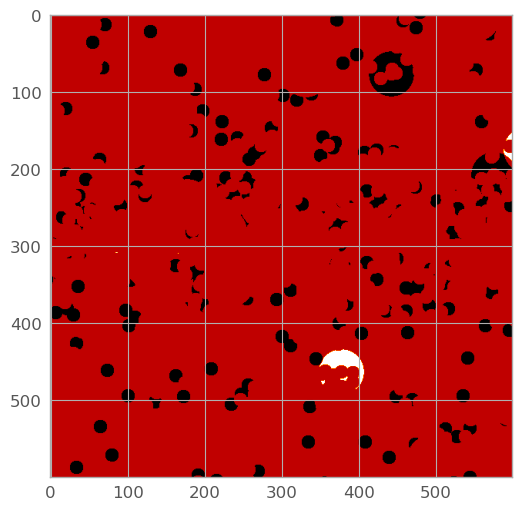

In [19]:
plt.imshow(np.load('./GC_analysis/Model/GC_mask_60x60_definitions_DR4.npy')[1] - np.load('./GC_analysis/Model/GC_mask_60x60_definitions_DR2.npy')[1])

In [20]:
model='I'
# Define your likelihood function
def log_likelihood(params, energy_bin):
    # Assuming your Likelihood class and method are correctly set up
    return -(1/2)*Likelihood(model, energy_bin).likelihood_constrained(params)  # log likelihood -> Need to maximize

# Define the prior function with parameter limits
def log_prior(params):
    limits = [
        (0, np.inf), (0, np.inf), (-np.inf, np.inf), (0, np.inf), (0, np.inf)
        #(0, 2), (0, 2), (-5, 5), (0.09, 0.11), (0, 5)
        #(-3, 3),  # Bounds for param1
        #(-3, 3),  # Bounds for param2
        #(-5, 5),  # Bounds for param3
        #(-3, 3),  # Bounds for param4
        #(-3, 3)   # Bounds for param5
    ]
    
    for i, (lower, upper) in enumerate(limits):
        if not (lower <= params[i] <= upper):
            return -np.inf  # Return negative infinity if outside bounds
    return 0.0  # Return zero if all parameters are within bounds

# Define the log probability function
def log_probability(params, energy_bin):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, energy_bin)  # Maximize this
    #return log_likelihood(params, energy_bin)

def run_mcmc_for_bin(energy_bin):  
    ndim = 5
    nwalkers = 100
    nsteps = 1000
    burn_in_steps = 400
    start_time=time.time()
    print(energy_bin)
    with Pool() as pool:
        #np.random.seed(100100)#
        #initial_params = np.random.uniform(0, 1, [nwalkers, ndim])
        #initial_params = np.vstack([np.random.uniform(0, 1, [nwalkers]), np.random.uniform(0, 1, [nwalkers]), np.random.uniform(9, 11, [nwalkers]), np.random.uniform(0, 1, [nwalkers]), np.random.uniform(2, 3, [nwalkers])]).T
        initial_params = np.vstack([np.random.uniform(0, 3, [nwalkers]), np.random.uniform(0, 3, [nwalkers]), np.random.uniform(0, 3, [nwalkers]), np.random.uniform(0, 10, [nwalkers]), np.random.uniform(0, 10, [nwalkers])]).T
        #initial_params = np.abs(np.ones(5) + np.random.randn(nwalkers, ndim))
        #initial_params = np.vstack([np.random.uniform(-5, 5, [nwalkers]), np.random.uniform(-5, 5, [nwalkers]), np.random.uniform(-5, 5, [nwalkers]), np.random.uniform(-5, 5, [nwalkers]), np.random.uniform(-5, 5, [nwalkers])]).T
        #initial_params = np.abs(np.ones(5) + 0.1*np.random.randn(nwalkers, ndim))
        pos = initial_params

        from emcee.moves import DEMove, KDEMove
        
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(energy_bin,), pool=pool)#, moves=[(DEMove(), 0.7), (KDEMove(), 0.3)])
        #for iteration in range(10):    
        print("Running production...")
        pos, prob, state = sampler.run_mcmc(pos, nsteps, progress=True)
        #sampler.run_mcmc(pos, nsteps, progress=True)
        
        max_pos = pos[np.argmax(prob)]
        fitted_param = max_pos
        #max_lhd_pos = np.argmax(prob)

  
        
        log_prob_samples = sampler.get_log_prob(discard=burn_in_steps, flat=True)

        max_prob_index = np.argmax(log_prob_samples)

        max_lhd = log_prob_samples[max_prob_index]

        best_fit_params = sampler.get_chain(discard=burn_in_steps, flat=True)[max_prob_index]        

        fitted_param = best_fit_params
        
        flat_samples = sampler.get_chain(discard=burn_in_steps, flat=True)

        lower_1sigma = np.percentile(flat_samples, 16, axis=0)
        upper_1sigma = np.percentile(flat_samples, 84, axis=0)

        #for i in range(ndim):
        # Calculate the 16th, 50th, and 84th percentiles for the i-th parameter
            #mcmc = np.percentile(flat_samples[:, i], [50])
            #fitted_param[i] = mcmc[0]
            #print(mcmc[0])

        print(max_pos)#, best_fit_params, fitted_param)

        

        #fitted_param = best_fit_params
        
        # Get only the samples from the current iteration
        samples = sampler.get_chain(discard=burn_in_steps, thin=1, flat=False)
        current_samples = samples[-nsteps:]  # Get only the last `nsteps` samples
    
        print("Max position:", fitted_param)
        # Trace Plot for Each Walker and Parameter
        fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
        for i in range(ndim):
            ax = axes[i]
            for walker in range(nwalkers):
                ax.plot(current_samples[:, walker, i], alpha=0.3)  # Plot each walker separately
            ax.set_xlim(0, nsteps)
            ax.set_ylim(-3, 20)
            ax.set_ylabel(f"param{i+1}")
            ax.yaxis.set_label_coords(-0.1, 0.5)
    
        axes[-1].set_xlabel("step number")
        plt.suptitle(f"Trace Plot for Each Walker after iteration")
        plt.show()
    
        # Final Corner Plot with ChainConsumer
        flat_samples = sampler.get_chain(discard=burn_in_steps, thin=1, flat=True)  # Flatten for ChainConsumer
        c = ChainConsumer()
        c.add_chain(flat_samples, parameters=["param1", "param2", "param3", "param4", "param5"])
        fig = c.plotter.plot(figsize=(6, 6))
        axes=fig.axes
        #for ax in axes:
        #    ax.set_xlim(-1, 6)
        #    ax.set_ylim(-1, 6)
        plt.show()
        print("std", np.std(flat_samples, axis=0, ddof=1))
    end_time=time.time()
    #print(f"{np.round((end_time-start_time)/(60*60), 5)}hours")
    print(fitted_param, np.median(flat_samples, axis=0))
    return fitted_param.T, np.median(flat_samples, axis=0).T, np.std(flat_samples, axis=0, ddof=1).T, max_lhd, upper_1sigma, lower_1sigma
    #return np.median(samples, axis=0), np.std(samples, axis=0)

0
Running production...


100%|███████████████████████████████████████| 1000/1000 [38:03<00:00,  2.28s/it]


[0.86070726 0.86346191 7.41036248 0.47981271 2.21809337]
Max position: [0.86327925 0.86422088 7.00141647 0.48729509 2.21720263]


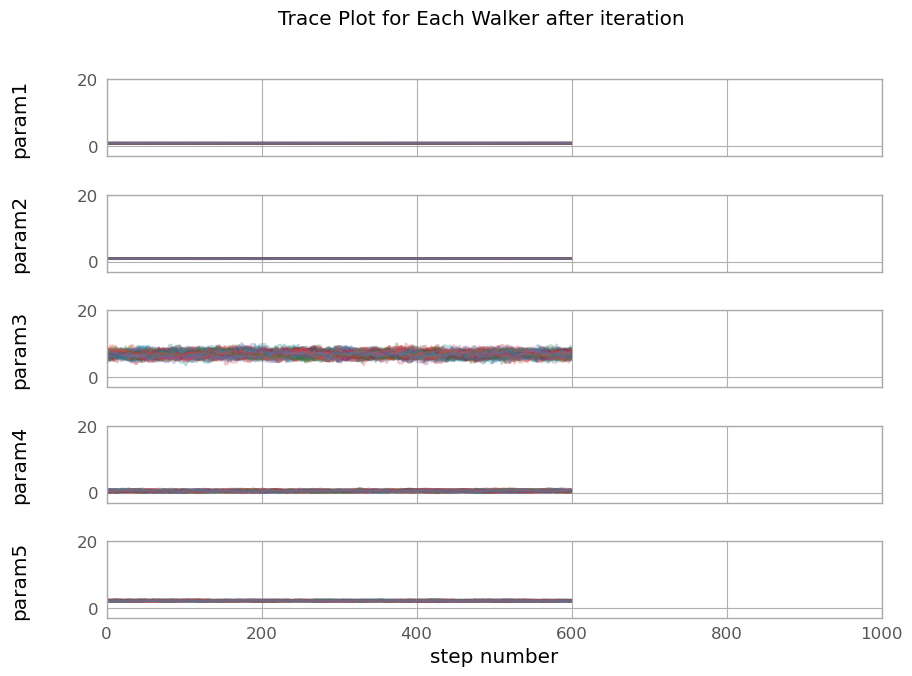

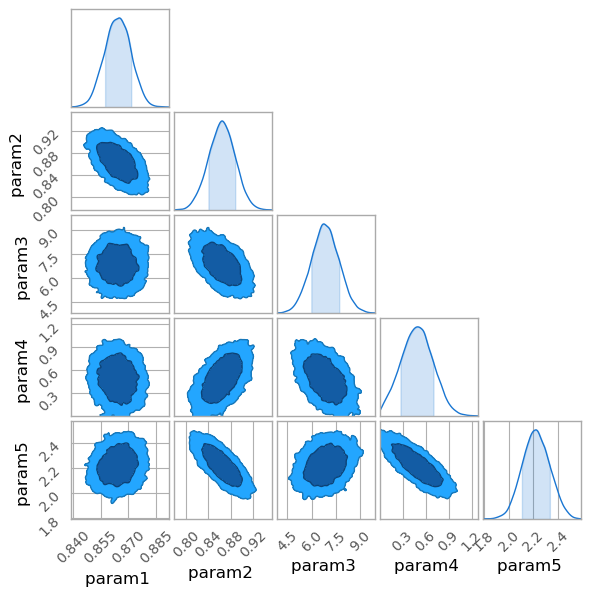

std [0.00701941 0.02394099 0.85392033 0.20585479 0.10987406]
[0.86327925 0.86422088 7.00141647 0.48729509 2.21720263] [0.86429841 0.86437758 6.84017866 0.49062147 2.22069991]


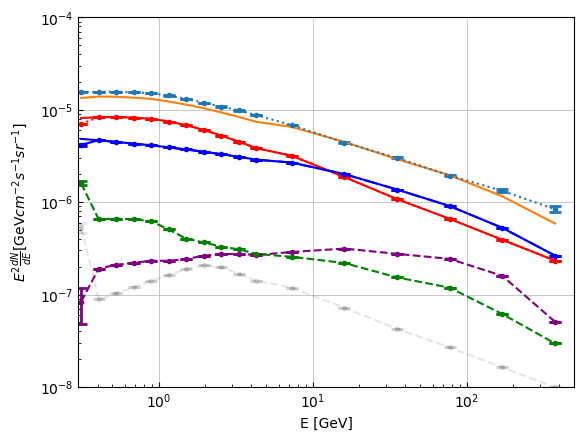

5.345790761059276e-07
5.354299060199439e-08
7.670235358462908e-08
1
Running production...


100%|███████████████████████████████████████| 1000/1000 [42:34<00:00,  2.55s/it]


[0.91713659 0.86728835 6.60892006 0.46719982 2.37916097]
Max position: [0.91896693 0.87138802 6.37518191 0.57774943 2.32225585]


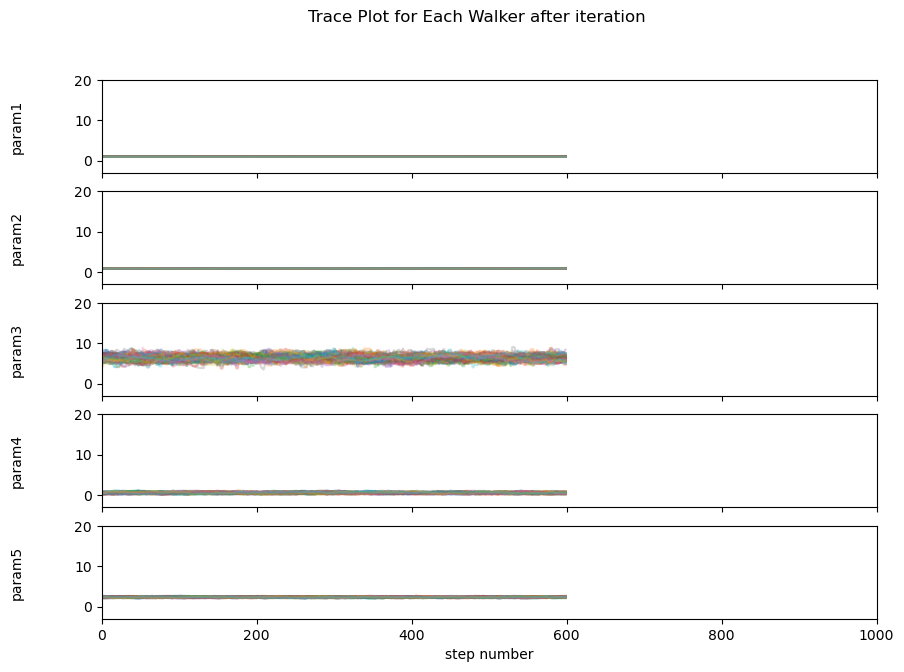

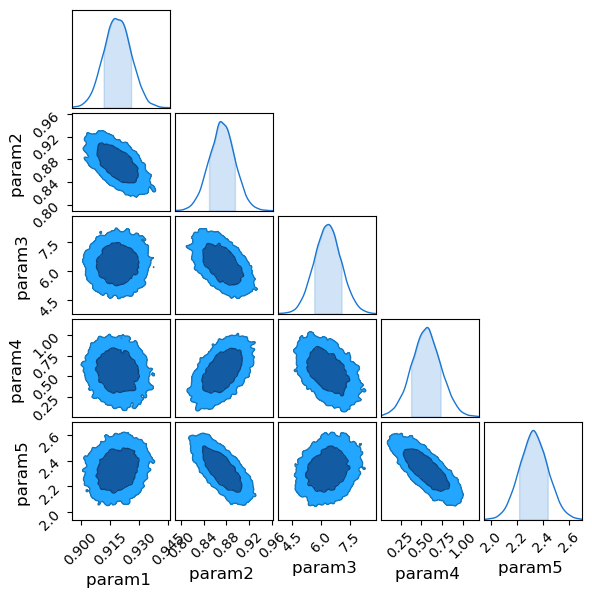

std [0.00694099 0.02275048 0.69649093 0.17729836 0.11023719]
[0.91896693 0.87138802 6.37518191 0.57774943 2.32225585] [0.91880597 0.87223098 6.35423914 0.55931006 2.32828856]


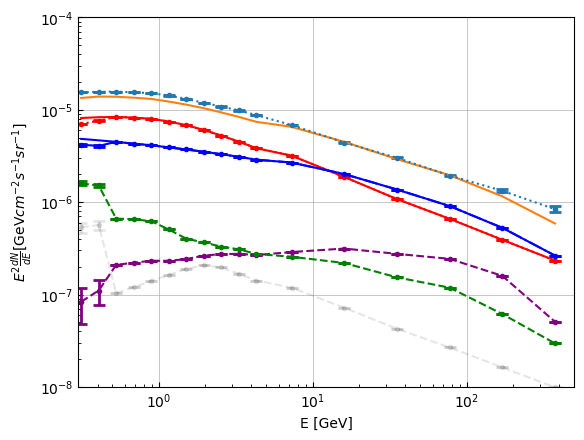

5.657273963205199e-07
5.982527317687326e-08
6.279282694751995e-08
2
Running production...


100%|███████████████████████████████████████| 1000/1000 [42:46<00:00,  2.57s/it]


[0.93178983 0.94083929 6.91787678 0.32082106 1.96674591]
Max position: [0.93045565 0.94544078 6.59159389 0.35646483 1.96874756]


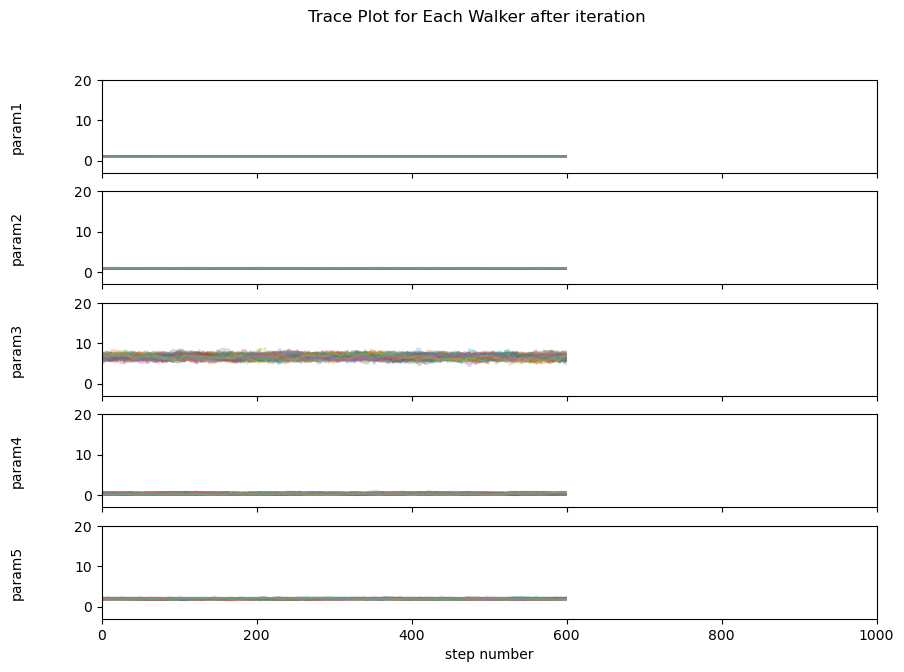

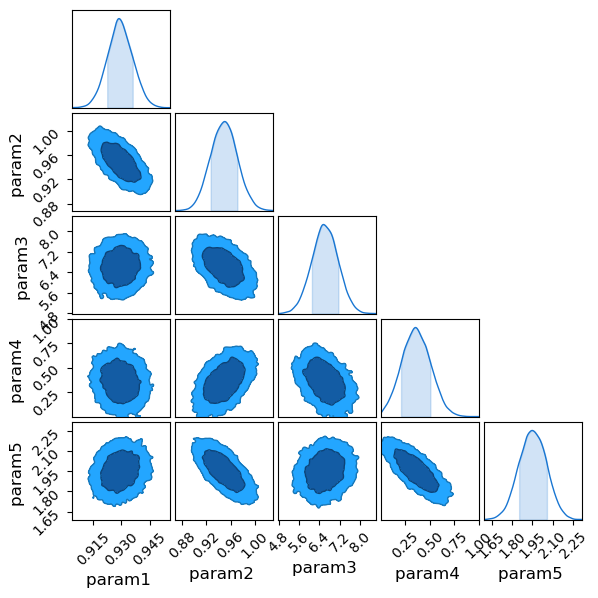

std [0.00664813 0.02179543 0.51059134 0.14573128 0.10101779]
[0.93045565 0.94544078 6.59159389 0.35646483 1.96874756] [0.92929862 0.94908638 6.61847459 0.35902405 1.95344946]


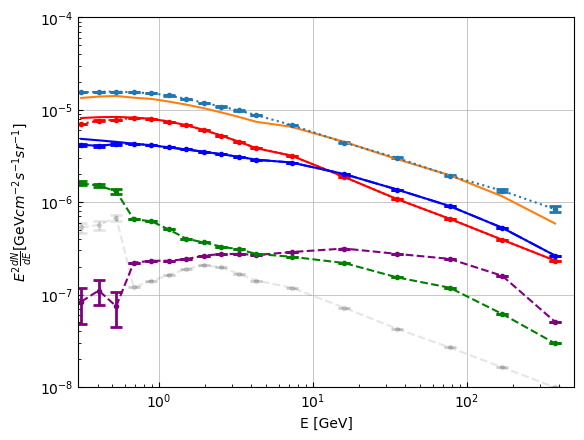

6.812631207118777e-07
5.544337588729011e-08
4.9672946406384227e-08
3
Running production...


100%|███████████████████████████████████████| 1000/1000 [48:26<00:00,  2.91s/it]


[0.95704731 0.91109722 6.45100415 0.39991745 1.90906692]
Max position: [0.95731647 0.91484869 6.1860062  0.49578942 1.87621418]


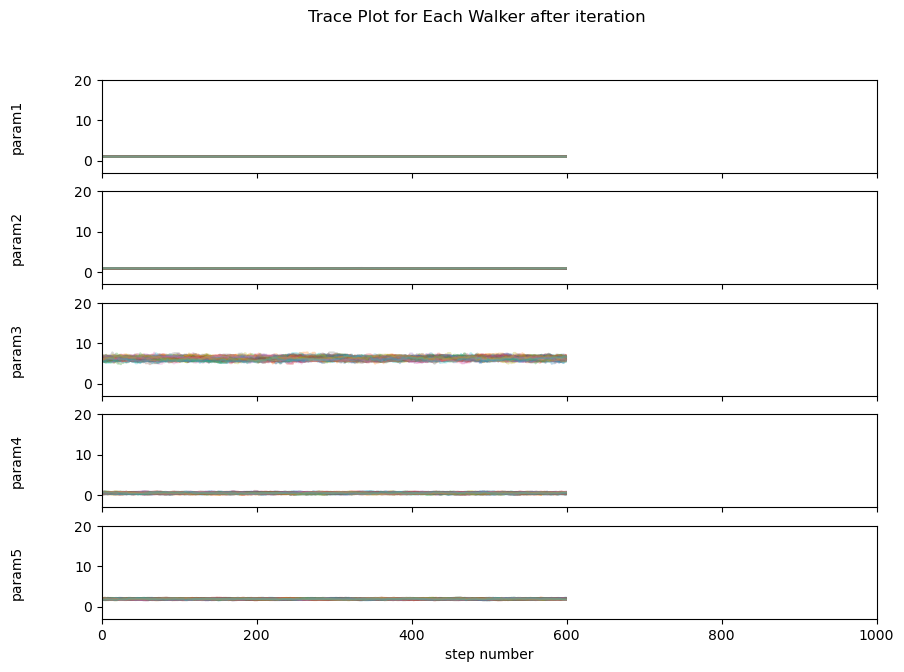

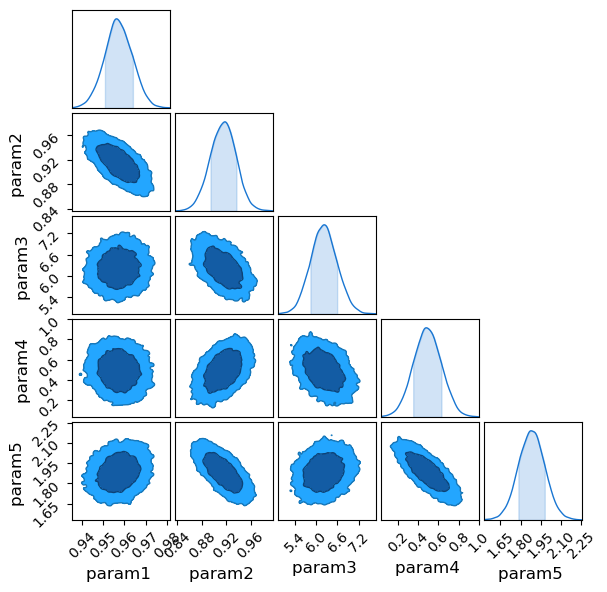

std [0.00657709 0.02110074 0.3765671  0.13765082 0.09758784]
[0.95731647 0.91484869 6.1860062  0.49578942 1.87621418] [0.95706859 0.91522252 6.21258249 0.49051615 1.88235741]


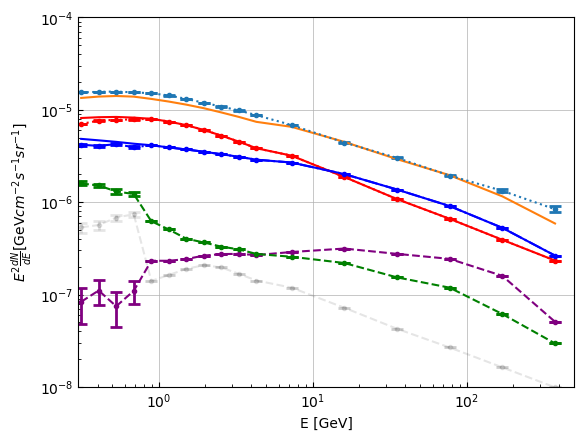

7.406858026700022e-07
4.837584825493422e-08
4.07025524220029e-08
4
Running production...


100%|███████████████████████████████████████| 1000/1000 [45:07<00:00,  2.71s/it]


[0.9696474  0.99089658 4.67458775 0.74625783 1.62572777]
Max position: [0.9678693  0.97942863 4.85235632 0.64242852 1.71937298]


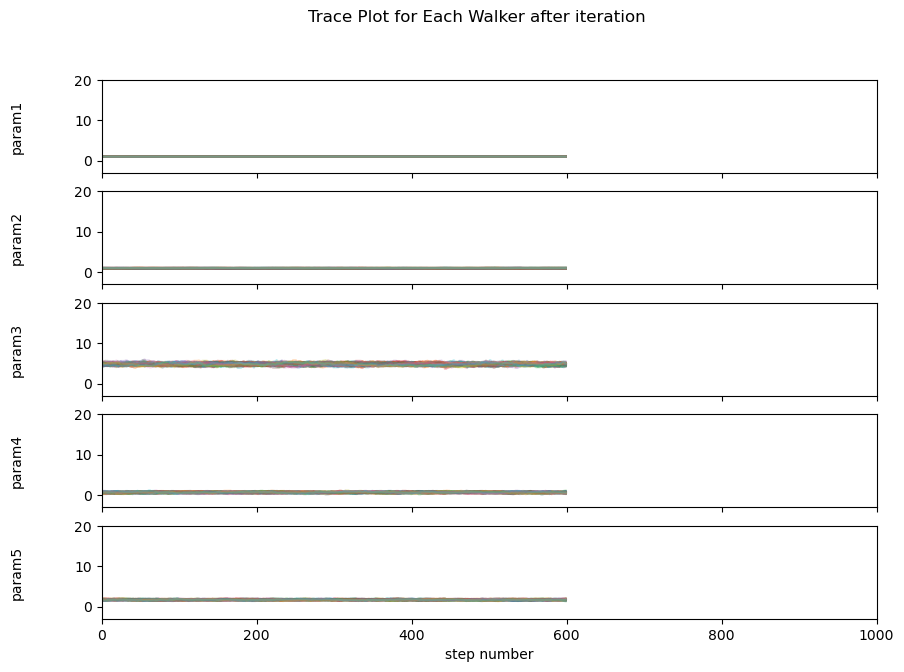

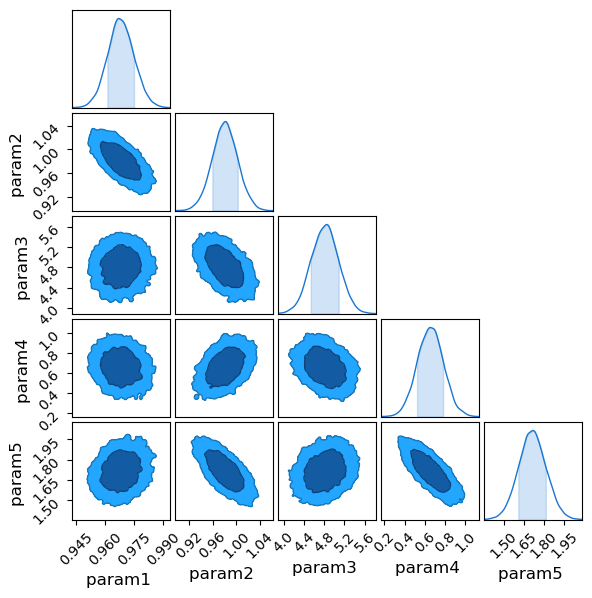

std [0.00681097 0.02150926 0.27116093 0.12915985 0.1017364 ]
[0.9678693  0.97942863 4.85235632 0.64242852 1.71937298] [0.96790274 0.98077078 4.81640337 0.65718705 1.71317604]


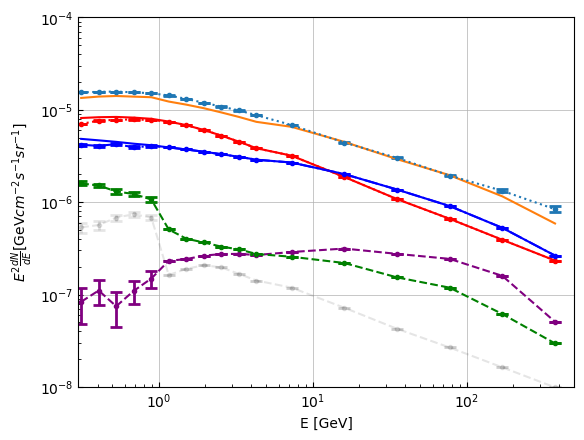

6.823779016185795e-07
3.239632662934257e-08
4.381996177484729e-08
5
Running production...


100%|███████████████████████████████████████| 1000/1000 [43:23<00:00,  2.60s/it]


[0.9760618  0.95201828 5.42500642 0.58973844 1.83102257]
Max position: [0.97633851 0.9538919  5.35913306 0.61336559 1.81424368]


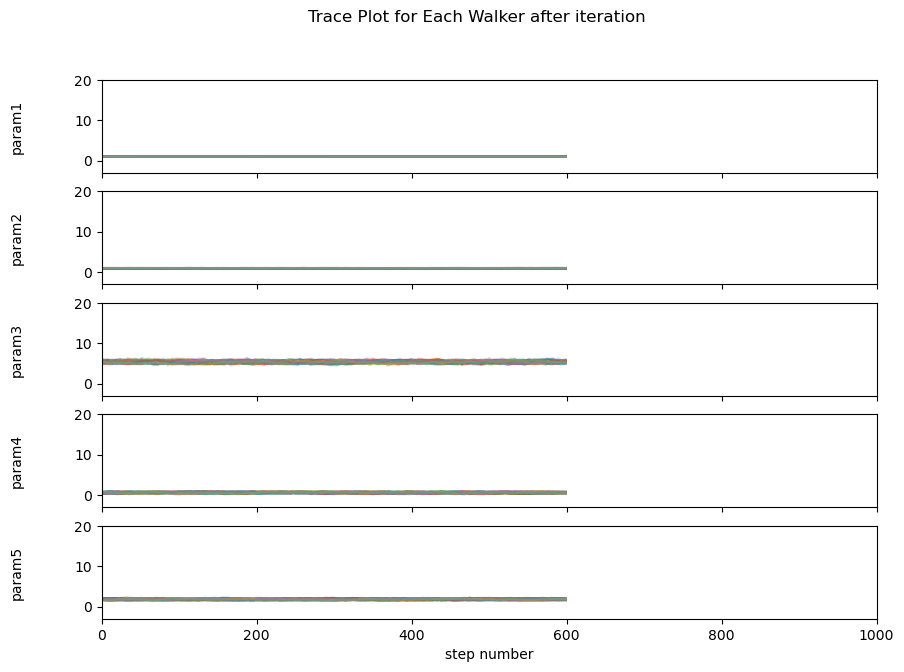

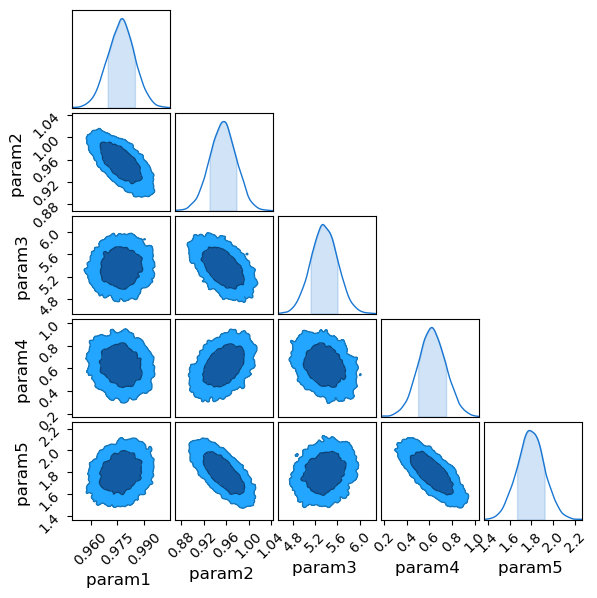

std [0.00762898 0.02377457 0.24177568 0.12304544 0.12528685]
[0.97633851 0.9538919  5.35913306 0.61336559 1.81424368] [0.97720801 0.95450879 5.36197876 0.62151565 1.79477735]


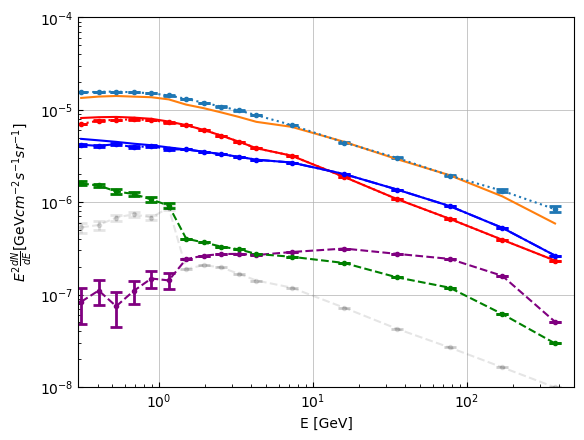

8.720624685896191e-07
3.99231017309015e-08
3.804003986160031e-08
6
Running production...


100%|███████████████████████████████████████| 1000/1000 [42:26<00:00,  2.55s/it]


[0.96566938 1.03065612 4.1597214  1.3965436  1.02381572]
Max position: [0.96619385 1.02991464 4.23032687 1.44741536 0.97929701]


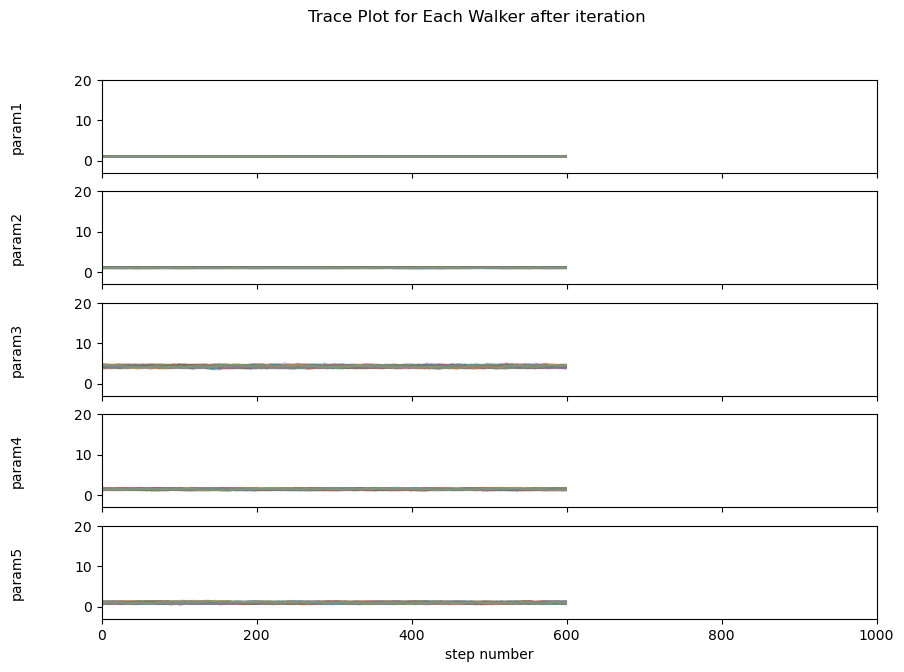

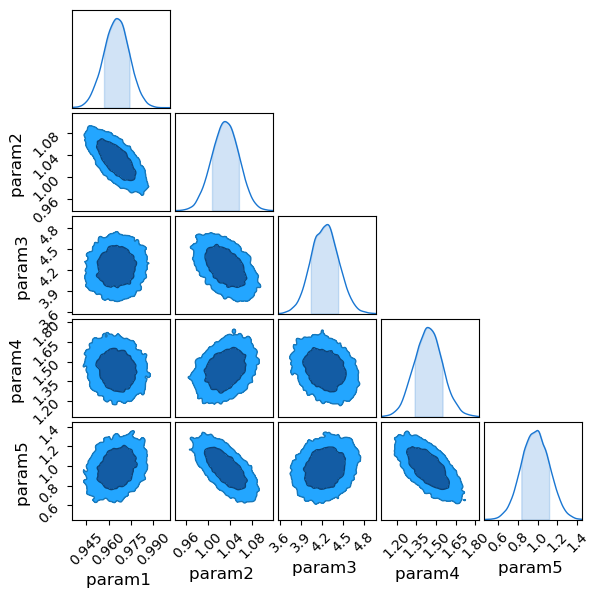

std [0.00850732 0.02425064 0.19561288 0.10622869 0.14025463]
[0.96619385 1.02991464 4.23032687 1.44741536 0.97929701] [0.96533655 1.03104035 4.24700011 1.44115491 0.97714725]


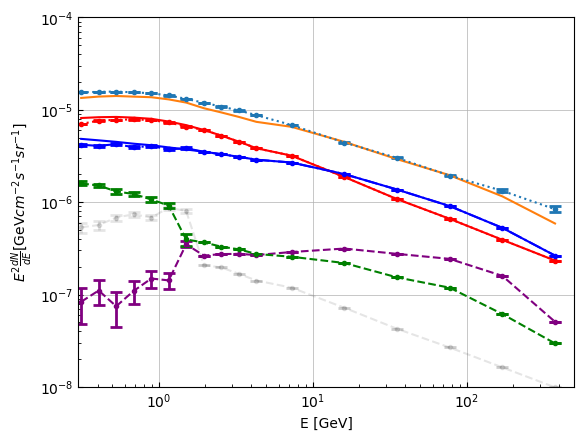

8.015821997874088e-07
3.982912480537416e-08
3.348358877075819e-08
7
Running production...


100%|███████████████████████████████████████| 1000/1000 [35:09<00:00,  2.11s/it]


[0.96170417 1.02582057 3.85354899 1.24270697 0.97290992]
Max position: [0.9621072  1.02329873 3.8309217  1.2157881  1.02302218]


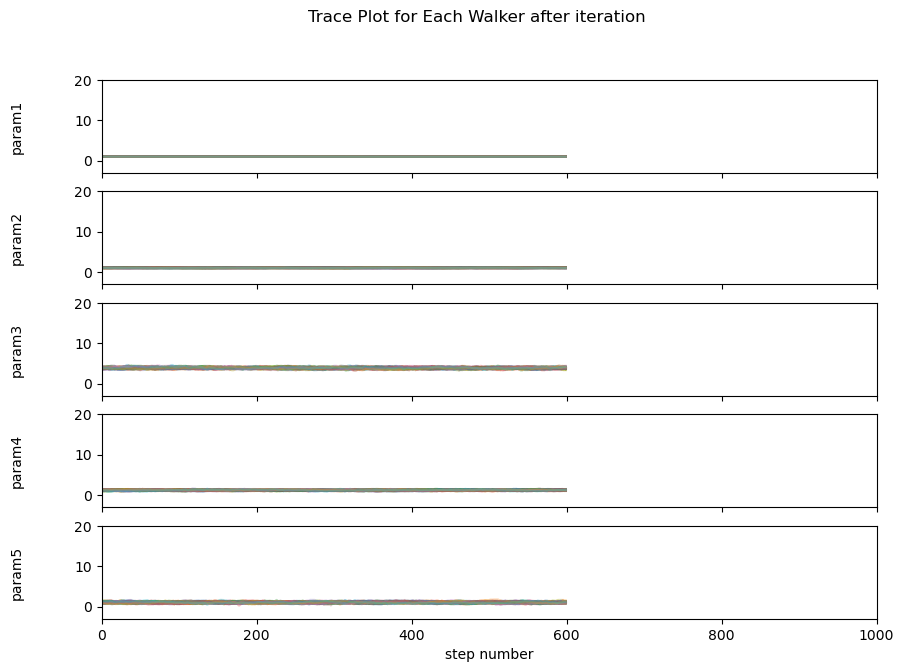

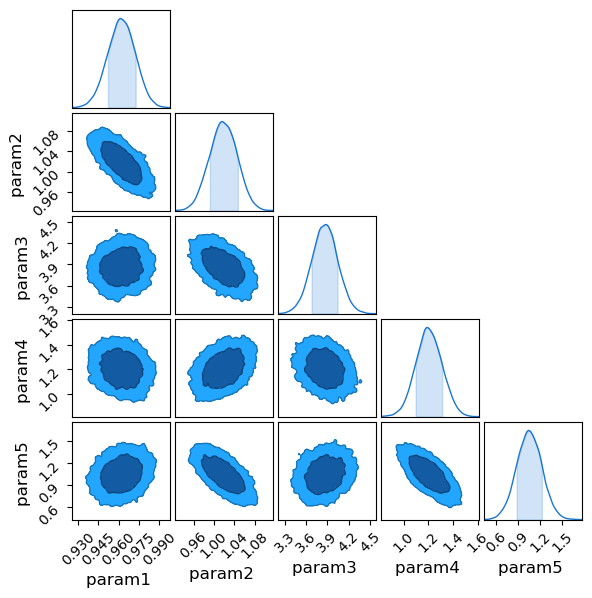

std [0.01016308 0.02698362 0.18167152 0.10585613 0.17004438]
[0.9621072  1.02329873 3.8309217  1.2157881  1.02302218] [0.96208755 1.0182915  3.86513705 1.20342155 1.0484572 ]


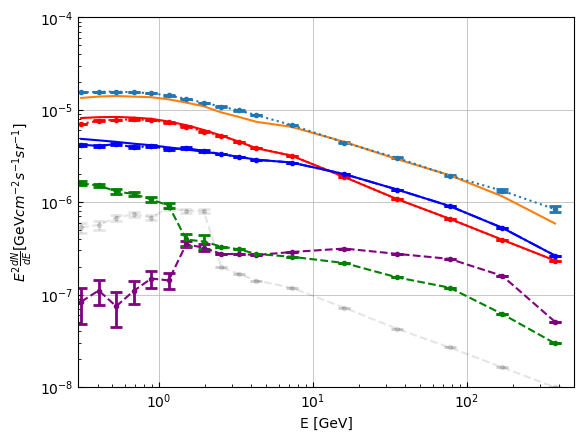

7.975419200839418e-07
4.4062149020329485e-08
3.0488752461277324e-08
8
Running production...


100%|███████████████████████████████████████| 1000/1000 [31:47<00:00,  1.91s/it]


[0.98983587 1.03365994 3.50286568 1.36608736 0.77788707]
Max position: [0.98630658 1.04983617 3.42664093 1.38512386 0.7055064 ]


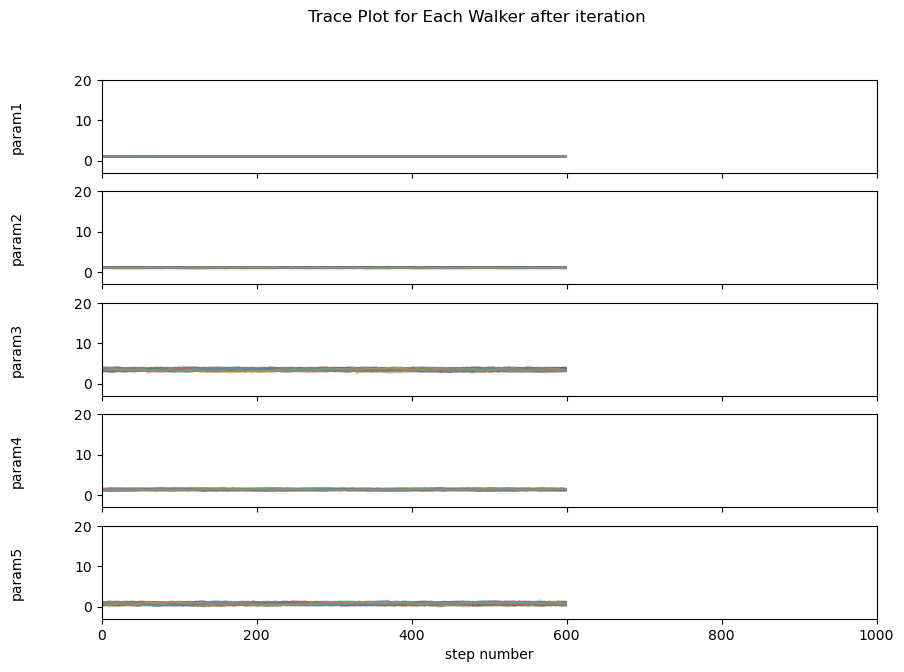

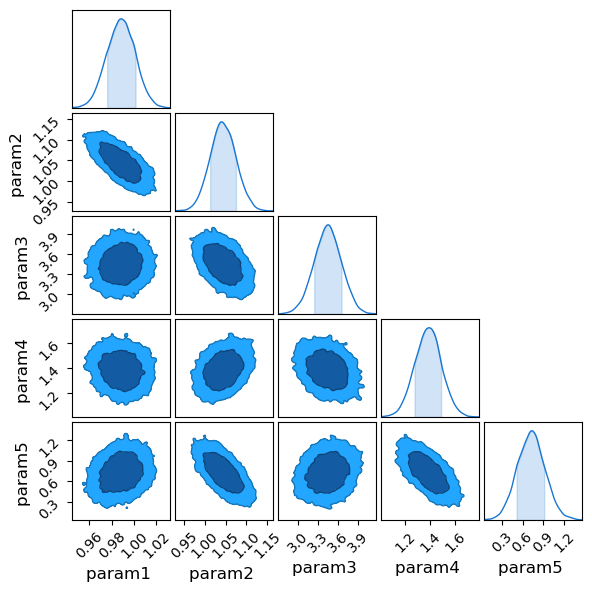

std [0.01261846 0.03109656 0.20383935 0.10495213 0.19906638]
[0.98630658 1.04983617 3.42664093 1.38512386 0.7055064 ] [0.98835894 1.04324254 3.44837846 1.38488129 0.72425357]


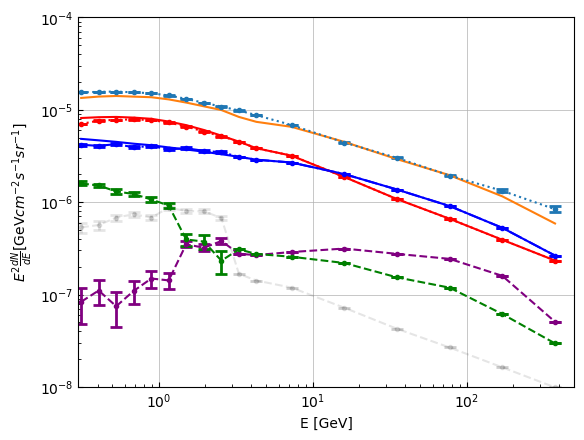

6.738131024705578e-07
4.4032363198761145e-08
3.563927989058667e-08
9
Running production...


100%|███████████████████████████████████████| 1000/1000 [28:09<00:00,  1.69s/it]


[1.00138323 0.98160941 4.28739034 1.34061166 1.14335355]
Max position: [0.99643329 0.98813191 4.2924784  1.34150219 1.12062369]


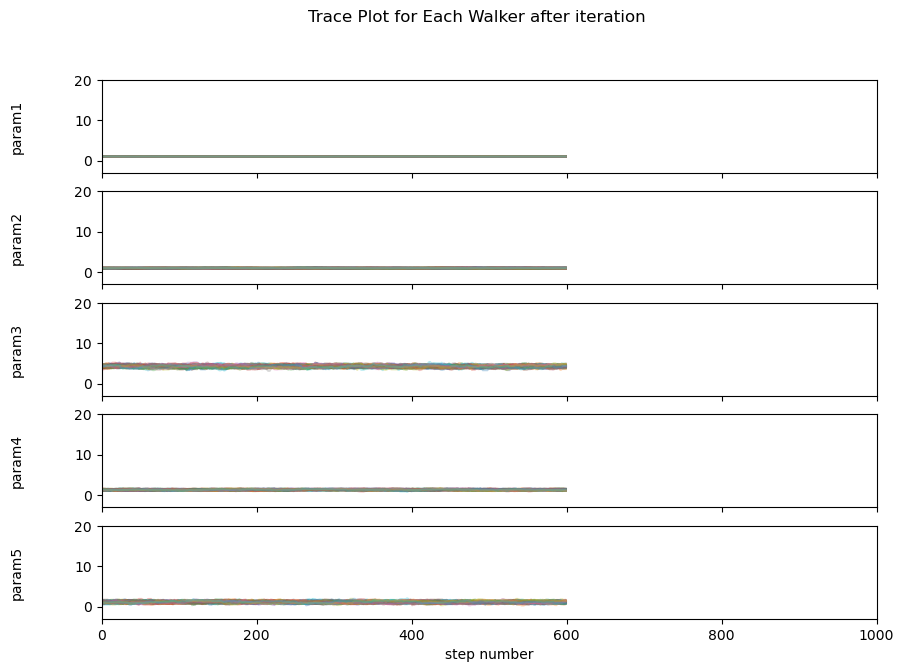

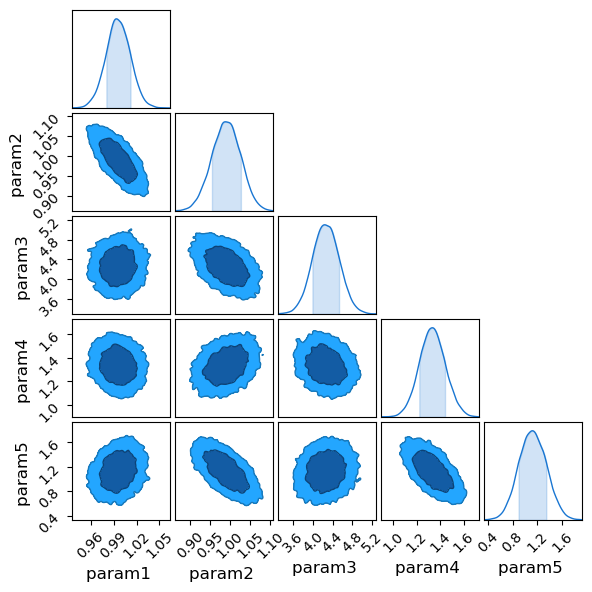

std [0.01579467 0.0355339  0.26849508 0.10999098 0.22011948]
[0.99643329 0.98813191 4.2924784  1.34150219 1.12062369] [0.99576645 0.99072091 4.26279227 1.33434127 1.12268249]


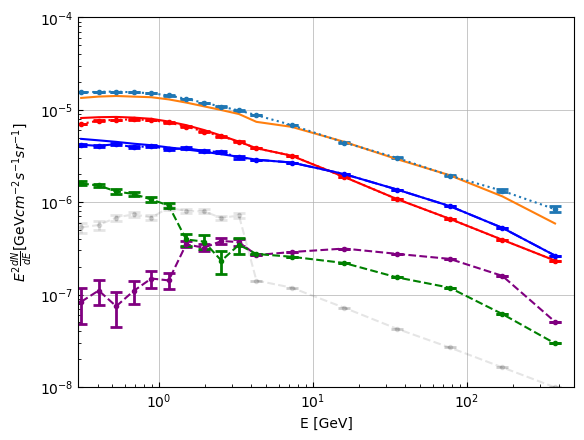

7.186954858100861e-07
4.0113173951018784e-08
4.894168040276868e-08
10
Running production...


100%|███████████████████████████████████████| 1000/1000 [27:31<00:00,  1.65s/it]


[0.99940388 1.03359108 4.68053681 1.58052471 0.61766369]
Max position: [1.00738449 1.01711887 4.64483118 1.61057359 0.68060422]


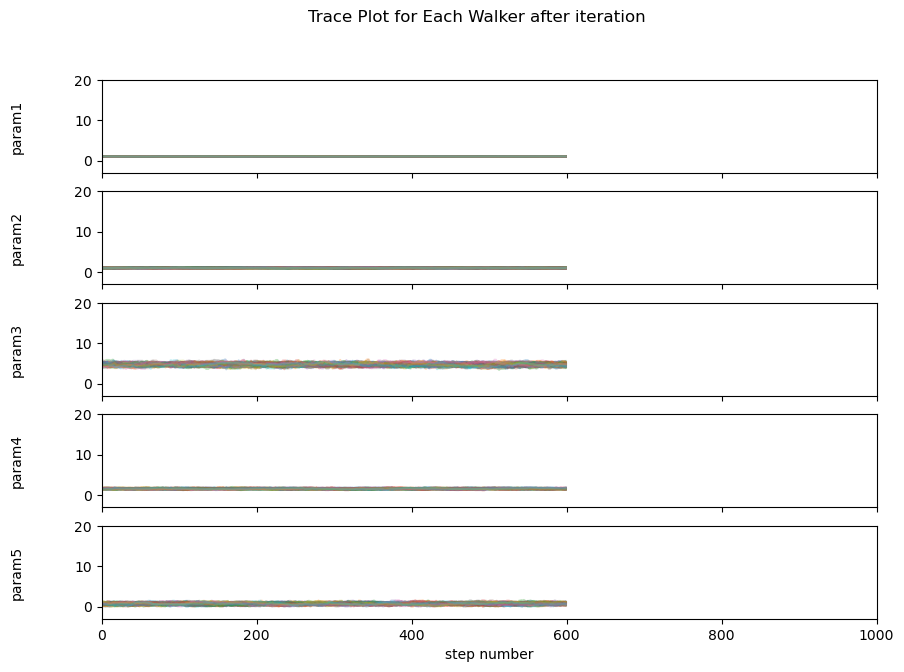

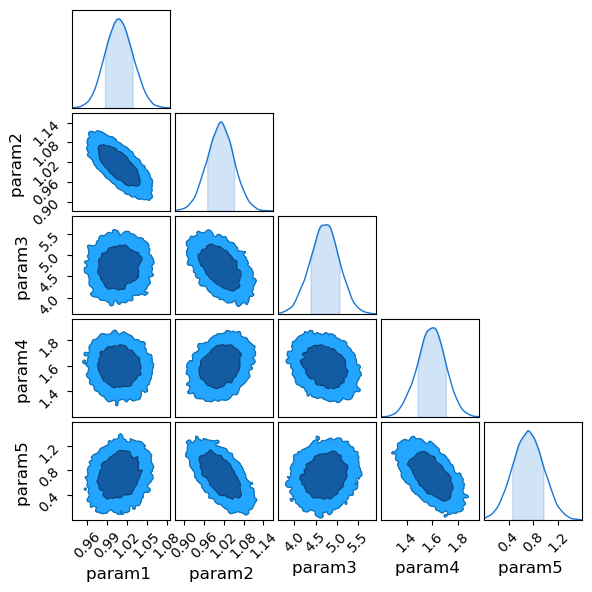

std [0.02043931 0.04090403 0.33854234 0.10893053 0.2460854 ]
[1.00738449 1.01711887 4.64483118 1.61057359 0.68060422] [1.0080844  1.01034188 4.714411   1.59369285 0.71375202]


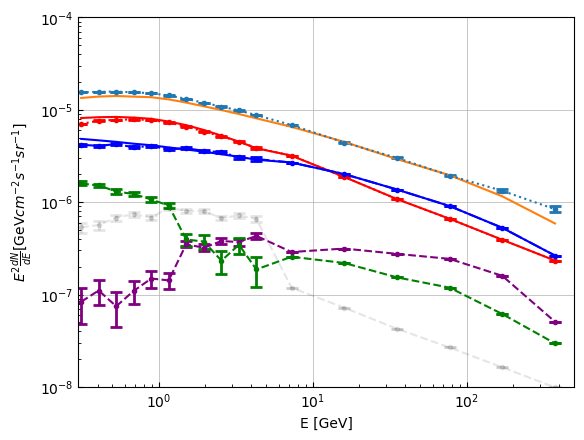

6.594822778353658e-07
5.6860686109129225e-08
3.8763713658307376e-08
11
Running production...


100%|███████████████████████████████████████| 1000/1000 [29:21<00:00,  1.76s/it]


[0.90230138 0.9318254  3.91419224 1.24609015 1.00785788]
Max position: [0.90553077 0.92714979 3.92469547 1.23154233 1.00038806]


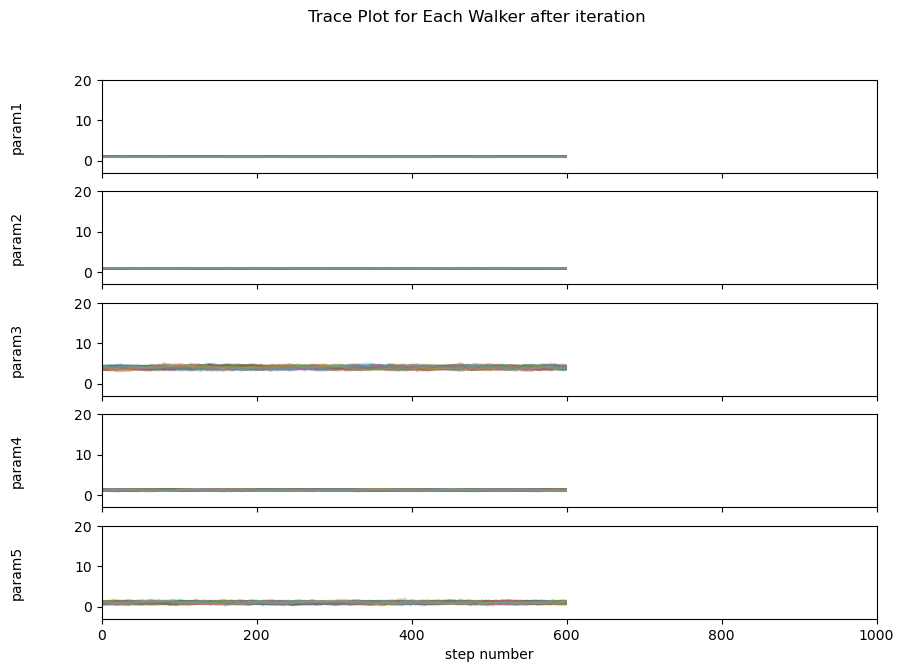

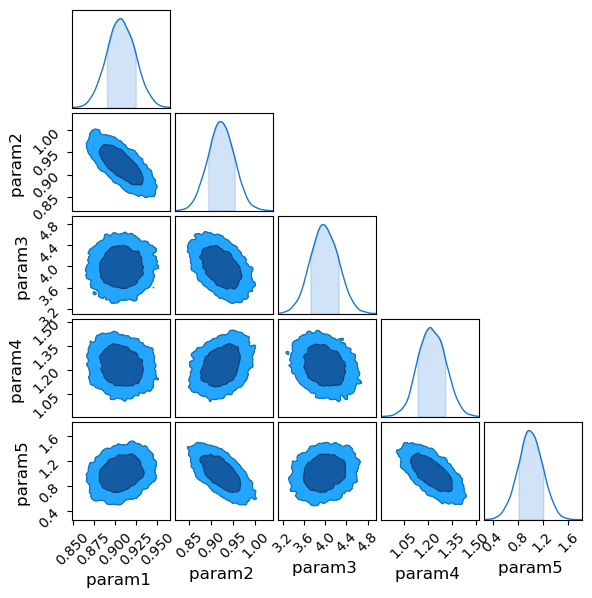

std [0.01670468 0.02956894 0.26370368 0.08483727 0.19537594]
[0.90553077 0.92714979 3.92469547 1.23154233 1.00038806] [0.90717745 0.92249868 3.98185807 1.22452586 0.99972081]


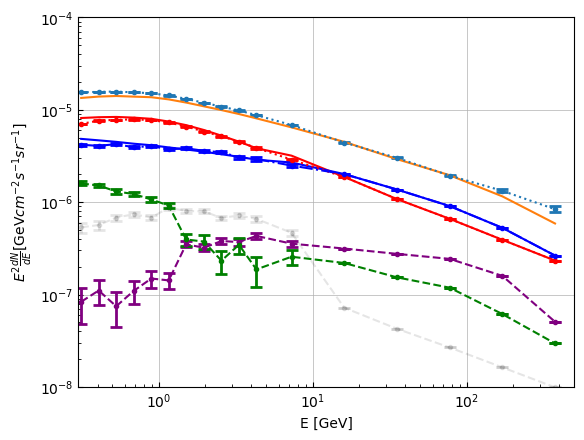

4.667216418540452e-07
3.869959924354601e-08
2.3950793601919242e-08
12
Running production...


100%|███████████████████████████████████████| 1000/1000 [22:49<00:00,  1.37s/it]


[0.90507096 0.86138605 3.88005016 1.14183545 0.85211259]
Max position: [0.9100636  0.85629507 4.19850925 1.13513739 0.78544344]


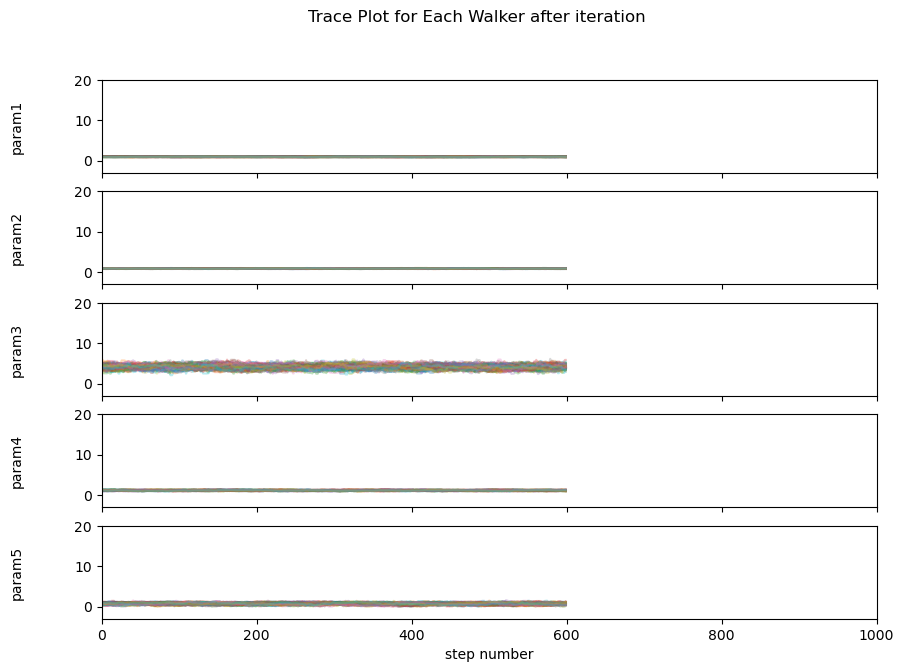

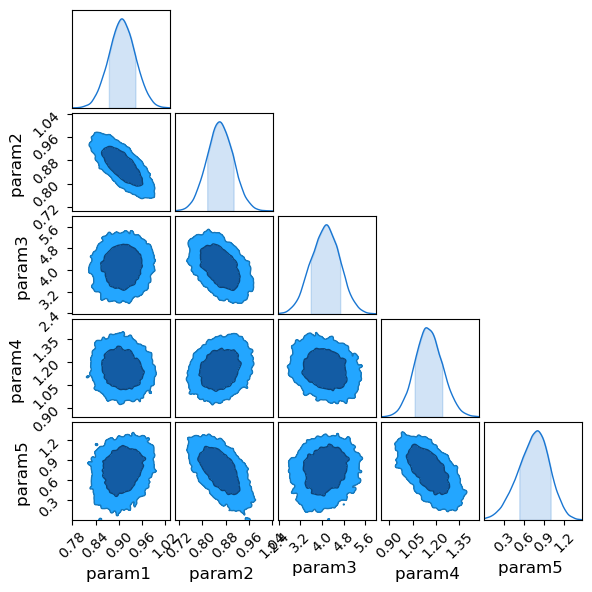

std [0.03401893 0.0452262  0.5305886  0.0887109  0.23369899]
[0.9100636  0.85629507 4.19850925 1.13513739 0.78544344] [0.90809804 0.86051937 4.13597475 1.15199814 0.75635872]


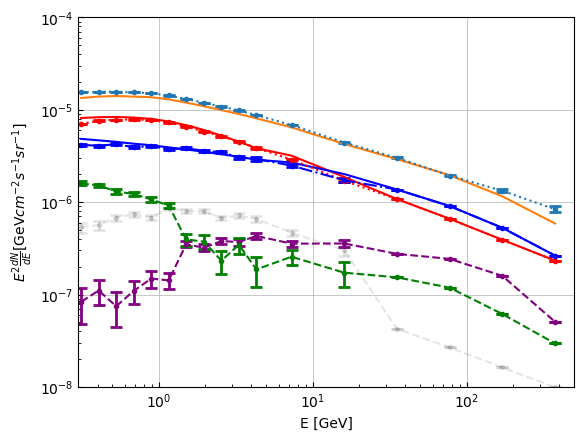

3.025250089978556e-07
3.305462382110943e-08
4.4405446578602895e-08
13
Running production...


100%|███████████████████████████████████████| 1000/1000 [18:45<00:00,  1.13s/it]


[0.82455382 1.03087416 5.18564645 1.0303796  0.91972598]
Max position: [0.8724781  0.99493037 4.9183423  1.01644068 0.9688313 ]


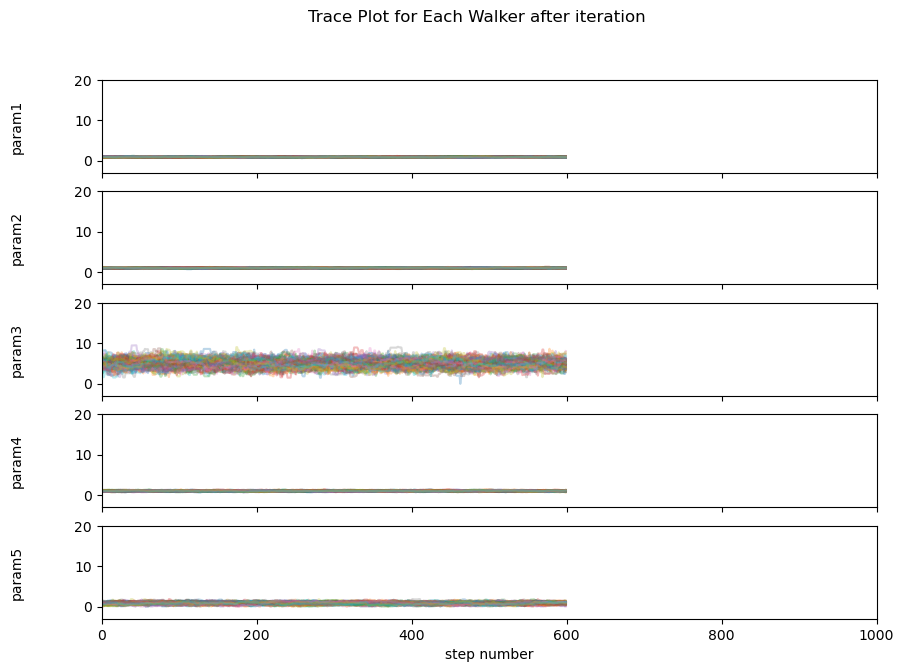

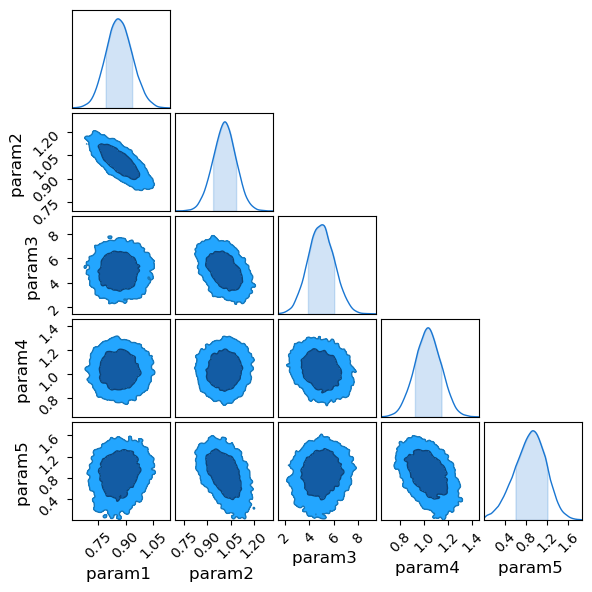

std [0.07110572 0.07424127 1.05939514 0.10911425 0.29665245]
[0.8724781  0.99493037 4.9183423  1.01644068 0.9688313 ] [0.86474715 1.01131669 4.95854281 1.03218562 0.8917053 ]


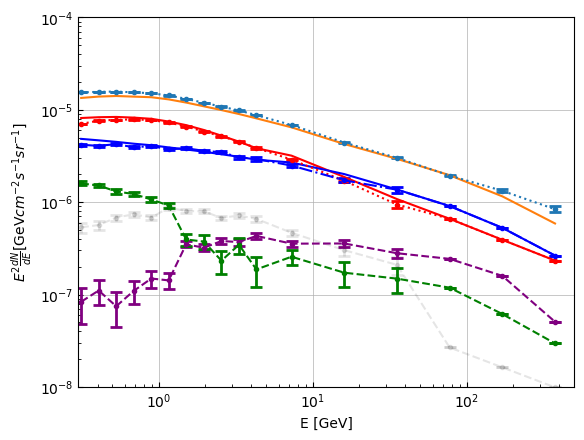

2.0985625802421268e-07
4.712645822145311e-08
4.291794903598008e-08
14
Running production...


100%|███████████████████████████████████████| 1000/1000 [21:42<00:00,  1.30s/it]


[1.15344719 0.87489611 4.53182768 0.71901308 0.66940155]
Max position: [1.21230143 0.85798196 4.0995438  0.7093092  0.62388445]


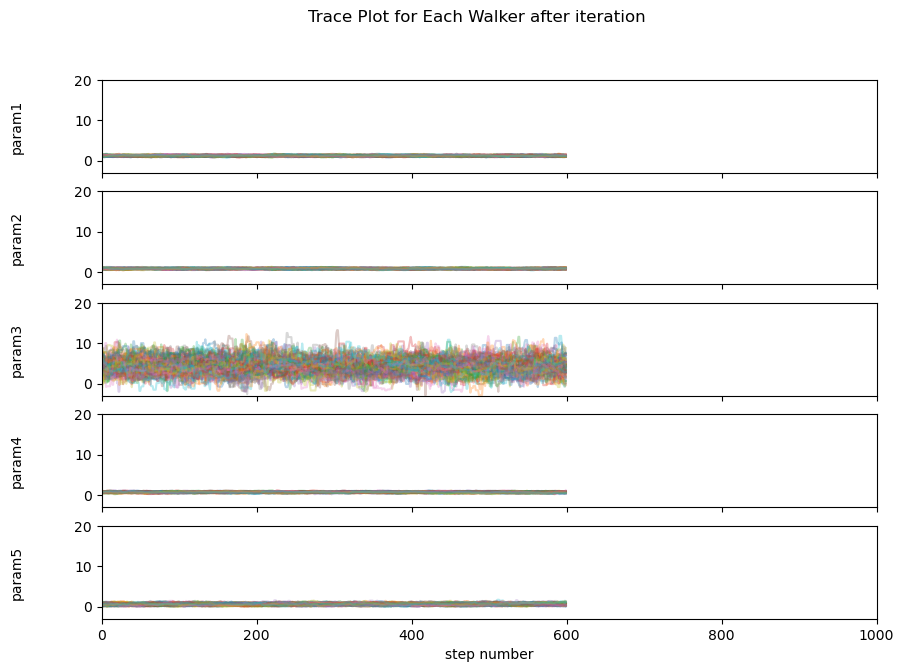

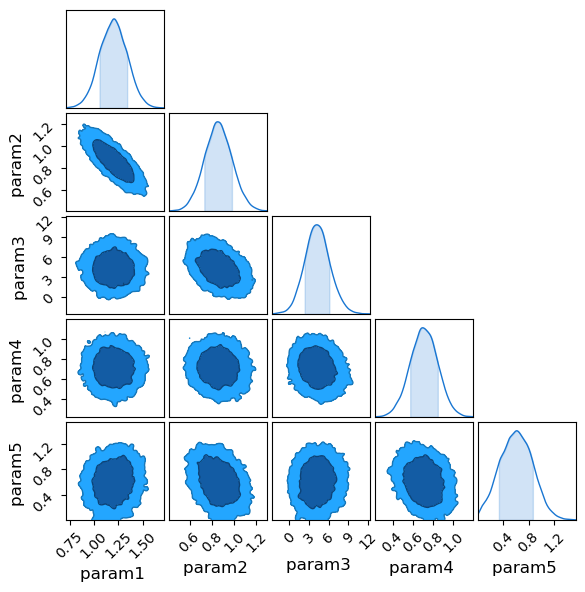

std [0.13999972 0.12374956 1.8984189  0.1358678  0.25343247]
[1.21230143 0.85798196 4.0995438  0.7093092  0.62388445] [1.20015709 0.85873282 4.27491647 0.71227814 0.60748361]


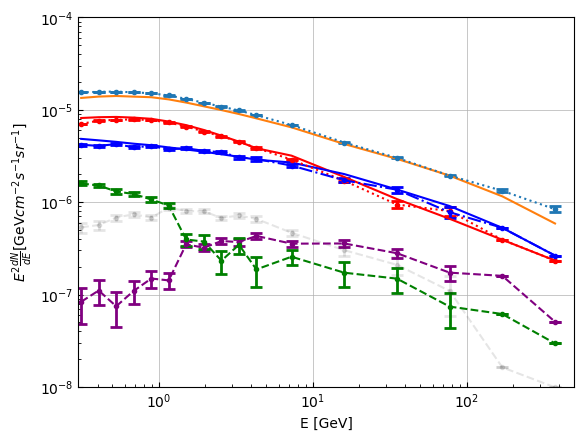

1.0966097226969002e-07
5.547252586983801e-08
4.364382687588889e-08
15
Running production...


100%|███████████████████████████████████████| 1000/1000 [19:44<00:00,  1.18s/it]


[0.98673256 1.4331003  0.98607241 0.65612979 0.68574633]
Max position: [1.14752939 1.3171238  1.17641303 0.69936799 0.6876989 ]


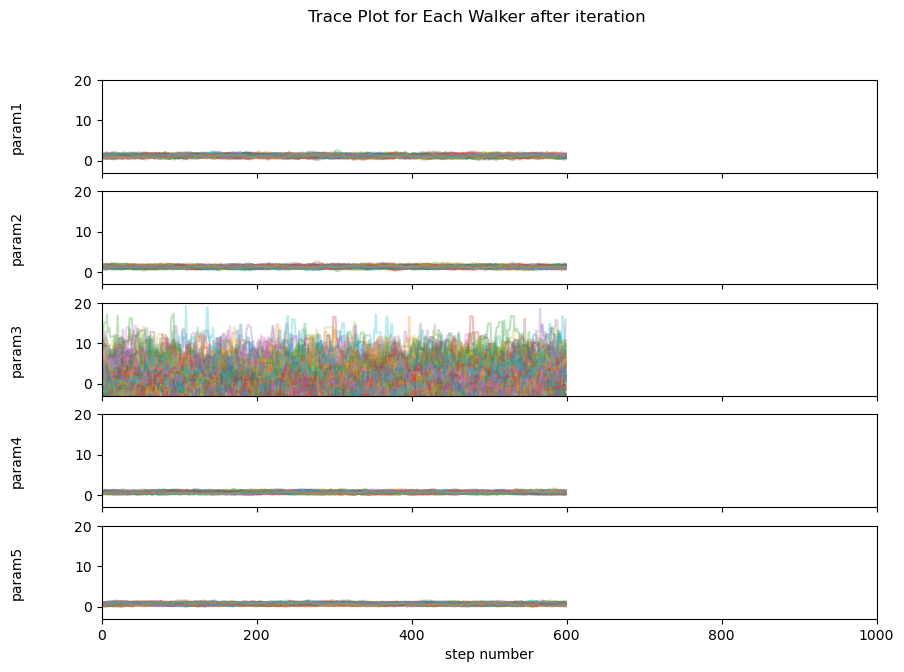

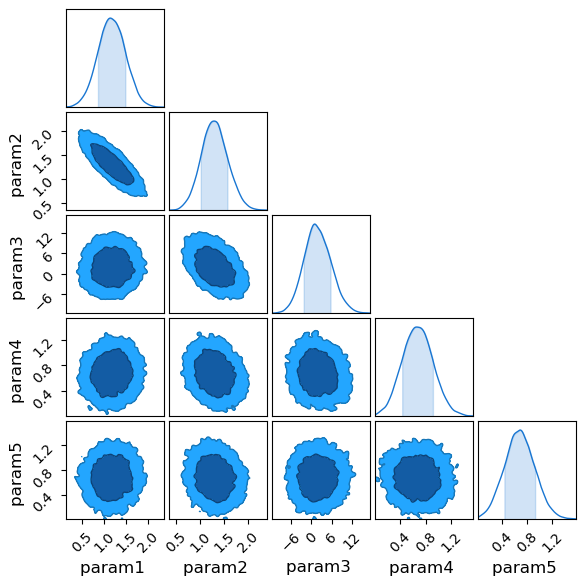

std [0.30637974 0.27564883 3.92822892 0.23690211 0.24466277]
[1.14752939 1.3171238  1.17641303 0.69936799 0.6876989 ] [1.17247198 1.29314836 1.75511103 0.67516575 0.67602503]


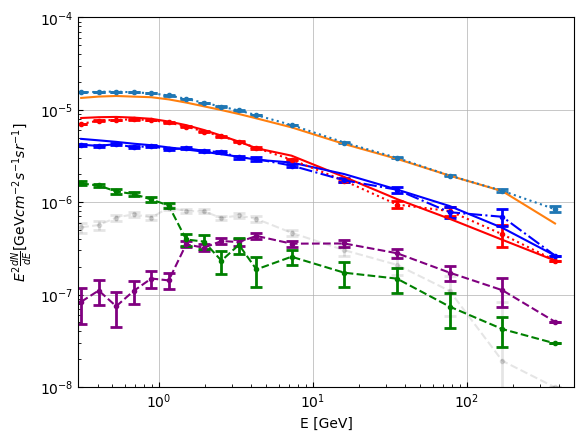

1.9180107780264475e-08
7.6366666216375e-08
5.0922096220476914e-08
16
Running production...


100%|███████████████████████████████████████| 1000/1000 [15:44<00:00,  1.06it/s]


[ 1.60032174  1.20836163 11.75117825  0.02154679  1.22244259]
Max position: [ 1.88785619  0.95540176 10.19070823  0.08282965  1.0633126 ]


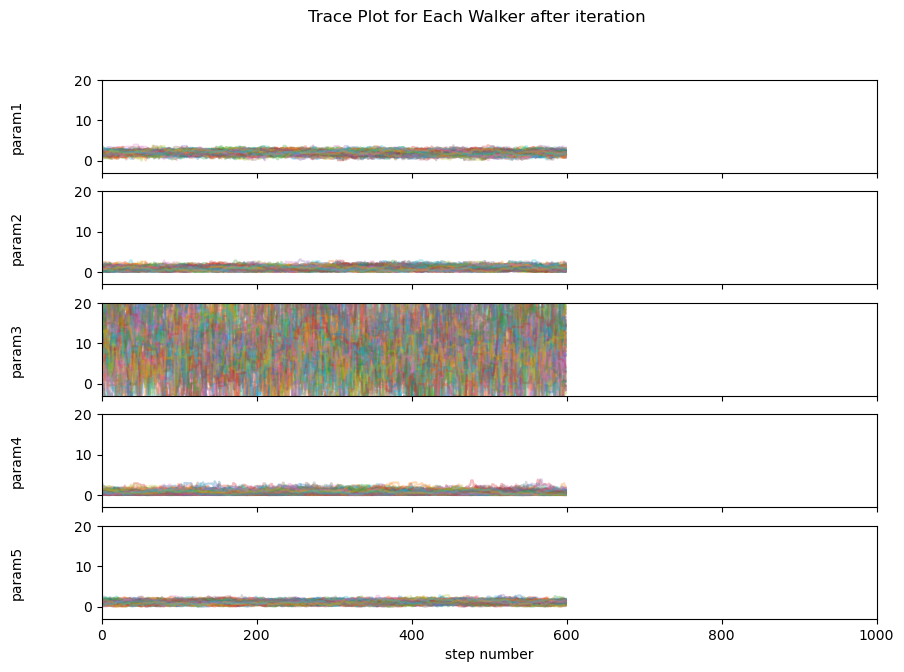

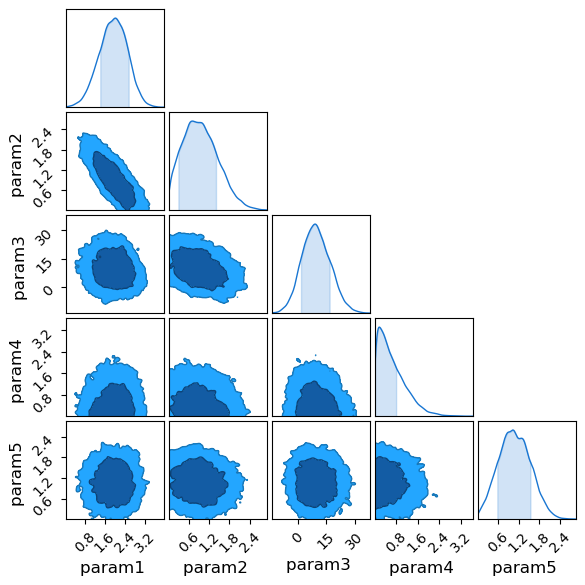

std [0.55297116 0.51556502 7.39997966 0.51348698 0.45725868]
[ 1.88785619  0.95540176 10.19070823  0.08282965  1.0633126 ] [1.94530392 0.90869949 9.43157362 0.52277317 1.06504798]


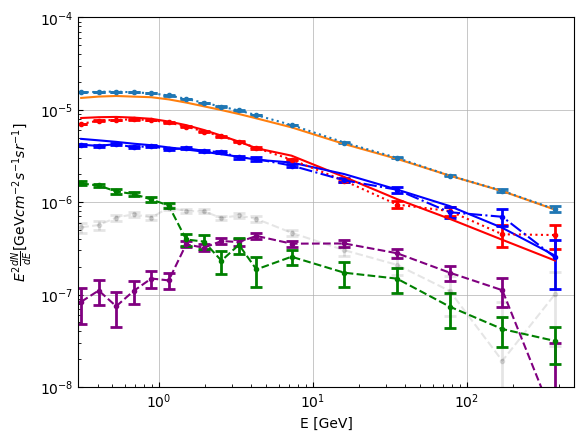

1.0094802575442767e-07
7.033134414935265e-08
7.76977716420412e-08


In [21]:
n=len(E)
fitted_params=np.ones([n*5])
fitted_params_median=np.ones([n*5])
fitted_params_std = np.zeros([n*5])
max_likelihood = np.zeros([n])

fitted_params_upper = np.zeros([n*5])
fitted_params_lower = np.zeros([n*5])
for i in range(0, n, 1):
    max_value, median_value, std_value, maximum_value, upper_value, lower_value = run_mcmc_for_bin(i)
    fitted_params[n*0:n*1][i] = max_value[0]
    fitted_params[n*1:n*2][i] = max_value[1]
    fitted_params[n*2:n*3][i] = max_value[2]
    fitted_params[n*3:n*4][i] = max_value[3]
    fitted_params[n*4:n*5][i] = max_value[4]

    fitted_params_std[n*0:n*1][i] = std_value[0]
    fitted_params_std[n*1:n*2][i] = std_value[1]
    fitted_params_std[n*2:n*3][i] = std_value[2]
    fitted_params_std[n*3:n*4][i] = std_value[3]
    fitted_params_std[n*4:n*5][i] = std_value[4]

    fitted_params_median[n*0:n*1][i] = median_value[0]
    fitted_params_median[n*1:n*2][i] = median_value[1]
    fitted_params_median[n*2:n*3][i] = median_value[2]
    fitted_params_median[n*3:n*4][i] = median_value[3]
    fitted_params_median[n*4:n*5][i] = median_value[4]

    fitted_params_upper[n*0:n*1][i] = upper_value[0]
    fitted_params_upper[n*1:n*2][i] = upper_value[1]
    fitted_params_upper[n*2:n*3][i] = upper_value[2]
    fitted_params_upper[n*3:n*4][i] = upper_value[3]
    fitted_params_upper[n*4:n*5][i] = upper_value[4]


    fitted_params_lower[n*0:n*1][i] = lower_value[0]
    fitted_params_lower[n*1:n*2][i] = lower_value[1]
    fitted_params_lower[n*2:n*3][i] = lower_value[2]
    fitted_params_lower[n*3:n*4][i] = lower_value[3]
    fitted_params_lower[n*4:n*5][i] = lower_value[4]


    max_likelihood[i] = maximum_value
    
    plt.style.use('default')
    ax=plt.subplot()
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('E [GeV]')
    ax.set_ylabel(r'$E^2 \frac{dN}{dE}$[GeV$cm^{-2}$$s^{-1} sr^{-1}$]')
    
    ax.set_ylim(1e-8, 1e-4)
    ax.set_xlim(0.3, 500)
    
    ax.tick_params(axis='y', which='both', direction='in', left=True)
    ax.tick_params(axis='x', which='both', direction='in', bottom=True)
    ax.minorticks_on()
    ax.grid(True, which='Major', linestyle='-', linewidth=0.5)
    
    fitted=fitted_params#fitted_params
    fitted_errors=fitted_params_std
    #sr=0.4288213187542626#0.214411*2
    sr=1
    #sr=0.4387
    #sr=0.4776

    ax.errorbar(E, counts_per_exp*(E**2)/(delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')
    
    
    
    
    ax.errorbar(E, fitted[n*0:n*1]*(pion+bremss)*(E**2)/(delta_E*sr), yerr=fitted_errors[n*0:n*1]*(pion+bremss)*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='pion+bremss', color='red')
    ax.errorbar(E, fitted[n*1:n*2]*(ics)*(E**2)/(delta_E*sr), yerr=fitted_errors[n*1:n*2]*(ics)*(E**2)/(delta_E*sr), linestyle='dashdot', marker='.', elinewidth=2, capsize=4, capthick=2, label='ics', color='blue')
    
    ax.plot(E, (pion+bremss)*(E**2)/(delta_E*sr), linestyle='solid', label='pion+bremss', color='red')
    ax.plot(E, (ics)*(E**2)/(delta_E*sr), linestyle='solid', label='ics', color='blue')
    
    
    
    ax.errorbar(E,  fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E*sr), yerr=np.sqrt((fitted_errors[n*2:n*3]*GCE)**2)*(E**2)/(delta_E*sr), alpha=0.1, linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')
    
    
    
    ax.errorbar(E, fitted[n*3:n*4]*(bubble)*(E**2)/(delta_E*sr),yerr=fitted_errors[n*3:n*4]*(bubble)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='bubble', color='purple')
    
    ax.errorbar(E, fitted[n*4:n*5]*(isotropic)*(E**2)/(delta_E*sr),yerr=fitted_errors[n*4:n*5]*(isotropic)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='isotropic', color='green')
    summed = fitted[n*0:n*1]*(pion+bremss) + fitted[n*1:n*2]*(ics) + fitted[n*2:n*3]*(GCE) + fitted[n*3:n*4]*(bubble) + fitted[n*4:n*5]*(isotropic)

    ax.plot(E, (E**2)*summed/(delta_E*sr), label='summed')
    
    
    plt.show()

    print((fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E*sr))[i])
    print(((fitted_params_upper[n*2:n*3] - fitted[n*2:n*3])*(GCE)*(E**2)/(delta_E*sr))[i])
    print(((fitted[n*2:n*3]- fitted_params_lower[n*2:n*3]  )*(GCE)*(E**2)/(delta_E*sr))[i])

                                                            



In [40]:
np.savetxt(f'./GCE_model_{model}_12yr_likelihood_value', np.array((max_likelihood))) #Positive of log likelihood

In [22]:
np.savetxt('./GCE_model_I_front_clean_12yr.dat', np.vstack([E, fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E), (fitted_errors[n*2:n*3]*GCE)*(E**2)/(delta_E), (fitted_params_lower[n*2:n*3])*(GCE)*(E**2)/(delta_E), (fitted_params_upper[n*2:n*3])*(GCE)*(E**2)/(delta_E)]).T)


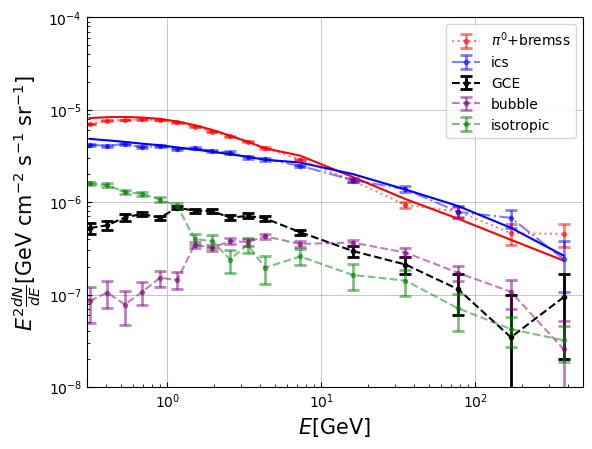

In [46]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
plt.style.use('default')
ax=plt.subplot()
n=len(E)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$E$[GeV]', fontsize=15)
ax.set_ylabel(r'${E}^2 \frac{{dN}}{{dE}}$[GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=15)

ax.set_ylim(1e-8, 1e-4)
ax.set_xlim(0.3, 500)

ax.tick_params(axis='y', which='both', direction='in', left=True)
ax.tick_params(axis='x', which='both', direction='in', bottom=True)
ax.minorticks_on()
ax.grid(True, which='Major', linestyle='-', linewidth=0.5)

fitted=(fitted_params_median)
fitted_errors=fitted_params_std
sr=1#0.4288213187542626#0.214411*2
#sr=0.4387
#ax.errorbar(E, counts_per_exp*(E**2)/(delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')


#ax.errorbar(E, psc*(E**2)/(delta_E*sr), linestyle='', marker='.', elinewidth=2, capsize=4, capthick=2, label='psc', color='orange')


#ax.errorbar(E, counts_per_exp*(E**2)/(delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')
#ax.errorbar(E, counts_per_exp*(E**2)/(delta_E) , yerr=np.zeros(len(E)), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')

    
    

ax.errorbar(E, fitted[n*0:n*1]*(pion+bremss)*(E**2)/(delta_E), yerr=fitted_errors[n*0:n*1]*(pion+bremss)*(E**2)/(delta_E), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label=r'$\pi^0$+bremss', color='red', alpha=0.5)
ax.errorbar(E, fitted[n*1:n*2]*(ics)*(E**2)/(delta_E), yerr=fitted_errors[n*1:n*2]*(ics)*(E**2)/(delta_E), linestyle='dashdot', marker='.', elinewidth=2, capsize=4, capthick=2, label='ics', color='blue', alpha=0.5)

#ax.plot(E, (pion+bremss)*(E**2)/(delta_E), linestyle='solid', label='pion+bremss', color='red')
#ax.plot(E, (ics)*(E**2)/(delta_E), linestyle='solid', label='ics', color='blue')
ax.plot(E, (pion+bremss)*(E**2)/(delta_E), linestyle='solid', color='red')
ax.plot(E, (ics)*(E**2)/(delta_E), linestyle='solid', color='blue')


ax.errorbar(E,  fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E), yerr=(fitted_errors[n*2:n*3]*GCE)*(E**2)/(delta_E), alpha=1, linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')
#ax.errorbar(E,  fitted_params_median[n*2:n*3]*(GCE)*(E**2)/(delta_E), yerr=(fitted_errors[n*2:n*3]*GCE)*(E**2)/(delta_E), alpha=1, linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')



ax.errorbar(E, fitted[n*3:n*4]*(bubble)*(E**2)/(delta_E),yerr=fitted_errors[n*3:n*4]*(bubble)*(E**2)/(delta_E), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='bubble', color='purple', alpha=0.5)

ax.errorbar(E, fitted[n*4:n*5]*(isotropic)*(E**2)/(delta_E),yerr=fitted_errors[n*4:n*5]*(isotropic)*(E**2)/(delta_E), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='isotropic', color='green', alpha=0.5)
summed = fitted[n*0:n*1]*(pion+bremss) + fitted[n*1:n*2]*(ics) + fitted[n*2:n*3]*(GCE) + fitted[n*3:n*4]*(bubble) + fitted[n*4:n*5]*(isotropic)

#ax.plot(E, (E**2)*summed/(delta_E), label='summed')

ax.legend()

plt.show()

#ax.errorbar(E, bubble_flux_data, [bubble_lower_error_data, bubble_upper_error_data])
#ax.plot(E, bubble_flux_data)
#ax.plot(E, iso_constraints_flux) 
#plt.savefig('./GC_analysis/Model_I.png')

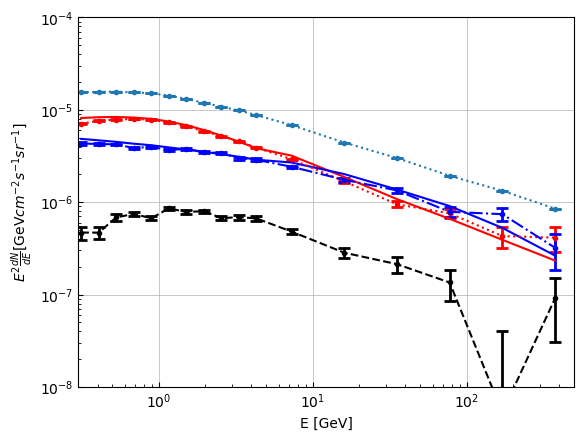

In [398]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
plt.style.use('default')
ax=plt.subplot()
n=len(E)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('E [GeV]')
ax.set_ylabel(r'$E^2 \frac{dN}{dE}$[GeV$cm^{-2}$$s^{-1} sr^{-1}$]')

ax.set_ylim(1e-8, 1e-4)
ax.set_xlim(0.3, 500)

ax.tick_params(axis='y', which='both', direction='in', left=True)
ax.tick_params(axis='x', which='both', direction='in', bottom=True)
ax.minorticks_on()
ax.grid(True, which='Major', linestyle='-', linewidth=0.5)

fitted=(fitted_params)
fitted_errors=fitted_params_std
sr=1#0.4288213187542626#0.214411*2
#sr=0.4387
#ax.errorbar(E, counts_per_exp*(E**2)/(delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')


#ax.errorbar(E, psc*(E**2)/(delta_E*sr), linestyle='', marker='.', elinewidth=2, capsize=4, capthick=2, label='psc', color='orange')


#ax.errorbar(E, counts_per_exp*(E**2)/(delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')
ax.errorbar(E, counts_per_exp*(E**2)/(delta_E) , yerr=np.zeros(len(E)), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')

    
    

ax.errorbar(E, fitted[n*0:n*1]*(pion+bremss)*(E**2)/(delta_E), yerr=fitted_errors[n*0:n*1]*(pion+bremss)*(E**2)/(delta_E), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='pion+bremss', color='red')
ax.errorbar(E, fitted[n*1:n*2]*(ics)*(E**2)/(delta_E), yerr=fitted_errors[n*1:n*2]*(ics)*(E**2)/(delta_E), alpha=1, linestyle='dashdot', marker='.', elinewidth=2, capsize=4, capthick=2, label='ics', color='blue')

ax.plot(E, (pion+bremss)*(E**2)/(delta_E), linestyle='solid', label='pion+bremss', color='red')
ax.plot(E, (ics)*(E**2)/(delta_E), linestyle='solid', label='ics', color='blue')


ax.errorbar(E,  fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E), yerr=(fitted_errors[n*2:n*3]*GCE)*(E**2)/(delta_E), alpha=1, linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')
#ax.errorbar(E,  fitted_params_median[n*2:n*3]*(GCE)*(E**2)/(delta_E), yerr=(fitted_errors[n*2:n*3]*GCE)*(E**2)/(delta_E), alpha=1, linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')



#ax.errorbar(E, fitted[n*3:n*4]*(bubble)*(E**2)/(delta_E),yerr=fitted_errors[n*3:n*4]*(bubble)*(E**2)/(delta_E), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='bubble', color='purple')

#ax.errorbar(E, fitted[n*4:n*5]*(isotropic)*(E**2)/(delta_E),yerr=fitted_errors[n*4:n*5]*(isotropic)*(E**2)/(delta_E), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='isotropic', color='green')
#summed = fitted[n*0:n*1]*(pion+bremss) + fitted[n*1:n*2]*(ics)  + fitted[n*3:n*4]*(bubble) + fitted[n*4:n*5]*(isotropic)

#ax.plot(E, (E**2)*summed/(delta_E), label='summed')


plt.show()

#ax.errorbar(E, bubble_flux_data, [bubble_lower_error_data, bubble_upper_error_data])
#ax.plot(E, bubble_flux_data)
#ax.plot(E, iso_constraints_flux) 
ax.legend()
#plt.savefig('./GC_analysis/Model_I.png')

In [344]:
lhd_value = []
for model_name in ['X', 'XV', 'XLVIII', 'XLIX' ,'LIII', 'II', 'LXIV', 'LXIX', 'LXX','LXXI']:
    lhd_value.append([model_name, np.sum(np.loadtxt(f'./GCE_model_{model_name}_12yr_cholis_likelihood_value')[0:14])])
    
#lhd_value.append([np.loadtxt(f'./GCE_model_{"I"}_12yr_cholis_likelihood_value'), 'I'])


In [345]:
lhd_value

[['X', -333993.7544737562],
 ['XV', -334064.7699773154],
 ['XLVIII', -334205.62604522007],
 ['XLIX', -334316.10845207394],
 ['LIII', -334026.68894742616],
 ['II', -344182.6298274954],
 ['LXIV', -346985.59756020596],
 ['LXIX', -344703.1992368305],
 ['LXX', -345104.70014428394],
 ['LXXI', -347187.72920129367]]

In [ ]:
self.energy_bin=energy_bin
self.data=fits.open(f'./GC_analysis/GC_ccube_12yr_front_clean.fits')[0].data[self.energy_bin, 100:500, 100:500]
self.pion_bremss=fits.open(f'./GC_analysis/GC_pion_model{model}_12yr_front_clean.fits')[0].data[self.energy_bin, 100:500, 100:500] + fits.open(f'./GC_analysis/GC_bremss_model{model}_12yr_front_clean.fits')[0].data[self.energy_bin, 100:500, 100:500]  
self.ics=fits.open(f'./GC_analysis/GC_ics_model{model}_12yr_front_clean.fits')[0].data[self.energy_bin, 100:500, 100:500]
self.GCE=fits.open(f'./GC_analysis/GC_GCE_model_12yr_front_clean.fits')[0].data[self.energy_bin, 100:500, 100:500]
self.bubble=fits.open(f'./GC_analysis/GC_fermi_bubble_model_12yr_front_clean.fits')[0].data[self.energy_bin, 100:500, 100:500]
self.iso=fits.open(f'./GC_analysis/GC_isotropic_model_12yr_front_clean.fits')[0].data[self.energy_bin, 100:500, 100:500]

E_bounds=fits.open(f'./GC_analysis/GC_ccube_12yr_front_clean.fits')[1].data

E=np.zeros(len(E_bounds))
for i in range(0, len(E_bounds), 1):
    E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)*1e-3
self.E = E
delta_E=np.zeros(len(E_bounds))
for i in range(0, len(E_bounds), 1):
    delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-6
self.delta_E = delta_E
self.exp_cube = (fits.open(f'./GC_analysis/GC_expcube_center_12yr_front_clean.fits')[0].data[self.energy_bin]*steradian_per_pixel)#[100:500, 100:500]

In [157]:
n=17

In [289]:
param=np.ones(17*5)
param=np.loadtxt('./parameter_without_GCE.txt')
model='I'

In [290]:
data=fits.open(f'./GC_analysis/GC_ccube_12yr_front_clean.fits')[0].data
pion_bremss=fits.open(f'./GC_analysis/GC_pion_model{model}_12yr_front_clean.fits')[0].data + fits.open(f'./GC_analysis/GC_bremss_model{model}_12yr_front_clean.fits')[0].data
ics=fits.open(f'./GC_analysis/GC_ics_model{model}_12yr_front_clean.fits')[0].data
GCE=fits.open(f'./GC_analysis/GC_GCE_model_12yr_front_clean.fits')[0].data
bubble=fits.open(f'./GC_analysis/GC_fermi_bubble_model_12yr_front_clean.fits')[0].data
iso=fits.open(f'./GC_analysis/GC_isotropic_model_12yr_front_clean.fits')[0].data
psc=fits.open('./GC_analysis/GC_psc_model_12yr_front_clean_no_convol.fits')[0].data

expected_map=np.zeros(np.shape(psc))
for i in range(len(expected_map)):
    expected_map[i]= param[0*n:1*n][i]*pion_bremss[i] + param[1*n:2*n][i]*ics[i]  + (param[4*n:5*n][i])*iso[i] + (param[3*n:4*n][i])*bubble[i]# + psc[i]
    #expected_map[i]= param[0*n:1*n][i]*pion_bremss[i] + param[1*n:2*n][i]*ics[i]  + (param[4*n:5*n][i])*iso[i] + (param[3*n:4*n][i])*bubble[i] +  param[2*n:3*n][i]*GCE[i]# + psc[i]

    #expected_map[i]= pion_bremss[i] + ics[i]  + iso[i] + bubble[i] + psc[i]

#expected_map= pion_bremss + ics  + iso + bubble + psc

raw_map = fits.open('./GC_analysis/GC_ccube_12yr_front_clean.fits')[0].data
exposure=fits.open(f'./GC_analysis/GC_expcube_center_12yr_front_clean.fits')[0].data[:]*steradian_per_pixel


In [291]:
psc_mask = np.load('./GC_analysis/Model/GC_mask_60x60_definitions_DR2.npy')
disk_mask = np.load('./GC_analysis/Model/GC_disk_mask_60x60_definitions.npy')

Set MJD-END to 60451.692859 from DATE-END'. [astropy.wcs.wcs]
Set MJD-END to 60451.692859 from DATE-END'.


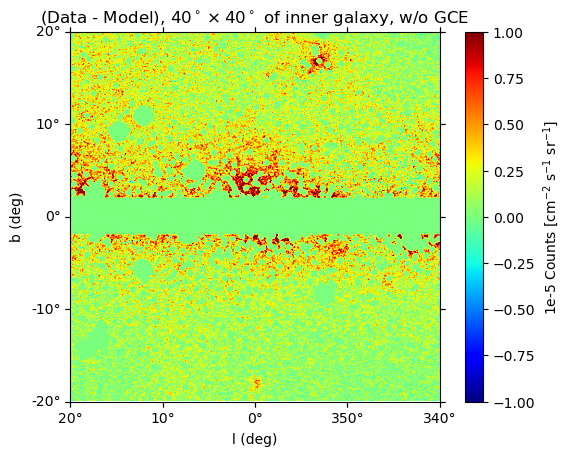

In [294]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
import numpy as np

# Open the FITS file and read WCS
src_1 = fits.open('./GC_analysis/GC_ccube_12yr_front_clean.fits')
w = WCS(src_1[0].header).dropaxis(2)

# Define the subset indices for the inner Galactic Center region
# Assuming a 600x600 grid where each pixel = 0.1 degree
subset = (slice(275, 325), slice(275, 325))  # 100x100 pixels = 10x10 degrees
#subset = (slice(, 335), slice(265, 335))  # 100x100 pixels = 10x10 degrees
#subset = (slice(, 335), slice(265, 335))  # 100x100 pixels = 10x10 degrees
subset = (slice(100, 500), slice(100, 500))  # 100x100 pixels = 10x10 degrees


data_map = np.sum(raw_map[5:8]*psc_mask[5]*disk_mask/exposure[5:8], axis=(0)) #np.sum((raw_map)[4:10], axis=0)
model_map = np.sum(expected_map[5:8]*psc_mask[5]*disk_mask/exposure[5:8], axis=(0)) #np.sum((expected_map)[4:10], axis=0)

#data_map = np.sum(raw_map[4:10]/exposure[4:10], axis=0) #np.sum((raw_map)[4:10], axis=0)
#model_map = np.sum(expected_map[4:10]/exposure[4:10], axis=0) #np.sum((expected_map)[4:10], axis=0)



# Extract the region of interest from the map
data_subset = ( (data_map - model_map)/1e-5 )[subset]

# Update the WCS to match the sliced data
w_subset = w.slice((subset[0], subset[1]))

# Plotting the subset with the correct WCS
fig = plt.figure()
ax = fig.add_subplot(111, projection=w_subset)  # Use the updated WCS
ax.coords[0].set_format_unit('deg', decimal=True, show_decimal_unit=True)
ax.coords[1].set_format_unit('deg', decimal=True, show_decimal_unit=True)

# Plot the data
plot = ax.imshow(
    (data_subset), 
    origin='lower', 
    cmap='jet', 
    interpolation='gaussian'
    ,vmin=-1, vmax=1
)

# Add labels, grid, and colorbar
#plt.grid(color='white', ls='solid')
plt.xlabel('l (deg)')  # Galactic longitude
plt.ylabel('b (deg)')  # Galactic latitude
cbar = plt.colorbar(plot)
cbar.set_label(r'1e-5 Counts [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.title(r"(Data - Model), $40^\circ \times 40^\circ$ of inner galaxy, w/o GCE")
plt.show()


In [278]:
E[5:8]

array([1.16034479, 1.50678468, 1.96285509])

In [279]:
E_bounds

FITS_rec([( 1, 2.75000e+05, 3.57000e+05), ( 2, 3.57000e+05, 4.64000e+05),
          ( 3, 4.64000e+05, 6.03000e+05), ( 4, 6.03000e+05, 7.84000e+05),
          ( 5, 7.84000e+05, 1.02000e+06), ( 6, 1.02000e+06, 1.32000e+06),
          ( 7, 1.32000e+06, 1.72000e+06), ( 8, 1.72000e+06, 2.24000e+06),
          ( 9, 2.24000e+06, 2.91000e+06), (10, 2.91000e+06, 3.78000e+06),
          (11, 3.78000e+06, 4.91000e+06), (12, 4.91000e+06, 1.08000e+07),
          (13, 1.08000e+07, 2.37560e+07), (14, 2.37560e+07, 5.22530e+07),
          (15, 5.22530e+07, 1.14935e+08), (16, 1.14935e+08, 2.52809e+08),
          (17, 2.52809e+08, 5.56077e+08)],
         dtype=(numpy.record, [('CHANNEL', '>i2'), ('E_MIN', '>f4'), ('E_MAX', '>f4')]))

In [231]:
1.02 - 2.91

array([1.16034479, 1.50678468, 1.96285509])

In [242]:
E[8]

2.5531157098666717

In [217]:
300-30/2

285.0

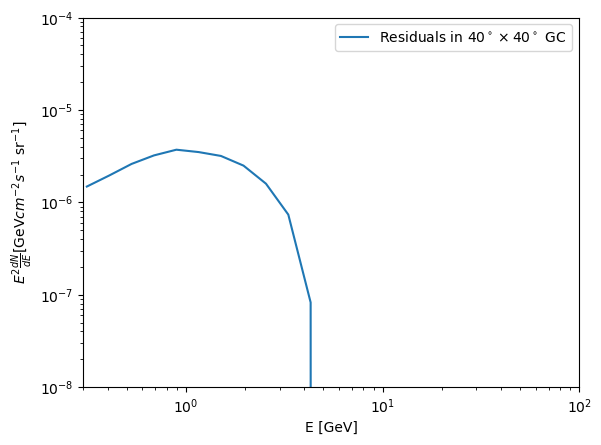

In [295]:
plt.loglog(E, E**2*np.sum(( ( (raw_map - expected_map)/exposure)*disk_mask*psc_mask )[:, 100:500, 100:500], axis=(1, 2))/delta_E/(400*400), label=r'Residuals in $40^\circ \times 40^\circ$ GC')
plt.ylim(1e-8, 1e-4)
plt.xlim(0.3, 100)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('E [GeV]')
plt.ylabel(r'$E^2 \frac{dN}{dE}$[GeV$cm^{-2}$$s^{-1}$ sr$^{-1}$]')
plt.legend()

In [219]:
E**2*np.sum(( ( (raw_map - expected_map)/exposure)*disk_mask*psc_mask )[:, 100:500, 100:500], axis=(1, 2))/delta_E/(400*400)

array([-2.12147323e+00,  3.10469692e+08, -4.14157464e+02,  1.69486371e-01,
       -9.48420255e-01, -1.57154707e+04, -3.22364566e+09, -1.40519663e+12,
        1.02099331e+01,  2.52537578e+02, -5.16176037e+06, -7.40707705e+05,
       -1.85680430e+02, -3.10090567e+14,  3.36548233e+15, -6.67067612e+13,
        1.69974357e+09])

In [161]:
np.sum(( ( (raw_map - expected_map)/exposure)*disk_mask*psc_mask )[:, 100:500, 100:500], axis=(1, 2))

array([ 1.97997030e-01,  2.01559968e-01,  2.06911417e-01,  1.97150870e-01,
        1.75248303e-01,  1.24707626e-01,  8.95361834e-02,  5.38872431e-02,
        2.61718986e-02,  9.31646990e-03,  8.03668159e-04, -8.32224336e-03,
       -7.23330708e-03, -2.98757253e-03, -1.38602576e-03, -5.73184828e-04,
       -1.81742449e-04])

In [190]:
np.savetxt('./parameter_without_GCE.txt', fitted)

In [1751]:
(fitted_params_upper[n*2:n*3] - fitted[n*2:n*3])*(GCE)*(E**2)/(delta_E)

array([5.34607773e-08, 6.82963484e-08, 5.28586268e-08, 4.39776282e-08,
       3.42991037e-08, 4.17672026e-08, 4.26967286e-08, 4.33823809e-08,
       3.71797497e-08, 5.23528553e-08, 4.01319273e-08, 3.19247207e-08,
       3.83271379e-08, 3.57967524e-08])

In [1754]:
((fitted_params_upper[n*2:n*3] - fitted[n*2:n*3])*(GCE)*(E**2)/(delta_E) +  (fitted[n*2:n*3] - fitted_params_lower[n*2:n*3])*(GCE)*(E**2)/(delta_E))/2

array([9.09139682e-08, 8.06723271e-08, 7.42517176e-08, 5.82392242e-08,
       5.08619766e-08, 5.08057753e-08, 4.42753088e-08, 4.42083014e-08,
       4.50727817e-08, 5.08058129e-08, 5.60431319e-08, 3.58756043e-08,
       4.30257913e-08, 4.97325761e-08])

In [126]:
(fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E))[0:15]

array([5.27114462e-07, 5.03943723e-07, 6.71304227e-07, 7.28036999e-07,
       6.44872232e-07, 8.25653982e-07, 7.54225827e-07, 7.71016541e-07,
       6.56196136e-07, 6.70973752e-07, 6.57225581e-07, 4.67612486e-07,
       2.75242143e-07, 2.03726875e-07, 1.40126374e-07])

In [19]:
fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E)

array([ 5.21321597e-07,  4.97278801e-07,  6.75982258e-07,  7.22400946e-07,
        6.42494329e-07,  8.25524412e-07,  7.58809797e-07,  7.75531595e-07,
        6.50597959e-07,  6.71057093e-07,  6.58659045e-07,  4.66265479e-07,
        2.79005399e-07,  2.04063852e-07,  1.36516378e-07, -5.50656669e-09,
        9.14627680e-08])

In [122]:
(fitted_errors[n*2:n*3]*GCE)*(E**2)/(delta_E)

array([7.43102574e-08, 6.90719487e-08, 6.03192462e-08, 4.88855306e-08,
       4.31563241e-08, 4.03438709e-08, 3.72763971e-08, 3.88552076e-08,
       4.07525780e-08, 4.47489310e-08, 4.72135104e-08, 3.16535730e-08,
       3.78732995e-08, 4.47211373e-08, 5.29266085e-08, 6.60460602e-08,
       7.37815045e-08])

In [338]:
np.savetxt('./GCE_model_I_12yr_positive.dat', np.vstack([E, fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E), (fitted_errors[n*2:n*3]*GCE)*(E**2)/(delta_E), (fitted_params_lower[n*2:n*3])*(GCE)*(E**2)/(delta_E), (fitted_params_upper[n*2:n*3])*(GCE)*(E**2)/(delta_E)]).T)



In [1745]:
np.savetxt('./GCE_model_I_test_test_test_test.dat', np.vstack([E, fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E), (fitted_errors[n*2:n*3]*GCE)*(E**2)/(delta_E)]).T)

In [1746]:
np.loadtxt('./GCE_model_I_test_test_test.dat')

array([[3.13328902e-01, 5.81565215e-07, 1.21768689e-07],
       [4.06998780e-01, 6.07412357e-07, 1.46216429e-07],
       [5.28953677e-01, 6.53013164e-07, 1.59727307e-07],
       [6.87569631e-01, 7.29659107e-07, 1.78823224e-07],
       [8.94248272e-01, 6.81759116e-07, 1.88317092e-07],
       [1.16034479e+00, 8.80597901e-07, 2.22746018e-07],
       [1.50678468e+00, 7.95704260e-07, 2.28362391e-07],
       [1.96285509e+00, 7.71535684e-07, 3.11625947e-07],
       [2.55311571e+00, 6.76035997e-07, 2.79843487e-07],
       [3.31659468e+00, 7.29564191e-07, 2.03370155e-07],
       [4.30810856e+00, 6.75265903e-07, 1.44221158e-07],
       [7.28203256e+00, 4.36291683e-07, 1.62084558e-07],
       [1.59987500e+01, 2.96394370e-07, 1.03306677e-07],
       [3.50717842e+01, 2.07491996e-07, 7.41290178e-08]])

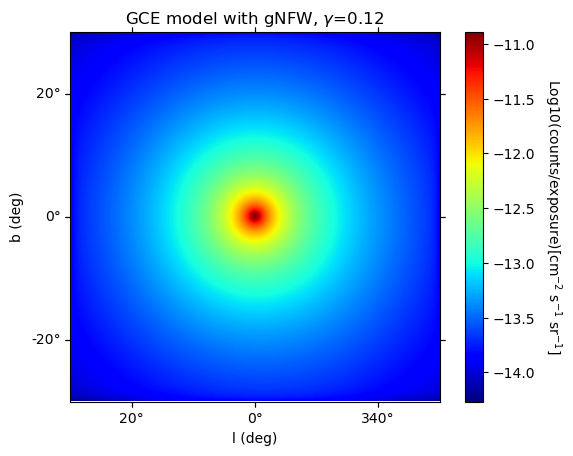

In [372]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
import numpy as np

# Open the FITS file and read WCS
src_1 = fits.open('./GC_analysis/Model/GC_60x60_GCE_model_front_12yr.fits')
w = WCS(src_1[0].header).dropaxis(2)
exposure=fits.open('./GC_analysis/GC_expcube_center_12yr_front_clean.fits')[0].data
# Define the subset indices for the inner Galactic Center region
# Assuming a 600x600 grid where each pixel = 0.1 degree
#subset = (slice(275, 325), slice(275, 325))  # 100x100 pixels = 10x10 degrees
#subset = (slice(, 335), slice(265, 335))  # 100x100 pixels = 10x10 degrees
#subset = (slice(, 335), slice(265, 335))  # 100x100 pixels = 10x10 degrees
#subset = (slice(100, 500), slice(100, 500))  # 100x100 pixels = 10x10 degrees
subset = (slice(0, 600), slice(0, 600))  # 100x100 pixels = 10x10 degrees



# Extract the region of interest from the map
data_subset = src_1[0].data[0]

# Update the WCS to match the sliced data
w_subset = w.slice((subset[0], subset[1]))

# Plotting the subset with the correct WCS
fig = plt.figure()
ax = fig.add_subplot(111, projection=w_subset)  # Use the updated WCS
ax.coords[0].set_format_unit('deg', decimal=True, show_decimal_unit=True)
ax.coords[1].set_format_unit('deg', decimal=True, show_decimal_unit=True)

# Plot the data
plot = ax.imshow(
    np.log10(data_subset/exposure[0]/steradian_per_pixel), 
    origin='lower', 
    cmap='jet', 
    interpolation='gaussian'
    #,vmin=-1, vmax=1
)

# Add labels, grid, and colorbar
#plt.grid(color='white', ls='solid')
plt.xlabel('l (deg)')  # Galactic longitude
plt.ylabel('b (deg)')  # Galactic latitude
cbar = plt.colorbar(plot)
cbar.set_label(r'Log10(counts/exposure)[cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', rotation=270, labelpad=20)
plt.title(r"GCE model with gNFW, $\gamma$=0.12")
plt.show()


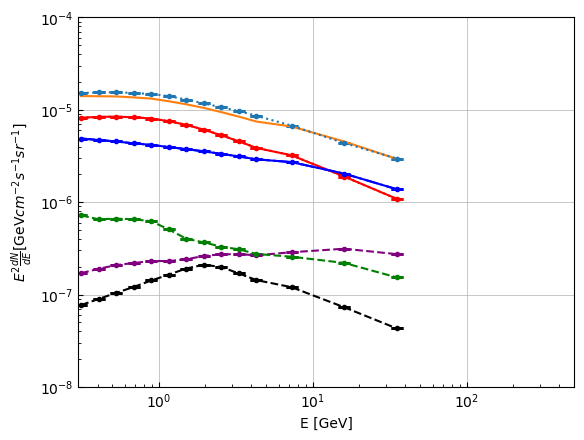

In [428]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
plt.style.use('default')
ax=plt.subplot()
n=14
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('E [GeV]')
ax.set_ylabel(r'$E^2 \frac{dN}{dE}$[GeV$cm^{-2}$$s^{-1} sr^{-1}$]')

ax.set_ylim(1e-8, 1e-4)
ax.set_xlim(0.3, 500)

ax.tick_params(axis='y', which='both', direction='in', left=True)
ax.tick_params(axis='x', which='both', direction='in', bottom=True)
ax.minorticks_on()
ax.grid(True, which='Major', linestyle='-', linewidth=0.5)

fitted=np.ones(n*5)#(fitted_params)
fitted_errors=np.zeros(n*5)#fitted_params_std
sr=0.4288213187542626#0.214411*2
#sr=0.4387
#ax.errorbar(E, counts_per_exp*(E**2)/(delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')


#ax.errorbar(E, psc*(E**2)/(delta_E*sr), linestyle='', marker='.', elinewidth=2, capsize=4, capthick=2, label='psc', color='orange')


#ax.errorbar(E, counts_per_exp*(E**2)/(delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')
ax.errorbar(E, counts_per_exp*(E**2)/(delta_E*sr) , yerr=np.zeros(14), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')

    
    

ax.errorbar(E, fitted[n*0:n*1]*(pion+bremss)*(E**2)/(delta_E*sr), yerr=fitted_errors[n*0:n*1]*(pion+bremss)*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='pion+bremss', color='red')
ax.errorbar(E, fitted[n*1:n*2]*(ics)*(E**2)/(delta_E*sr), yerr=fitted_errors[n*1:n*2]*(ics)*(E**2)/(delta_E*sr), linestyle='dashdot', marker='.', elinewidth=2, capsize=4, capthick=2, label='ics', color='blue')

ax.plot(E, (pion+bremss)*(E**2)/(delta_E*sr), linestyle='solid', label='pion+bremss', color='red')
ax.plot(E, (ics)*(E**2)/(delta_E*sr), linestyle='solid', label='ics', color='blue')



ax.errorbar(E,  fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E*sr), yerr=np.sqrt((fitted_errors[n*2:n*3]*GCE)**2)*(E**2)/(delta_E*sr), alpha=1, linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')



ax.errorbar(E, fitted[n*3:n*4]*(bubble)*(E**2)/(delta_E*sr),yerr=fitted_errors[n*3:n*4]*(bubble)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='bubble', color='purple')

ax.errorbar(E, fitted[n*4:n*5]*(isotropic)*(E**2)/(delta_E*sr),yerr=fitted_errors[n*4:n*5]*(isotropic)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='isotropic', color='green')
summed = fitted[n*0:n*1]*(pion+bremss) + fitted[n*1:n*2]*(ics) + fitted[n*2:n*3]*(GCE) + fitted[n*3:n*4]*(bubble) + fitted[n*4:n*5]*(isotropic)

ax.plot(E, (E**2)*summed/(delta_E*sr), label='summed')


plt.show()

#ax.errorbar(E, bubble_flux_data, [bubble_lower_error_data, bubble_upper_error_data])
#ax.plot(E, bubble_flux_data)
#ax.plot(E, iso_constraints_flux) 
ax.legend()
#plt.savefig('./GC_analysis/Model_I.png')

In [379]:
lhd_value=[]
for name in ['I', 'IV', 'V', 'VI', 'VII', 'IX', 'X', 'XV', 'XLI', 'XLVII', 'XLVIII', 'XLIX', 'L', 'LII']:#, 'LIII']
    lhd_value.append([name, np.sum(np.loadtxt(f'./GCE_model_{name}_12yr_cholis_likelihood_value'))])

In [392]:
np.sort(lhd_value, axis=1)

array([['-1870388.0411943493', 'I'],
       ['-1870335.2023792467', 'IV'],
       ['-1870335.6812502367', 'V'],
       ['-1870379.9262094162', 'VI'],
       ['-1870222.532762554', 'VII'],
       ['-1870438.542162718', 'IX'],
       ['-1869954.4795782857', 'X'],
       ['-1870098.4728561542', 'XV'],
       ['-1870189.925966878', 'XLI'],
       ['-1870268.107144115', 'XLVII'],
       ['-1870281.4726645355', 'XLVIII'],
       ['-1870428.8773003318', 'XLIX'],
       ['-1870863.172341088', 'L'],
       ['-1870639.7777366885', 'LII']], dtype='<U32')

In [394]:
sorted_data = sorted(lhd_value, key=lambda x: x[1], reverse=True)

# Print the sorted list
for item in sorted_data:
    print(item)

['X', -1869954.4795782857]
['XV', -1870098.4728561542]
['XLI', -1870189.925966878]
['VII', -1870222.532762554]
['XLVII', -1870268.107144115]
['XLVIII', -1870281.4726645355]
['IV', -1870335.2023792467]
['V', -1870335.6812502367]
['VI', -1870379.9262094162]
['I', -1870388.0411943493]
['XLIX', -1870428.8773003318]
['IX', -1870438.542162718]
['LII', -1870639.7777366885]
['L', -1870863.172341088]


In [149]:
fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E)

array([0.01099398, 0.0127771 , 0.01488254, 0.01723908, 0.02024948,
       0.02343306, 0.02728819, 0.02997456, 0.0283162 , 0.0241094 ,
       0.02044686, 0.01714541, 0.0104    , 0.0061395 ])

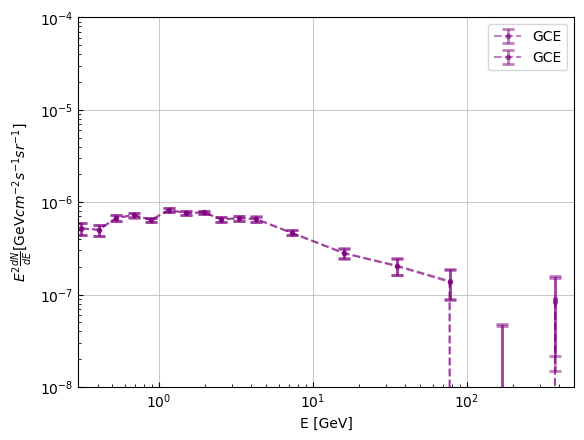

In [31]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
plt.style.use('default')
ax=plt.subplot()

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('E [GeV]')
ax.set_ylabel(r'$E^2 \frac{dN}{dE}$[GeV$cm^{-2}$$s^{-1} sr^{-1}$]')

ax.set_ylim(1e-8, 1e-4)
ax.set_xlim(0.3, 500)

ax.tick_params(axis='y', which='both', direction='in', left=True)
ax.tick_params(axis='x', which='both', direction='in', bottom=True)
ax.minorticks_on()
ax.grid(True, which='Major', linestyle='-', linewidth=0.5)

fitted=(fitted_params)
fitted_errors=fitted_params_std
sr=1#0.214411*2

#ax.errorbar(E, counts_per_exp*(E**2)/(delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')


#ax.errorbar(E, fitted[0:17]*(pion+bremss)*(E**2)/(delta_E*sr), yerr=fitted_errors[0:17]*(pion+bremss)*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='pion+bremss', color='red')
#ax.errorbar(E, fitted[17:34]*(ics)*(E**2)/(delta_E*sr), yerr=fitted_errors[17:34]*(ics)*(E**2)/(delta_E*sr), linestyle='dashdot', marker='.', elinewidth=2, capsize=4, capthick=2, label='ics', color='blue')

#ax.plot(E, (pion+bremss)*(E**2)/(delta_E*sr), linestyle='solid', label='pion+bremss', color='red')
#ax.plot(E, (ics)*(E**2)/(delta_E*sr), linestyle='solid', label='ics', color='blue')



ax.errorbar(E,  fitted[2*n:3*n]*(GCE)*(E**2)/(delta_E*sr), yerr=np.sqrt((fitted_errors[2*n:3*n]*GCE)**2)*(E**2)/(delta_E*sr), alpha=0.5, linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='purple')

ax.errorbar(E,  fitted_params_median[2*n:3*n]*(GCE)*(E**2)/(delta_E*sr), yerr=np.sqrt((fitted_errors[2*n:3*n]*GCE)**2)*(E**2)/(delta_E*sr), alpha=0.5, linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='purple')


#ax.errorbar(E, fitted[51:68]*(bubble)*(E**2)/(delta_E*sr),yerr=fitted_errors[51:68]*(bubble)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='bubble', color='green')

#ax.errorbar(E, fitted[68:85]*(isotropic)*(E**2)/(delta_E*sr),yerr=fitted_errors[68:85]*(isotropic)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='isotropic', color='skyblue')

#summed = fitted[0:17]*(pion+bremss) + fitted[17:34]*ics + fitted[34:51]*GCE + fitted[51:68]*bubble + fitted[68:85]*isotropic

#ax.errorbar(E, bubble_flux_data, [bubble_lower_error_data, bubble_upper_error_data])
#ax.errorbar(E, isotropic_flux_data, [isotropic_lower_error_data, isotropic_upper_error_data])
#ax.plot(E, bubble_flux_data)
#ax.plot(E, iso_constraints_flux) 
ax.legend()
#plt.savefig('./GC_analysis/Model_I.png')

In [133]:
fitted[2*n:3*n]*(GCE)*(E**2)/(delta_E*sr)

array([ 5.19582772e-07,  4.89572235e-07,  6.74066902e-07,  7.26289209e-07,
        6.40913729e-07,  8.25226978e-07,  7.67385648e-07,  7.84323595e-07,
        6.49313283e-07,  6.83862084e-07,  6.74702010e-07,  4.68949231e-07,
        2.79921030e-07,  1.98748207e-07,  1.35693965e-07, -1.45416299e-08,
        9.74594233e-08])

In [45]:
np.savetxt('./GC_analysis/GCE_model_X_12yr.dat', np.vstack([E, fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E*sr), np.sqrt((fitted_errors[n*2:n*3]*GCE)**2)*(E**2)/(delta_E*sr)]).T)

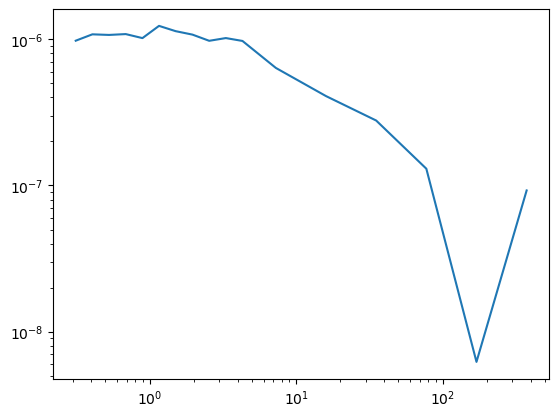

In [28]:
a=np.loadtxt('./GC_analysis/GCE_model_I.dat')
plt.loglog(a[0:, 0], a[0:, 1])

In [ ]:
# Log-transform the x (Energy) and y (E^2dN/dE) values
#clean_data = input data
log_energy = np.log10(clean_data['Energy_GeV'])
log_E2dN_dE = np.log10(clean_data['E2dN_dE_GeV_cm2s1sr1'])

# Define the interpolation function in log-log space
interp_func_log = interp1d(log_energy, log_E2dN_dE, kind='slinear', fill_value="extrapolate")

# Generate new log-scale Energy values for extrapolation (log-scale)
log_energy_extended = np.linspace(log_energy.min(), np.log10(370), 500)


# Interpolate/extrapolate in log-log space
log_E2dN_dE_extended = interp_func_log(log_energy_extended)

# Convert back to linear scale
energy_extended = 10**log_energy_extended
E2dN_dE_extended = 10**log_E2dN_dE_extended

# Plot the original data points and the extrapolated curve (log-log)
plt.figure(figsize=(8, 6))

# Plot in log-log scale
plt.plot(energy_extended, E2dN_dE_extended, label='Extrapolated E^2dN/dE (Log-Log Scale)', color='red', linestyle='--')
plt.errorbar(clean_data['Energy_GeV'], clean_data['E2dN_dE_GeV_cm2s1sr1'], 
             yerr=[clean_data['E2dN_dE_GeV_cm2s1sr1'] - clean_data['sigma_lower'], 
                   clean_data['sigma_upper'] - clean_data['E2dN_dE_GeV_cm2s1sr1']], 
             fmt='o', label='Original Data', capsize=3)

# Set the scale to logarithmic for both axes
plt.xscale('log')
plt.yscale('log')

# Set labels and title
plt.xlabel('Energy (GeV)')
plt.ylabel(r'$E^2 \cdot dN/dE$ (GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$)')
plt.title('Extrapolated Data using Log-Log Scale')
plt.grid(True, which="both", ls="—")
plt.legend()

# Show the plot
plt.show()

## Redandency

In [12]:
"""
model='A'
component='psc'
gtmodel = GtApp('gtmodel', 'Likelihood')
gtmodel['irfs']='P8R3_CLEAN_V3'
gtmodel['outtype']='ccube'
gtmodel['srcmdl']=f'./GC_analysis/Model/GC_{component}_model.xml'
gtmodel['outfile']=f'./GC_analysis/Model/GC_all_time_60x60_{component}_model.fits'
gtmodel['expcube']='./GC_analysis/Allsky_all_time_ltcube.fits'
gtmodel['bexpmap']='./GC_analysis/Allsky_all_time_60x60_expcube.fits'
gtmodel['srcmaps']=f'./GC_analysis/GC_all_time_60x60_srcmap_model{model}_merged.fits'
gtmodel.run()
"""

"\nmodel='A'\ncomponent='psc'\ngtmodel = GtApp('gtmodel', 'Likelihood')\ngtmodel['irfs']='P8R3_CLEAN_V3'\ngtmodel['outtype']='ccube'\ngtmodel['srcmdl']=f'./GC_analysis/Model/GC_{component}_model.xml'\ngtmodel['outfile']=f'./GC_analysis/Model/GC_all_time_60x60_{component}_model.fits'\ngtmodel['expcube']='./GC_analysis/Allsky_all_time_ltcube.fits'\ngtmodel['bexpmap']='./GC_analysis/Allsky_all_time_60x60_expcube.fits'\ngtmodel['srcmaps']=f'./GC_analysis/GC_all_time_60x60_srcmap_model{model}_merged.fits'\ngtmodel.run()\n"

In [24]:
# Revision :: Aug 11, 2024


model='A'
E_bounds=fits.open('./GC_analysis/GC_all_time_60x60_ccube.fits')[1].data

sr=0.214411*2
E=np.zeros(len(E_bounds))
for i in range(0, len(E_bounds), 1):
    E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)*1e-3

delta_E=np.zeros(len(E_bounds))
for i in range(0, len(E_bounds), 1):
    delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-6

exp_cube = np.zeros([len(E), 400, 400])
#exp_cube=np.sqrt(fits.open('./GC_analysis/GC_all_time_60x60_expcube.fits')[0].data[:-1]*fits.open('./GC_analysis/GC_all_time_60x60_expcube.fits')[0].data[1:])
for i in range(0, len(exp_cube), 1):
    exp_cube[i] = (np.sqrt(fits.open('./GC_analysis/GC_all_time_60x60_expcube.fits')[0].data[i, 100:500, 100:500]*fits.open('./GC_analysis/GC_all_time_60x60_expcube.fits')[0].data[i+1, 100:500, 100:500]))   



file_name='./GC_analysis/Model/GC_all_time_60x60_psc_model.fits'
psc=np.zeros(len(fits.open(file_name)[0].data))
for i in range(0, len(fits.open(file_name)[0].data), 1):
    a=exp_cube[i]
    psc[i] = np.sum((fits.open(file_name)[0].data[i][100:500, 100:500]/a))

file_name=f'./GC_analysis/Model/GC_all_time_60x60_pion_model{model}.fits'
pion=np.zeros(len(fits.open(file_name)[0].data))
for i in range(0, len(fits.open(file_name)[0].data), 1):
    a=exp_cube[i]
    pion[i] = np.sum( (fits.open(file_name)[0].data[i][100:500, 100:500]/a) )

file_name=f'./GC_analysis/Model/GC_all_time_60x60_bremss_model{model}.fits'
bremss=np.zeros(len(fits.open(file_name)[0].data))
for i in range(0, len(fits.open(file_name)[0].data), 1):
    a=exp_cube[i]
    bremss[i] = np.sum( (fits.open(file_name)[0].data[i][100:500, 100:500]/a) )
    
file_name=f'./GC_analysis/Model/GC_all_time_60x60_ics_model{model}.fits'
ics=np.zeros(len(fits.open(file_name)[0].data))
for i in range(0, len(fits.open(file_name)[0].data), 1):
    a=exp_cube[i]
    ics[i] = np.sum( (fits.open(file_name)[0].data[i][100:500, 100:500]/a) )
    
file_name=f'./GC_analysis/Model/GC_all_time_60x60_GCE_model.fits'
GCE=np.zeros(len(fits.open(file_name)[0].data))
for i in range(0, len(fits.open(file_name)[0].data), 1):
    a=exp_cube[i]
    GCE[i] = np.sum( (fits.open(file_name)[0].data[i][100:500, 100:500]/a) )
    
file_name=f'./GC_analysis/Model/GC_all_time_60x60_fermi_bubble_model.fits'
bubble=np.zeros(len(fits.open(file_name)[0].data))
for i in range(0, len(fits.open(file_name)[0].data), 1):
    a=exp_cube[i]
    bubble[i] = np.sum( (fits.open(file_name)[0].data[i][100:500, 100:500]/a) )
    
file_name=f'./GC_analysis/Model/GC_all_time_60x60_isotropic_model.fits'
isotropic=np.zeros(len(fits.open(file_name)[0].data))
for i in range(0, len(fits.open(file_name)[0].data), 1):
    a=exp_cube[i]
    isotropic[i] = np.sum( (fits.open(file_name)[0].data[i][100:500, 100:500]/a) )
    
counts_per_exp=np.zeros(len(E))
i=0
for i in range(0, len(E), 1):
    a=exp_cube[i]
    counts_per_exp[i]=np.sum( ( (fits.open('./GC_analysis/GC_all_time_60x60_ccube.fits')[0].data[i][100:500, 100:500]) /a) )

counts_per_exp_err=np.zeros(len(E))
i=0
for i in range(0, len(E), 1):
    a=exp_cube[i]
    counts_per_exp_err[i]=np.sqrt( np.sum( ( (fits.open('./GC_analysis/GC_all_time_60x60_ccube.fits')[0].data[i][100:500, 100:500]) /a)**2) )
    
    
    

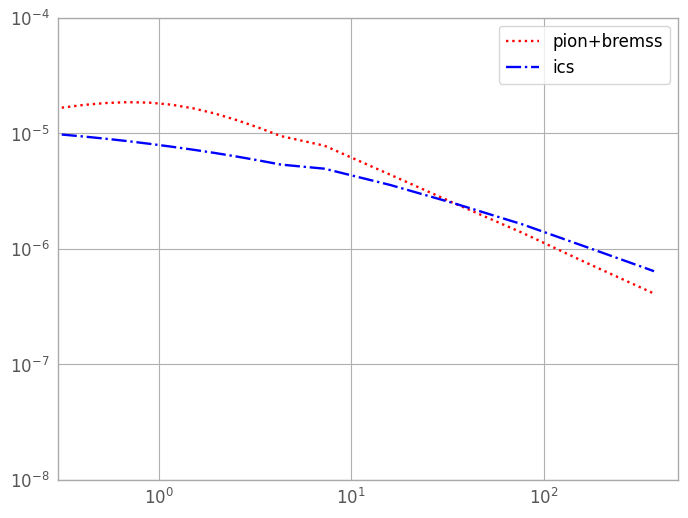

In [25]:
plt.ylim(1e-8, 1e-4)
plt.xlim(0.3, 500)
plt.style.use(astropy_mpl_style)
plt.loglog()
plt.plot(E, (pion+bremss)*(E**2)/(delta_E*sr), linestyle='dotted', label='pion+bremss', color='red')
plt.plot(E, (ics)*(E**2)/(delta_E*sr), linestyle='dashdot', label='ics', color='blue')
#plt.plot(E, (pion+bremss)*(E**2)/(delta_E*sr), 'ro', label='pion+bremss', color='red')
#plt.plot(E, (ics)*(E**2)/(delta_E*sr), 'bo', label='ics', color='blue')
plt.legend()

In [74]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from scipy.interpolate import interp1d
from iminuit import Minuit
#Constraints interpolated function
#Contains constraints for bubble and isotropic as well
#For isotropic, from https://arxiv.org/pdf/1410.3696.pdf Table 3

#Testing exposure per pixel

#Analysis for model F
#Correcting bubble template given from https://arxiv.org/pdf/1407.7905, Table 2


constraints=np.loadtxt('./GC_analysis/Model/bubble_constraints.txt')
constraints_energy=constraints[0:, 0]
constraints_flux=constraints[0:, 1]#/constraints[0:, 0]**2
constraints_lower_error=constraints[0:, 2]#/constraints[0:, 0]**2
constraints_upper_error=constraints[0:, 3]#/constraints[0:, 0]**2

fluxint=interp1d(constraints_energy, constraints_flux, fill_value="extrapolate", kind='quadratic')
upper_errint=interp1d(constraints_energy, constraints_upper_error, fill_value="extrapolate", kind='quadratic') 
lower_errint=interp1d(constraints_energy, constraints_lower_error, fill_value="extrapolate", kind='quadratic') 


bubble_flux_data=fluxint(E)
bubble_lower_error_data=lower_errint(E)
bubble_upper_error_data=upper_errint(E)


iso_constraints=np.loadtxt('./GC_analysis/Model/egb_constraints_full_err.txt')
iso_constraints_energy=iso_constraints[0:, 0]
iso_constraints_flux=iso_constraints[0:, 1]
iso_constraints_low_err=iso_constraints[0:, 2]
iso_constraints_upp_err=iso_constraints[0:, 3]


fluxint=interp1d(iso_constraints_energy, iso_constraints_flux, fill_value="extrapolate")#, kind='quadratic')
low_errint=interp1d(iso_constraints_energy, iso_constraints_low_err, fill_value="extrapolate")#, kind='quadratic')    
upp_errint=interp1d(iso_constraints_energy, iso_constraints_upp_err, fill_value="extrapolate")#, kind='quadratic')    

iso_constraints_flux=((E)**2)*fluxint(E)
iso_constraints_flux_low_err=((E)**2)*low_errint(E)
iso_constraints_flux_upp_err=((E)**2)*upp_errint(E)



class Likelihood:
    def __init__(self, model, energy_bin):
        self.model=model
        self.energy_bin=energy_bin
    def likelihood_constrained(self, parameter_set):
        data=fits.open('./GC_analysis/GC_all_time_60x60_ccube.fits')
        psc_map=fits.open('./GC_analysis/Model/GC_all_time_60x60_psc_model.fits')
        pion=fits.open(f'./GC_analysis/Model/GC_all_time_60x60_pion_model{self.model}.fits')
        ics=fits.open(f'./GC_analysis/Model/GC_all_time_60x60_ics_model{self.model}.fits')
        bremss=fits.open(f'./GC_analysis/Model/GC_all_time_60x60_bremss_model{self.model}.fits')
        GCE=fits.open(f'./GC_analysis/Model/GC_all_time_60x60_GCE_model.fits')
        bubble=fits.open(f'./GC_analysis/Model/GC_all_time_60x60_fermi_bubble_model.fits')
        isotropic=fits.open(f'./GC_analysis/Model/GC_all_time_60x60_isotropic_model.fits')
        #####################################
        pion_bremss_param=parameter_set[0]
        ics_param=parameter_set[1]
        GCE_param=parameter_set[2]
        bubble_param=parameter_set[3]
        isotropic_param=parameter_set[4]
 
        ######################################
        #Main body for calculating Poissonian log-likelihood
        #for k in range(0, energy_length, 1):
        observed_pixel=data[0].data[self.energy_bin]
        observed_pixel=observed_pixel.astype('float32')
        psc_pixel=psc_map[0].data[self.energy_bin]
        pion_bremss_pixel=pion[0].data[self.energy_bin] + bremss[0].data[self.energy_bin]
        ics_pixel=ics[0].data[self.energy_bin]
        GCE_pixel=GCE[0].data[self.energy_bin]
        iso_pixel=isotropic[0].data[self.energy_bin]
        bubble_pixel=bubble[0].data[self.energy_bin]
        #expected_pixel= pion_bremss_param*pion_bremss_pixel + ics_param*ics_pixel + psc_pixel + GCE_param*GCE_pixel + isotropic_param*iso_pixel + bubble_param*bubble_pixel
        expected_pixel= (1+pion_bremss_param)*pion_bremss_pixel + (1+ics_param)*ics_pixel + (1+GCE_param)*GCE_pixel + (1+isotropic_param)*iso_pixel + (1+bubble_param)*bubble_pixel
        
        if ( (expected_pixel) < 0.0 ).any():
            return np.inf
        
        psc_mask=np.load('./GC_analysis/Model/GC_mask_60x60_definitions.npy')[self.energy_bin]
        disk_mask=np.load('./GC_analysis/Model/GC_disk_mask_60x60_definitions.npy')
        
        full_mask=(psc_mask*disk_mask)[100:500, 100:500]
        
        indices=np.where(full_mask==0.0)

        observed_pixel = (observed_pixel)[100:500, 100:500]
        expected_pixel = (expected_pixel)[100:500, 100:500]
        
        E_bounds=fits.open('./GC_analysis/GC_all_time_60x60_ccube.fits')[1].data

        E=np.zeros(len(E_bounds))
        for i in range(0, len(E_bounds), 1):
            E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)*1e-3

        delta_E=np.zeros(len(E_bounds))
        for i in range(0, len(E_bounds), 1):
            delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-6

        exp_cube = np.zeros([len(E), 400, 400])
        for i in range(0, len(exp_cube), 1):
            exp_cube[i] = (np.sqrt(fits.open('./GC_analysis/GC_all_time_60x60_expcube.fits')[0].data[i, 100:500, 100:500]*fits.open('./GC_analysis/GC_all_time_60x60_expcube.fits')[0].data[i+1, 100:500, 100:500]))   

        observed_pixel = np.delete(observed_pixel, indices)
        expected_pixel = np.delete(expected_pixel, indices)
        
        #observed_pixel[observed_pixel == 0.0] += 1e-20
        expected_pixel[expected_pixel == 0.0] += 1e-20
        lhd=2*( expected_pixel - observed_pixel*np.log(expected_pixel) )# + term )#np.log(factorial(observed_pixel)))
       
        #zeros=1e-20*np.ones(np.shape(expected_pixel))
        
        #base_value=2*( zeros - observed_pixel*np.log(zeros) )

        E_bounds=fits.open('./GC_analysis/GC_all_time_60x60_ccube.fits')[1].data

        sr=0.214411*2

        exp_cube = np.zeros([len(E), 600, 600])
        for i in range(0, len(exp_cube), 1):
            exp_cube[i] = (np.sqrt(fits.open('./GC_analysis/GC_all_time_60x60_expcube.fits')[0].data[i]*fits.open('./GC_analysis/GC_all_time_60x60_expcube.fits')[0].data[i+1]))   


        
        file_name='./GC_analysis/Model/GC_all_time_60x60_isotropic_model.fits'
        isotropic=np.zeros(len(fits.open(file_name)[0].data))
        for i in range(0, len(fits.open(file_name)[0].data), 1):
            a=exp_cube[i]
            isotropic[i] = np.sum( (fits.open(file_name)[0].data[i]/a) )#*isotropic_param
            
        isotropic[self.energy_bin] *= (1+isotropic_param)

        file_name='./GC_analysis/Model/GC_all_time_60x60_fermi_bubble_model.fits'
        bubble=np.zeros(len(fits.open(file_name)[0].data))
        for i in range(0, len(fits.open(file_name)[0].data), 1):
            a=exp_cube[i]
            bubble[i] = np.sum( fits.open(file_name)[0].data[i]/a )#*bubble_param
            
        bubble[self.energy_bin] *= (1+bubble_param)

        sr_60=1.0471975511965974#0.9773843811168244

        
        bubble_sed=(E**2)*bubble/(delta_E*sr_60)

        
      
        chi2=0
        i=self.energy_bin
        larger_error=max([bubble_upper_error_data[i], bubble_lower_error_data[i]])
        if bubble_flux_data[i] < bubble_sed[i]:
            chi2 = ((bubble_sed[i] - bubble_flux_data[i])/bubble_upper_error_data[i])**2
        if bubble_flux_data[i] > bubble_sed[i]:
            chi2 = ((bubble_sed[i] - bubble_flux_data[i])/bubble_lower_error_data[i])**2
        if bubble_flux_data[i] == bubble_sed[i]:
            chi2 = ((bubble_sed[i] - bubble_flux_data[i])/larger_error)**2

        iso_flux=(E**2)*isotropic/(sr_60*delta_E)

        chi2_iso=0
        i=self.energy_bin
        iso_larger_error=max([iso_constraints_flux_low_err[i], iso_constraints_flux_upp_err[i]])
        if iso_flux[i] > iso_constraints_flux[i]:
            chi2_iso = ((iso_constraints_flux[i] - iso_flux[i])/iso_constraints_flux_upp_err[i])**2
        if iso_flux[i] < iso_constraints_flux[i]:
            chi2_iso = ((iso_constraints_flux[i] - iso_flux[i])/iso_constraints_flux_low_err[i])**2
        if iso_flux[i] == iso_constraints_flux[i]:
            chi2_iso = ((iso_constraints_flux[i] - iso_flux[i])/iso_larger_error[i])**2
        
        #return (np.sum(lhd) - np.sum(base_value)) + chi2 + chi2_iso
        return np.sum(lhd) + chi2 + chi2_iso
    
    def minuit_module(self):
        tol=1e-4
        tol1=tol
        #m=Minuit(self.likelihood_constrained, 0*np.ones(5))
        #m.errordef=0.5
        while True:
            if True:
                m=Minuit(self.likelihood_constrained, 0.0*np.ones(5))#np.random.rand(5))
                m.errordef=0.5
                m.limits[:]=(-5, 5)
                m.limits[2]=(-5, 5)
                m.tol=tol1
                print(f'tol1 = {m.tol}')
                m.strategy=0
                m.simplex()
                m.strategy=1
                m.simplex()
                m.strategy=2
                m.simplex()
                #m.migrad()#.migrad()
                if m.valid==True:
                    print(m)
                    break;
                else:
                    tol1*=1e+1
        return 1+np.array(m.values[:]), 1+np.array(m.errors[:])
class Parameter_estimation():
    def __init__(self, model):
        self.model=model
    def minuit_run(self):
        pion_bremss_fitted=list(np.ones(17))
        ics_fitted=list(np.ones(17))
        GCE_fitted=list(np.ones(17))
        bubble_fitted=list(np.ones(17))
        isotropic_fitted=list(np.ones(17))
        
        pion_bremss_fitted_errors=list(np.zeros(17))
        ics_fitted_errors=list(np.zeros(17))
        GCE_fitted_errors=list(np.zeros(17))
        bubble_fitted_errors=list(np.zeros(17))
        isotropic_fitted_errors=list(np.zeros(17))   

        for i in range(0, 17, 1):
        #for i in range(0, 14, 1):
            results=Likelihood(self.model, i).minuit_module()
            #results=np.ones([5, 5])
            pion_bremss_fitted[i] = (results[0][0])
            ics_fitted[i] = (results[0][1])
            GCE_fitted[i] = (results[0][2])
            bubble_fitted[i] = (results[0][3])
            isotropic_fitted[i] = (results[0][4])
            
            pion_bremss_fitted_errors[i] = (results[1][0])
            ics_fitted_errors[i] = (results[1][1])
            GCE_fitted_errors[i] = (results[1][2])
            bubble_fitted_errors[i] = (results[1][3])
            isotropic_fitted_errors[i] = (results[1][4])
            
            fitted=np.hstack([pion_bremss_fitted, ics_fitted, GCE_fitted, bubble_fitted, isotropic_fitted])
            fitted_errors=np.zeros(17*5)
            data = np.loadtxt('/home/sanghwan/C.Weniger/covariance.dat')
            ebins = data[:,0:2]  # Energy bins [GeV]
            emeans = ebins.prod(axis=1)**0.5  # Geometric mean energy [GeV]
            de = ebins[:,1] - ebins[:,0]  # Energy bin width [GeV]
            flux = data[:,2]  # (Average flux)*E^2 in energy bin [GeV/cm2/s/sr]
            flux_err = data[:,3]  # Flux error [GeV/cm2/s/sr]

        
            plt.figure()
            print(i)
            ax=plt.subplot()

            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel('E [GeV]')
            ax.set_ylabel(r'$E^2 \frac{dN}{dE}$[GeV$cm^{-2}$$s^{-1} sr^{-1}$]')

            ax.set_ylim(1e-8, 1e-4)
            ax.set_xlim(0.3, 500)

            ax.tick_params(axis='y', which='both', direction='in', left=True)
            ax.tick_params(axis='x', which='both', direction='in', bottom=True)
            ax.minorticks_on()
            ax.grid(True, which='Major', linestyle='-', linewidth=0.5)

            sr=0.214411*2
            ax.errorbar(emeans, flux, flux_err)
            ax.errorbar(E, counts_per_exp*(E**2)/(delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')


            ax.errorbar(E, psc*(E**2)/(delta_E*sr), linestyle='', marker='.', elinewidth=2, capsize=4, capthick=2, label='psc', color='orange')


            ax.errorbar(E, fitted[0:17]*(pion+bremss)*(E**2)/(delta_E*sr), yerr=fitted_errors[0:17]*(pion+bremss)*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='pion+bremss', color='red')
            ax.errorbar(E, fitted[17:34]*(ics)*(E**2)/(delta_E*sr), yerr=fitted_errors[17:34]*(ics)*(E**2)/(delta_E*sr), linestyle='dashdot', marker='.', elinewidth=2, capsize=4, capthick=2, label='ics', color='blue')

            ax.plot(E, (pion+bremss)*(E**2)/(delta_E*sr), linestyle='dotted', label='pion+bremss', color='red')
            ax.plot(E, (ics)*(E**2)/(delta_E*sr), linestyle='dashdot', label='ics', color='blue')



            ax.errorbar(E,  fitted[34:51]*(GCE)*(E**2)/(delta_E*sr), yerr=np.sqrt((fitted_errors[34:51]*GCE)**2)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')



            ax.errorbar(E, fitted[51:68]*(bubble)*(E**2)/(delta_E*sr),yerr=fitted_errors[51:68]*(bubble)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='bubble', color='purple')

            ax.errorbar(E, fitted[68:85]*(isotropic)*(E**2)/(delta_E*sr),yerr=fitted_errors[68:85]*(isotropic)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='isotropic', color='green')

            plt.show()
            
        
 
        
        return np.hstack([pion_bremss_fitted, ics_fitted, GCE_fitted, bubble_fitted, isotropic_fitted]), np.hstack([pion_bremss_fitted_errors, ics_fitted_errors, GCE_fitted_errors, bubble_fitted_errors, isotropic_fitted_errors])


In [78]:
Likelihood('A', 0).likelihood_constrained(-5*np.ones(5))

inf

tol1 = 0.0001
tol1 = 0.001
tol1 = 0.01
tol1 = 0.1
tol1 = 1.0
tol1 = 10.0
┌─────────────────────────────────────────────────────────────────────────┐
│                               Simplex                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.115e+07                 │              Nfcn = 210              │
│ EDM = 1.09 (Goal: 5)             │           time = 39.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Hesse not run           │            NO covariance             │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───

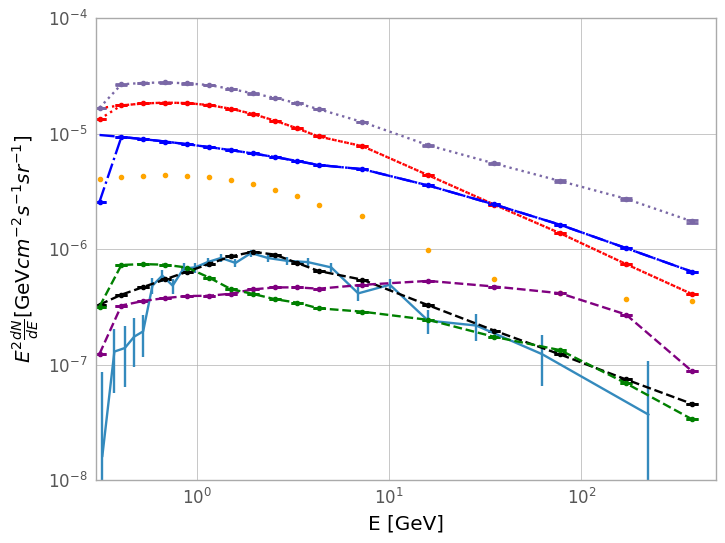

tol1 = 0.0001
tol1 = 0.001
tol1 = 0.01
tol1 = 0.1
tol1 = 1.0
tol1 = 10.0
tol1 = 100.0
┌─────────────────────────────────────────────────────────────────────────┐
│                               Simplex                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.773e+07                 │              Nfcn = 88               │
│ EDM = 2 (Goal: 50)               │           time = 16.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Hesse not run           │            NO covariance             │
└──────────────────────────────────┴──────────────────────────────────────┘
┌─

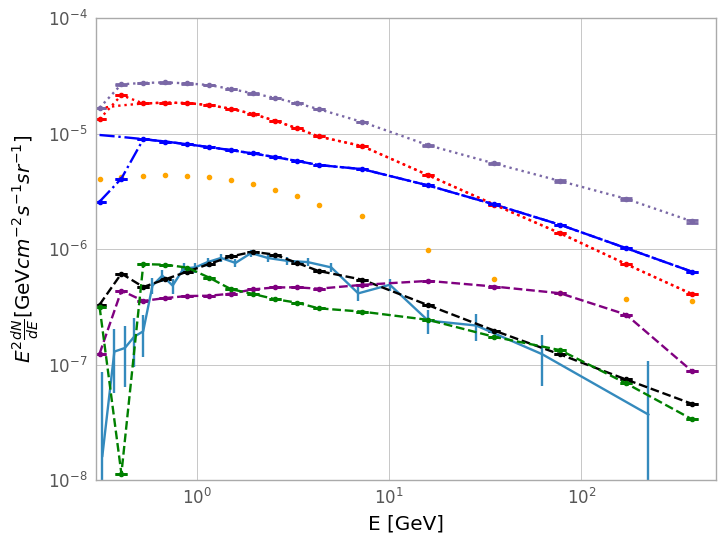

tol1 = 0.0001
tol1 = 0.001
tol1 = 0.01
tol1 = 0.1
tol1 = 1.0
tol1 = 10.0
┌─────────────────────────────────────────────────────────────────────────┐
│                               Simplex                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.471e+07                 │              Nfcn = 516              │
│ EDM = 3.87 (Goal: 5)             │           time = 10.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Hesse not run           │            NO covariance             │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───

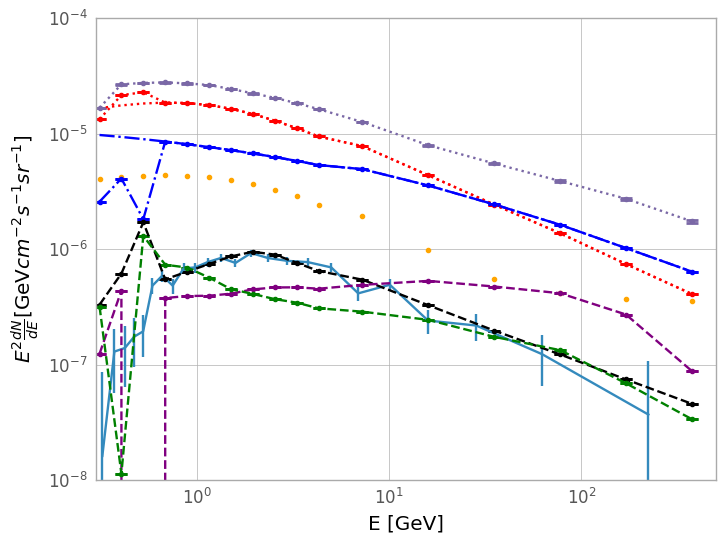

tol1 = 0.0001
tol1 = 0.001
tol1 = 0.01
tol1 = 0.1
tol1 = 1.0
tol1 = 10.0
┌─────────────────────────────────────────────────────────────────────────┐
│                               Simplex                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.158e+07                 │              Nfcn = 278              │
│ EDM = 3.02 (Goal: 5)             │           time = 23.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Hesse not run           │            NO covariance             │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───

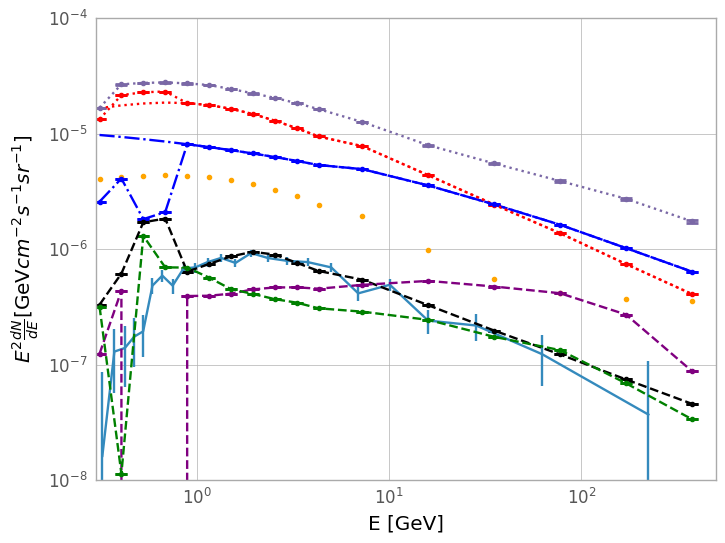

tol1 = 0.0001
tol1 = 0.001
tol1 = 0.01
tol1 = 0.1
tol1 = 1.0
tol1 = 10.0
┌─────────────────────────────────────────────────────────────────────────┐
│                               Simplex                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -8.669e+06                 │              Nfcn = 198              │
│ EDM = 3.19 (Goal: 5)             │           time = 25.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Hesse not run           │            NO covariance             │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───

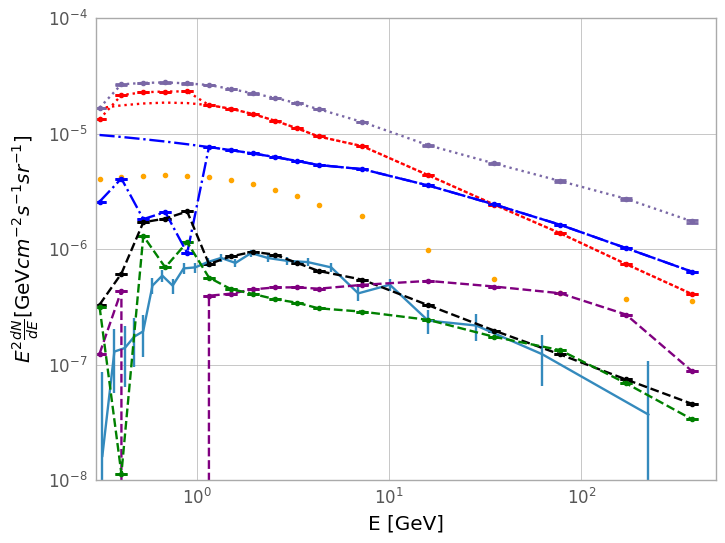

tol1 = 0.0001
tol1 = 0.001
tol1 = 0.01
tol1 = 0.1
tol1 = 1.0
tol1 = 10.0
┌─────────────────────────────────────────────────────────────────────────┐
│                               Simplex                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -6.038e+06                 │              Nfcn = 364              │
│ EDM = 4.29 (Goal: 5)             │           time = 48.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Hesse not run           │            NO covariance             │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───

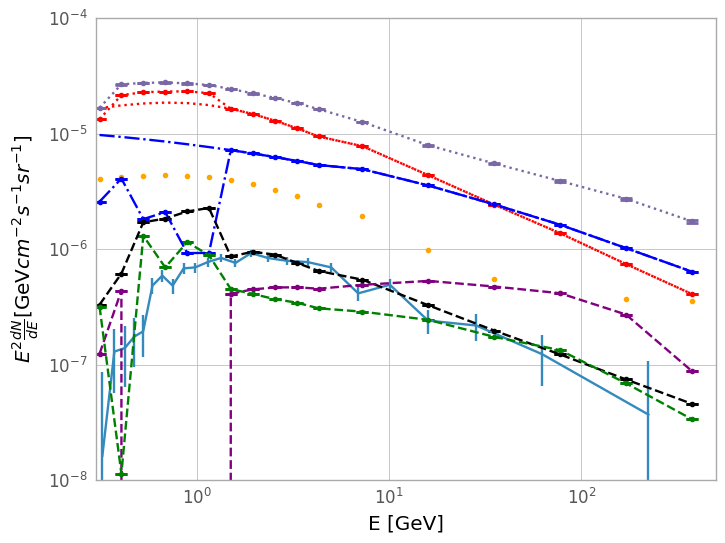

tol1 = 0.0001
tol1 = 0.001
tol1 = 0.01
tol1 = 0.1
tol1 = 1.0
tol1 = 10.0
┌─────────────────────────────────────────────────────────────────────────┐
│                               Simplex                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -4.025e+06                 │              Nfcn = 214              │
│ EDM = 1.75 (Goal: 5)             │           time = 48.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Hesse not run           │            NO covariance             │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───

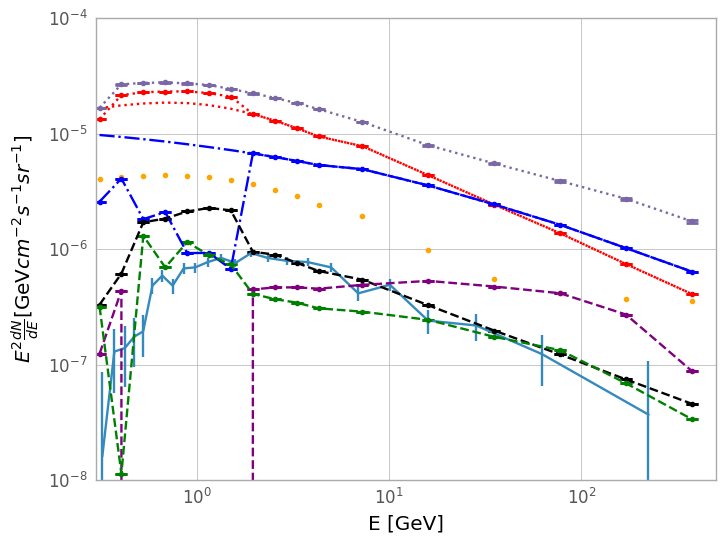

tol1 = 0.0001
tol1 = 0.001
tol1 = 0.01
tol1 = 0.1
tol1 = 1.0
┌─────────────────────────────────────────────────────────────────────────┐
│                               Simplex                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -2.342e+06                 │              Nfcn = 338              │
│ EDM = 0.24 (Goal: 0.5)           │           time = 32.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Hesse not run           │            NO covariance             │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───

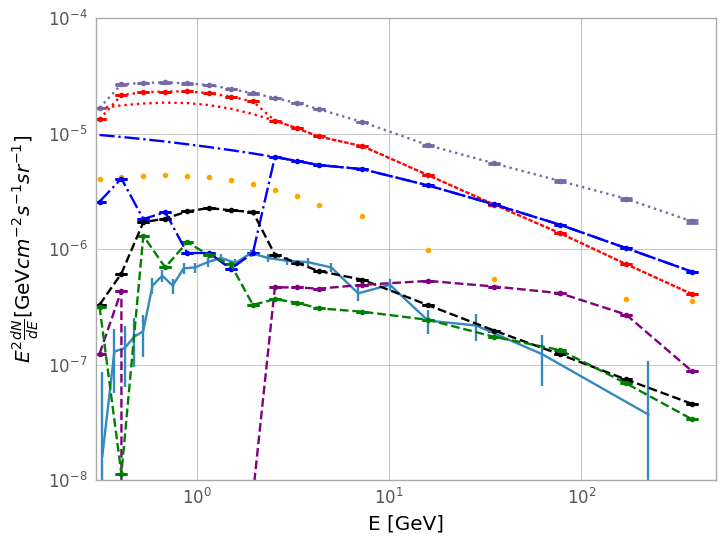

tol1 = 0.0001
tol1 = 0.001
tol1 = 0.01
tol1 = 0.1
tol1 = 1.0
┌─────────────────────────────────────────────────────────────────────────┐
│                               Simplex                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.211e+06                 │              Nfcn = 204              │
│ EDM = 0.137 (Goal: 0.5)          │           time = 30.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Hesse not run           │            NO covariance             │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───

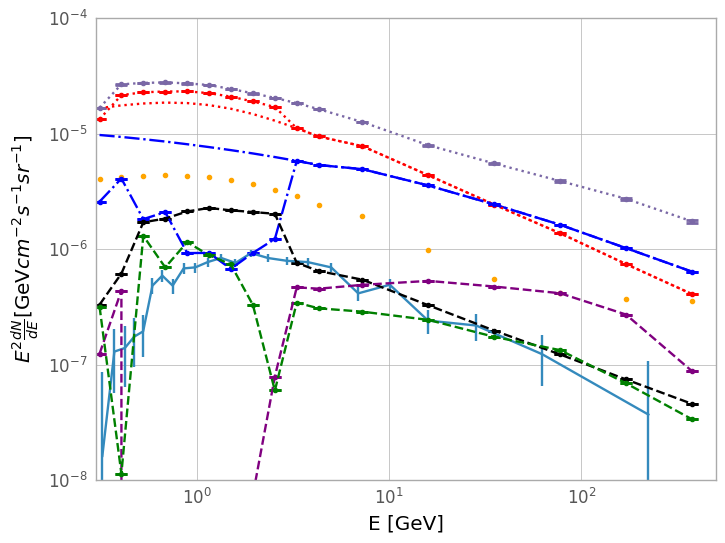

tol1 = 0.0001
tol1 = 0.001
tol1 = 0.01
tol1 = 0.1
tol1 = 1.0
┌─────────────────────────────────────────────────────────────────────────┐
│                               Simplex                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -5.187e+05                 │              Nfcn = 243              │
│ EDM = 0.23 (Goal: 0.5)           │           time = 15.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Hesse not run           │            NO covariance             │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───

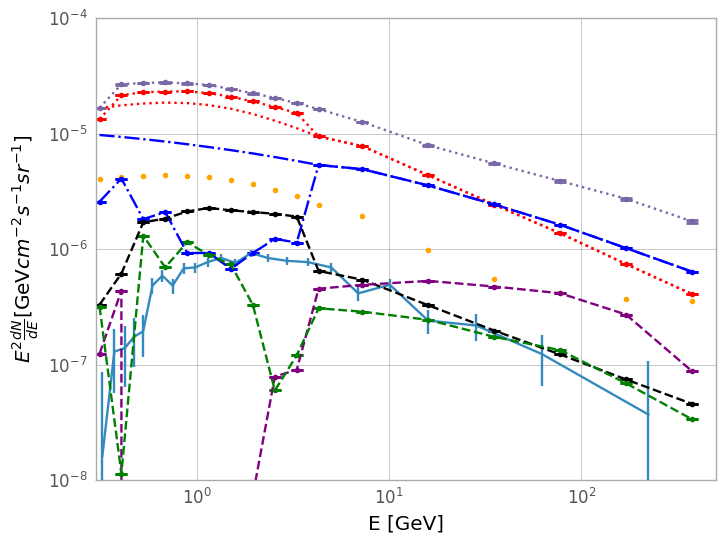

tol1 = 0.0001
tol1 = 0.001
tol1 = 0.01
tol1 = 0.1
┌─────────────────────────────────────────────────────────────────────────┐
│                               Simplex                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.209e+05                 │              Nfcn = 382              │
│ EDM = 0.0396 (Goal: 0.05)        │           time = 69.4 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Hesse not run           │            NO covariance             │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬──

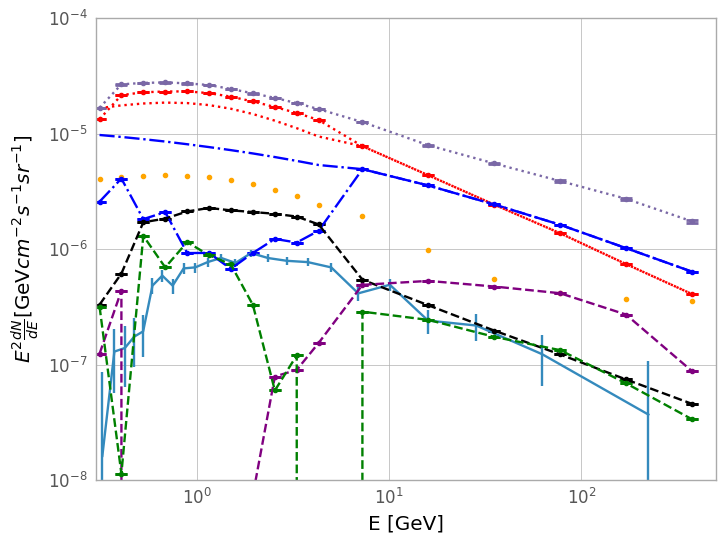

tol1 = 0.0001
tol1 = 0.001
tol1 = 0.01
tol1 = 0.1
tol1 = 1.0
┌─────────────────────────────────────────────────────────────────────────┐
│                               Simplex                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -3.796e+05                 │              Nfcn = 278              │
│ EDM = 0.382 (Goal: 0.5)          │           time = 38.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Hesse not run           │            NO covariance             │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───

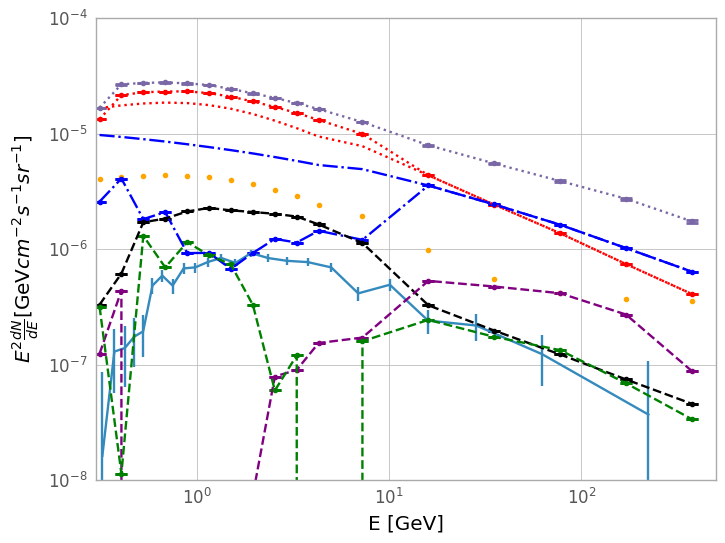

tol1 = 0.0001
tol1 = 0.001


In [ ]:
%%time

import time
start_time = time.time()

params, param_errors=Parameter_estimation('A').minuit_run()

end_time = time.time()
execution_time = end_time - start_time
print(execution_time)

In [73]:
params

array([ 1.00000477,  1.00000561,  1.00020349,  1.00372675,  1.0004912 ,
        1.01171788,  1.00030714,  1.00372945,  1.02883994,  1.05168748,
        1.08283366,  1.00000879,  1.00000065,  1.14391566,  1.549474  ,
        2.28896764,  2.77507329,  1.00000038,  1.0000028 ,  1.00000579,
        1.00000291,  1.000004  ,  1.00000591,  1.00000398,  1.00000175,
        1.00000169,  1.00001141,  1.00000267,  1.00000019,  1.00000026,
        1.00000894,  1.00000019,  1.00000092,  1.00006226, -3.99999481,
       -0.57494081,  0.16379872,  0.50725471,  0.71481251,  0.83674555,
        0.75159211,  0.69568666,  0.77137667,  0.92058908,  0.9240153 ,
        0.21707942, -0.11909438, -0.06489068, -0.91288832, -1.75942522,
       -1.73504962,  1.00000298,  1.00001141,  1.00001451,  1.00012982,
        1.0000976 ,  1.00003468,  1.00002356,  1.00004386,  1.00002282,
        1.00001695,  1.00000076,  1.0000219 ,  1.00000396,  1.00000447,
        1.00000394,  1.00000006,  1.00000332,  1.00000932,  1.00

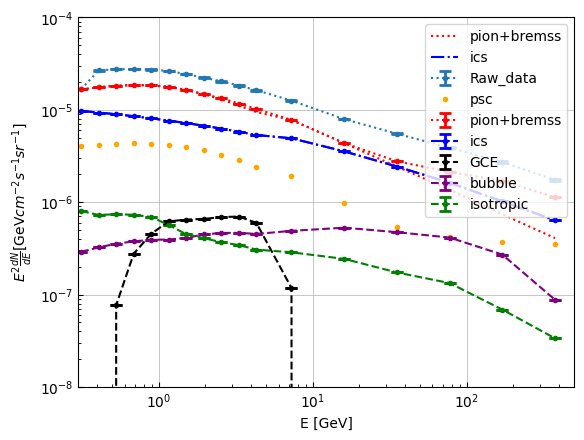

In [71]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
plt.style.use('default')
ax=plt.subplot()

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('E [GeV]')
ax.set_ylabel(r'$E^2 \frac{dN}{dE}$[GeV$cm^{-2}$$s^{-1} sr^{-1}$]')

ax.set_ylim(1e-8, 1e-4)
ax.set_xlim(0.3, 500)

ax.tick_params(axis='y', which='both', direction='in', left=True)
ax.tick_params(axis='x', which='both', direction='in', bottom=True)
ax.minorticks_on()
ax.grid(True, which='Major', linestyle='-', linewidth=0.5)

#m=minuit4
#fitted=params
#fitted_errors=param_errors

fitted_errors=param_errors
fitted=params
#fitted=np.ones(17*5)
fitted_errors=np.zeros(17*5)
sr=0.214411*2

ax.errorbar(E, counts_per_exp*(E**2)/(delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')


ax.errorbar(E, psc*(E**2)/(delta_E*sr), linestyle='', marker='.', elinewidth=2, capsize=4, capthick=2, label='psc', color='orange')


ax.errorbar(E, fitted[0:17]*(pion+bremss)*(E**2)/(delta_E*sr), yerr=fitted_errors[0:17]*(pion+bremss)*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='pion+bremss', color='red')
ax.errorbar(E, fitted[17:34]*(ics)*(E**2)/(delta_E*sr), yerr=fitted_errors[17:34]*(ics)*(E**2)/(delta_E*sr), linestyle='dashdot', marker='.', elinewidth=2, capsize=4, capthick=2, label='ics', color='blue')

ax.plot(E, (pion+bremss)*(E**2)/(delta_E*sr), linestyle='dotted', label='pion+bremss', color='red')
ax.plot(E, (ics)*(E**2)/(delta_E*sr), linestyle='dashdot', label='ics', color='blue')



ax.errorbar(E,  fitted[34:51]*(GCE)*(E**2)/(delta_E*sr), yerr=np.sqrt((fitted_errors[34:51]*GCE)**2)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')



ax.errorbar(E, fitted[51:68]*(bubble)*(E**2)/(delta_E*sr),yerr=fitted_errors[51:68]*(bubble)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='bubble', color='purple')

ax.errorbar(E, fitted[68:85]*(isotropic)*(E**2)/(delta_E*sr),yerr=fitted_errors[68:85]*(isotropic)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='isotropic', color='green')

ax.legend()

<ErrorbarContainer object of 3 artists>

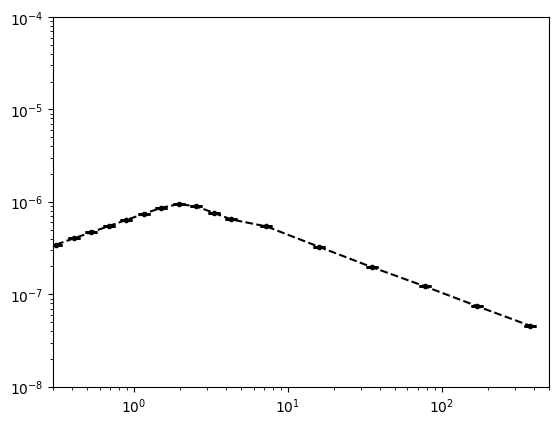

In [34]:
plt.ylim(1e-8, 1e-4)
plt.xlim(0.3, 500)
plt.loglog()
plt.errorbar(E,  fitted[34:51]*(GCE)*(E**2)/(delta_E*sr), yerr=np.sqrt((fitted_errors[34:51]*GCE)**2)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')


In [62]:
np.savetxt('/home/FermiLAT/Sanghwan/GCE_model_F_p_p_p.dat', np.vstack([E*1e-3, fitted[48:72]*(GCE)*(E**2)/(1000*delta_E*sr), counts_per_exp_err*(E**2)/(1000*delta_E*sr)]).T)

In [60]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from scipy.interpolate import interp1d
from iminuit import Minuit
#Constraints interpolated function
#Contains constraints for bubble and isotropic as well
#For isotropic, from https://arxiv.org/pdf/1410.3696.pdf Table 3

#Testing exposure per pixel

#Analysis for model F
#Correcting bubble template given from https://arxiv.org/pdf/1407.7905, Table 2

class Likelihood:
    def __init__(self, model, energy_bin):
        self.model=model
        self.energy_bin=energy_bin
    def likelihood_constrained(self, parameter_set):
        data=fits.open('./GC_analysis/GC_all_time_ccube_masked.fits')
        psc_map=fits.open('./GC_analysis/Model/GC_all_time_psc_model.fits')
        pion=fits.open(f'./GC_analysis/Model/GC_all_time_pion_model{self.model}.fits')
        ics=fits.open(f'./GC_analysis/Model/GC_all_time_ics_model{self.model}.fits')
        bremss=fits.open(f'./GC_analysis/Model/GC_all_time_bremss_model{self.model}.fits')
        GCE=fits.open(f'./GC_analysis/Model/GC_all_time_GCE_model.fits')
        bubble=fits.open(f'./GC_analysis/Model/GC_all_time_fermi_bubble_model_no_convol.fits')
        isotropic=fits.open(f'./GC_analysis/Model/GC_all_time_isotropic_model.fits')
        #####################################
        pion_bremss_param=parameter_set[0]
        ics_param=parameter_set[1]
        GCE_param=parameter_set[2]
        bubble_param=parameter_set[3]
        isotropic_param=parameter_set[4]
        #alpha_psc=5
        alpha_psc=5
        f_psc=0.1
        ######################################
        #Main body for calculating Poissonian log-likelihood
        #for k in range(0, energy_length, 1):
        observed_pixel=data[0].data[self.energy_bin]
        observed_pixel=observed_pixel.astype('float32')
        psc_pixel=psc_map[0].data[self.energy_bin]
        pion_bremss_pixel=pion[0].data[self.energy_bin] + bremss[0].data[self.energy_bin]
        ics_pixel=ics[0].data[self.energy_bin]
        GCE_pixel=GCE[0].data[self.energy_bin]
        iso_pixel=isotropic[0].data[self.energy_bin]
        bubble_pixel=bubble[0].data[self.energy_bin]
        expected_pixel= pion_bremss_param*pion_bremss_pixel + ics_param*ics_pixel + psc_pixel + GCE_param*GCE_pixel + isotropic_param*iso_pixel + bubble_param*bubble_pixel
        #expected_pixel= pion_bremss_param*pion_bremss_pixel + ics_param*ics_pixel + GCE_param*GCE_pixel + isotropic_param*iso_pixel + bubble_param*bubble_pixel
        #expected_pixel[expected_pixel==0] = 1e-20
        
        
        #bgr_pixel=pion_bremss_pixel + ics_pixel
        bgr_pixel = fits.open('./GC_analysis/Model/GC_all_time_bremss_modelP.fits')[0].data[self.energy_bin] + fits.open('./GC_analysis/Model/GC_all_time_ics_modelP.fits')[0].data[self.energy_bin] + fits.open('./GC_analysis/Model/GC_all_time_pion_modelP.fits')[0].data[self.energy_bin]
        
        
        #bgr_pixel[bgr_pixel==0] = 1e-20
        #psc_pixel[psc_pixel==0] = 1e-20

        w=1/( ( (psc_pixel)/(f_psc*bgr_pixel) )**alpha_psc +1 )
        #w[np.isnan(w)]=0
        lhd=2*w*( expected_pixel - observed_pixel*np.log((expected_pixel)) )
        lhd[np.isnan(lhd)]=0

        #At the end of the likelihood expression, there's term with ln(observed!) but is omitted since it does not affect overall analysis because it is constant term.

        # Preparing for the constraints

        E_bounds=fits.open('./GC_analysis/GC_all_time_ccube_masked.fits')[1].data


        E=np.zeros(len(E_bounds))
        for i in range(0, 4, 1):
            E[i] = 1e-3*(E_bounds[i][2] + E_bounds[i][1])/2
        for i in range(4, len(E_bounds), 1):
            E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)

        delta_E=np.zeros(len(E_bounds))
        for i in range(0, len(E_bounds), 1):
            delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-3

        sr=0.214411*2

        exp_cube=np.sqrt(fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[:1]*fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[1:])
        for i in range(0, 4, 1):
            exp_cube[i] = ( fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[i] + fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[i+1] )/2
        for i in range(4, len(exp_cube), 1):
            exp_cube[i] = np.sqrt(fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[i]*fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[i+1])

        
        #Flux assiciated with constraints are considered with it's exposure per pixel values
        
        file_name='./GC_analysis/Model/GC_all_time_isotropic_model.fits'
        isotropic=np.zeros(len(fits.open(file_name)[0].data))
        for i in range(0, len(fits.open(file_name)[0].data), 1):
            a=exp_cube[i]
            isotropic[i] = np.sum( fits.open(file_name)[0].data[i]/a )#*isotropic_param
            
        isotropic[self.energy_bin] *= isotropic_param

        file_name='./GC_analysis/Model/GC_all_time_fermi_bubble_model_no_convol.fits'
        bubble=np.zeros(len(fits.open(file_name)[0].data))
        for i in range(0, len(fits.open(file_name)[0].data), 1):
            a=exp_cube[i]
            bubble[i] = np.sum( fits.open(file_name)[0].data[i]/a )#*bubble_param
            
        bubble[self.energy_bin] *= bubble_param

        bubble_sed=bubble/(1e-3*delta_E*sr)

        constraints=np.loadtxt('./GC_analysis/Model/bubble_constraints_asymmetric.txt')
        constraints_energy=constraints[0:, 0]
        constraints_flux=constraints[0:, 1]/constraints[0:, 0]**2
        constraints_lower_error=constraints[0:, 2]/constraints[0:, 0]**2
        constraints_upper_error=constraints[0:, 3]/constraints[0:, 0]**2
        
        flux_data=constraints_flux
        lower_error_data=constraints_lower_error
        upper_error_data=constraints_upper_error
        #chi2=np.zeros(len(bubble_sed))
        
        #for i in range(len(bubble_sed)):
        chi2=0
        i=self.energy_bin
        larger_error=max([upper_error_data[i], lower_error_data[i]])
        if flux_data[i] < bubble_sed[i]:
            chi2 = ((bubble_sed[i] - flux_data[i])/upper_error_data[i])**2
        if flux_data[i] > bubble_sed[i]:
            chi2 = ((bubble_sed[i] - flux_data[i])/lower_error_data[i])**2
        if flux_data[i] == bubble_sed[i]:
            chi2 = ((bubble_sed[i] - flux_data[i])/larger_error)**2
        #print(chi2)
        iso_flux=isotropic/(sr*delta_E*1e-3)

        iso_constraints=np.loadtxt('./GC_analysis/Model/iso_constraints_conservative_sys.txt')
        iso_constraints_energy=iso_constraints[0:, 0]
        iso_constraints_flux=iso_constraints[0:, 1]
        iso_constraints_full_error=iso_constraints[0:, 2]


        fluxint=interp1d(iso_constraints_energy, iso_constraints_flux, fill_value="extrapolate", kind='quadratic')
        errint=interp1d(iso_constraints_energy, iso_constraints_full_error, fill_value="extrapolate", kind='quadratic')    

        iso_constraints_flux=fluxint(E*1e-3)
        iso_constraints_flux_err=errint(E*1e-3)

        iso_constraints_flux[iso_constraints_flux <= 0] = 1e-20
        iso_constraints_flux_err[iso_constraints_flux_err <= 0] = 1e-20

        chi2_iso=((iso_flux[self.energy_bin] - iso_constraints_flux[self.energy_bin])**2/iso_constraints_flux_err[self.energy_bin]**2) 

        return np.sum(lhd) + chi2 + chi2_iso
        #return np.sum(lhd) + chi2[self.energy_bin] + chi2_iso[self.energy_bin]

    def likelihood_module(self):
        return self.likelihood_constrained(np.ones(5))
    
    def minuit_module(self):
        tol=1e-2
        tol1=tol
        m=Minuit(self.likelihood_constrained, np.ones(5))
        m.errors=np.ones(5)
        m.errordef=0.5
        m.limits=(-1, 4)
        m.strategy=2
        while True:
            if True:
                m.tol=tol1
                print(f'tol1 = {m.tol}')
                m.migrad()
                if m.valid==True:
                    print(m)
                    break;
                else:
                    tol1*=1e+1
        return m.values[:], m.errors[:]
    
class Parameter_estimation():
    def __init__(self, model):
        self.model=model
    def minuit_run(self):
        pion_bremss_fitted=[]
        ics_fitted=[]
        GCE_fitted=[]
        bubble_fitted=[]
        isotropic_fitted=[]
        
        pion_bremss_fitted_errors=[]
        ics_fitted_errors=[]
        GCE_fitted_errors=[]
        bubble_fitted_errors=[]
        isotropic_fitted_errors=[]     
        for i in range(0, 24, 1):
            results=Likelihood(self.model, i).minuit_module()
            pion_bremss_fitted.append(results[0][0])
            ics_fitted.append(results[0][1])
            GCE_fitted.append(results[0][2])
            bubble_fitted.append(results[0][3])
            isotropic_fitted.append(results[0][4])
            
            pion_bremss_fitted_errors.append(results[1][0])
            ics_fitted_errors.append(results[1][1])
            GCE_fitted_errors.append(results[1][2])
            bubble_fitted_errors.append(results[1][3])
            isotropic_fitted_errors.append(results[1][4])
        return np.hstack([pion_bremss_fitted, ics_fitted, GCE_fitted, bubble_fitted, isotropic_fitted]), np.hstack([pion_bremss_fitted_errors, ics_fitted_errors, GCE_fitted_errors, bubble_fitted_errors, isotropic_fitted_errors])


In [61]:
#no mask test

In [ ]:
%%time

import time
start_time = time.time()

params, param_errors=Parameter_estimation('F').minuit_run()

end_time = time.time()
execution_time = end_time - start_time
print(execution_time)

tol1 = 0.01


/tmp/ipykernel_117107/1013014856.py:64: RuntimeWarning: invalid value encountered in divide
  w=1/( ( (psc_pixel)/(f_psc*bgr_pixel) )**alpha_psc +1 )
/tmp/ipykernel_117107/1013014856.py:66: RuntimeWarning: divide by zero encountered in log
  lhd=2*w*( expected_pixel - observed_pixel*np.log((expected_pixel)) )
/tmp/ipykernel_117107/1013014856.py:66: RuntimeWarning: invalid value encountered in multiply
  lhd=2*w*( expected_pixel - observed_pixel*np.log((expected_pixel)) )


In [147]:
#Fermi bubble -> current : Systematics only Next : Statistical error within

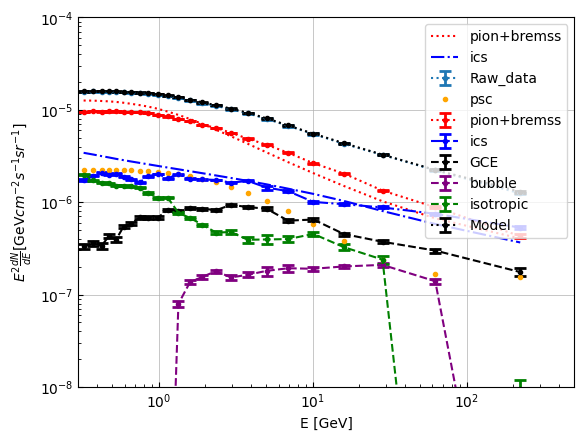

In [64]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
plt.style.use('default')
ax=plt.subplot()

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('E [GeV]')
ax.set_ylabel(r'$E^2 \frac{dN}{dE}$[GeV$cm^{-2}$$s^{-1} sr^{-1}$]')

ax.set_ylim(1e-8, 1e-4)
ax.set_xlim(0.3, 500)

ax.tick_params(axis='y', which='both', direction='in', left=True)
ax.tick_params(axis='x', which='both', direction='in', bottom=True)
ax.minorticks_on()
ax.grid(True, which='Major', linestyle='-', linewidth=0.5)

#m=minuit4
#fitted=minuit4.values[:]
#fitted_errors=minuit4.errors[:]

fitted_errors=param_errors
fitted=params
#fitted=np.ones(120)
sr=0.214411*2

ax.errorbar(E*1e-3, counts_per_exp*(E**2)/(1000*delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(1000*delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')

#ax.plot(E*1e-3, psc*(E**2)/(1000*delta_E*sr))

ax.errorbar(E*1e-3, psc*(E**2)/(1000*delta_E*sr), linestyle='', marker='.', elinewidth=2, capsize=4, capthick=2, label='psc', color='orange')


ax.errorbar(E*1e-3, fitted[0:24]*(pion+bremss)*(E**2)/(1000*delta_E*sr), yerr=fitted_errors[0:24]*(pion+bremss)*(E**2)/(1000*delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='pion+bremss', color='red')
ax.errorbar(E*1e-3, fitted[24:48]*(ics)*(E**2)/(1000*delta_E*sr), yerr=fitted_errors[24:48]*(ics)*(E**2)/(1000*delta_E*sr), linestyle='dashdot', marker='.', elinewidth=2, capsize=4, capthick=2, label='ics', color='blue')

ax.plot(E*1e-3, (pion+bremss)*(E**2)/(1000*delta_E*sr), linestyle='dotted', label='pion+bremss', color='red')
ax.plot(E*1e-3, (ics)*(E**2)/(1000*delta_E*sr), linestyle='dashdot', label='ics', color='blue')



ax.errorbar(E*1e-3,  fitted[48:72]*(GCE)*(E**2)/(1000*delta_E*sr), yerr=np.sqrt((fitted_errors[48:72]*GCE)**2)*(E**2)/(1000*delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')



ax.errorbar(E*1e-3, fitted[72:96]*(bubble)*(E**2)/(1000*delta_E*sr),yerr=fitted_errors[72:96]*(bubble)*(E**2)/(1000*delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='bubble', color='purple')

ax.errorbar(E*1e-3, fitted[96:120]*(isotropic)*(E**2)/(1000*delta_E*sr),yerr=fitted_errors[96:120]*(isotropic)*(E**2)/(1000*delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='isotropic', color='green')


summed=fitted[0:24]*(pion+bremss) + fitted[24:48]*(ics) + fitted[48:72]*(GCE) + fitted[72:96]*(bubble) + fitted[96:120]*(isotropic) + psc


#summed=fitted[0:24]*(pion+bremss) + fitted[24:48]*(ics) + 0*(GCE) + fitted[72:96]*(bubble) + fitted[96:120]*(isotropic) + psc

summed_err=np.sqrt((fitted_errors[0:24]*(pion+bremss)*(E**2)/(1000*delta_E*sr))**2 + (fitted_errors[24:48]*(ics)*(E**2)/(1000*delta_E*sr))**2 + (fitted_errors[48:72]*(0.1*GCE)*(E**2)/(1000*delta_E*sr))**2 + (fitted_errors[72:96]*(bubble)*(E**2)/(1000*delta_E*sr))**2 + (fitted_errors[96:120]*(isotropic)*(E**2)/(1000*delta_E*sr))**2)

ax.errorbar(E*1e-3, summed*(E**2)/(1000*delta_E*sr), yerr=summed_err, linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Model', color='black')

#ax.errorbar(E*1e-3, (counts_per_exp-summed_test)*(E**2)/(1000*delta_E*sr), yerr=summed_err, linestyle='', marker='.', elinewidth=2, capsize=4, capthick=2, label='Model', color='black')



"""
ax.plot(E*1e-3, (isotropic)*(E**2)/(1000*exposure(E*1e-3)*delta_E*sr), label='iso', color='green')
ax.plot(E*1e-3, (model)*(E**2)/(1000*exposure(E*1e-3)*delta_E*sr), label='Total model', color='cyan')
ax.plot(E*1e-3, psc*(E**2)/(1000*exposure(E*1e-3)*delta_E*sr), label='Total point sources', color='yellow')
#ax.plot(E*1e-3, bubble.T[1, 0:], label='Bubble', color='purple') """
ax.legend()

In [65]:
np.savetxt('/home/FermiLAT/Sanghwan/GCE_model_F_p_p.dat', np.vstack([E*1e-3, fitted[48:72]*(GCE)*(E**2)/(1000*delta_E*sr), counts_per_exp_err*(E**2)/(1000*delta_E*sr)]).T)

In [161]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from scipy.interpolate import interp1d
from iminuit import Minuit
#Constraints interpolated function
#Contains constraints for bubble and isotropic as well
#For isotropic, from https://arxiv.org/pdf/1410.3696.pdf Table 3

#Testing exposure per pixel

#Analysis for model F
#Correcting bubble template given from https://arxiv.org/pdf/1407.7905, Table 2

model='F'
def likelihood_constrained(parameter_set):
    data=fits.open('./GC_analysis/GC_all_time_ccube_masked.fits')
    psc_map=fits.open('./GC_analysis/Model/GC_all_time_psc_model.fits')
    pion=fits.open(f'./GC_analysis/Model/GC_all_time_pion_model{model}.fits')
    ics=fits.open(f'./GC_analysis/Model/GC_all_time_ics_model{model}.fits')
    bremss=fits.open(f'./GC_analysis/Model/GC_all_time_bremss_model{model}.fits')
    GCE=fits.open(f'./GC_analysis/Model/GC_all_time_GCE_model.fits')
    bubble=fits.open(f'./GC_analysis/Model/GC_all_time_fermi_bubble_model.fits')
    isotropic=fits.open(f'./GC_analysis/Model/GC_all_time_isotropic_model.fits')
    #####################################
    pion_bremss_param=parameter_set[0:24]
    ics_param=parameter_set[24:48]
    GCE_param=parameter_set[48:72]
    bubble_param=parameter_set[72:96]
    isotropic_param=parameter_set[96:120]
    alpha_psc=5
    f_psc=0.1
    ######################################
    #Main body for calculating Poissonian log-likelihood
    #for k in range(0, energy_length, 1):
    observed_pixel=data[0].data
    observed_pixel=observed_pixel.astype('float32')
    psc_pixel=psc_map[0].data
    pion_bremss_pixel=pion[0].data + bremss[0].data
    ics_pixel=ics[0].data
    GCE_pixel=GCE[0].data
    iso_pixel=isotropic[0].data
    bubble_pixel=bubble[0].data
    expected_pixel=np.zeros(np.shape(observed_pixel))
    for i in range(0, len(expected_pixel), 1):
        expected_pixel[i]= pion_bremss_param[i]*pion_bremss_pixel[i] + ics_param[i]*ics_pixel[i] + psc_pixel[i] + GCE_param[i]*GCE_pixel[i] + isotropic_param[i]*iso_pixel[i] + bubble_param[i]*bubble_pixel[i]
    #expected_pixel= pion_bremss_param*pion_bremss_pixel + ics_param*ics_pixel + GCE_param*GCE_pixel + isotropic_param*iso_pixel + bubble_param*bubble_pixel
    expected_pixel[expected_pixel==0] = 1e-10


    #bgr_pixel=pion_bremss_pixel + ics_pixel
    bgr_pixel = fits.open('./GC_analysis/Model/GC_all_time_bremss_modelP.fits')[0].data + fits.open('./GC_analysis/Model/GC_all_time_ics_modelP.fits')[0].data + fits.open('./GC_analysis/Model/GC_all_time_pion_modelP.fits')[0].data


    bgr_pixel[bgr_pixel==0] = 1e-10
    psc_pixel[psc_pixel==0] = 1e-10

    w=1/( ( (psc_pixel)/(f_psc*bgr_pixel) )**alpha_psc +1 )
    lhd=2*w*( expected_pixel - observed_pixel*np.log((expected_pixel)) )

    #At the end of the likelihood expression, there's term with ln(observed!) but is omitted since it does not affect overall analysis because it is constant term.

    # Preparing for the constraints

    E_bounds=fits.open('./GC_analysis/GC_all_time_ccube_masked.fits')[1].data


    E=np.zeros(len(E_bounds))
    for i in range(0, 4, 1):
        E[i] = 1e-3*(E_bounds[i][2] + E_bounds[i][1])/2
    for i in range(4, len(E_bounds), 1):
        E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)

    delta_E=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-3

    sr=0.214411*2

    exp_cube=np.sqrt(fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[:1]*fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[1:])
    for i in range(0, 4, 1):
        exp_cube[i] = ( fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[i] + fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[i+1] )/2
    for i in range(4, len(exp_cube), 1):
        exp_cube[i] = np.sqrt(fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[i]*fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[i+1])


    #Flux assiciated with constraints are considered with it's exposure per pixel values

    file_name='./GC_analysis/Model/GC_all_time_isotropic_model.fits'
    isotropic=np.zeros(len(fits.open(file_name)[0].data))
    for i in range(0, len(fits.open(file_name)[0].data), 1):
        a=exp_cube[i]
        isotropic[i] = np.sum( fits.open(file_name)[0].data[i]/a )*isotropic_param[i]

    file_name='./GC_analysis/Model/GC_all_time_fermi_bubble_model.fits'
    bubble=np.zeros(len(fits.open(file_name)[0].data))
    for i in range(0, len(fits.open(file_name)[0].data), 1):
        a=exp_cube[i]
        bubble[i] = np.sum( fits.open(file_name)[0].data[i]/a )*bubble_param[i]


    #bubble_sed=bubble/(1e-3*delta_E*sr)

    constraints=np.loadtxt('./GC_analysis/Model/bubble_constraints_asymmetric.txt')
    constraints_energy=constraints[0:, 0]
    constraints_flux=constraints[0:, 1]
    constraints_lower_error=constraints[0:, 2]
    constraints_upper_error=constraints[0:, 3]


    fluxint=interp1d(constraints_energy, constraints_flux, fill_value='extrapolate',  kind='cubic')
    lower_errint=interp1d(constraints_energy, constraints_lower_error, fill_value='extrapolate', kind='cubic')
    upper_errint=interp1d(constraints_energy, constraints_upper_error, fill_value='extrapolate', kind='cubic')

    flux_data=fluxint(E*1e-3)/((E*1e-3)**2)
    lower_error_data=lower_errint(E*1e-3)/((E*1e-3)**2)
    upper_error_data=upper_errint(E*1e-3)/((E*1e-3)**2)

    flux_data[flux_data<=0] = 1e-20
    lower_error_data[lower_error_data<=0] = 1e-20
    upper_error_data[upper_error_data<=0] = 1e-20


    for i in range(len(chi2)):
        larger_error=max([upper_error_data[i], lower_error_data[i]])
        if flux_data[i] < bubble_sed[i]:
            chi2[i] = ((bubble_sed[i] - flux_data[i])/upper_error_data[i])**2
        if flux_data[i] > bubble_sed[i]:
            chi2[i] = ((bubble_sed[i] - flux_data[i])/lower_error_data[i])**2
        if flux_data[i] == bubble_sed[i]:
            chi2[i] = ((bubble_sed[i] - flux_data[i])/larger_error)**2
        #chi2[i] = ((bubble_sed[i] - flux_data[i])/larger_error)**2

    iso_flux=isotropic/(sr*delta_E*1e-3)

    iso_constraints=np.loadtxt('./GC_analysis/Model/iso_constraints_conservative_sys.txt')
    iso_constraints_energy=iso_constraints[0:, 0]
    iso_constraints_flux=iso_constraints[0:, 1]
    iso_constraints_full_error=iso_constraints[0:, 2]


    fluxint=interp1d(iso_constraints_energy, iso_constraints_flux, fill_value="extrapolate")
    errint=interp1d(iso_constraints_energy, iso_constraints_full_error, fill_value="extrapolate")    

    iso_constraints_flux=fluxint(E*1e-3)
    iso_constraints_flux_err=errint(E*1e-3)

    iso_constraints_flux[iso_constraints_flux <= 0] = 1e-20
    iso_constraints_flux_err[iso_constraints_flux_err <= 0] = 1e-20

    chi2_iso=((iso_flux - iso_constraints_flux)**2/iso_constraints_flux_err**2) 

    return np.sum(lhd) + np.sum(chi2) + np.sum(chi2_iso)

In [58]:
import time
start_time = time.time()
end_time = time.time()
execution_time=end_time-start_time
print(execution_time)

2.0742416381835938e-05


In [59]:
likelihood_constrained(params)

-18665418.92087184

In [162]:
%%time
import time
start_time = time.time()

execution_time = end_time - start_time
m=Minuit(likelihood_constrained, params)
m.errordef=0.5
m.limits=(-4, 4)
m.strategy=1
m.tol=1e-1
m.simplex()
end_time = time.time()
execution_time = end_time - start_time
print(execution_time)
print(m)

KeyboardInterrupt: 

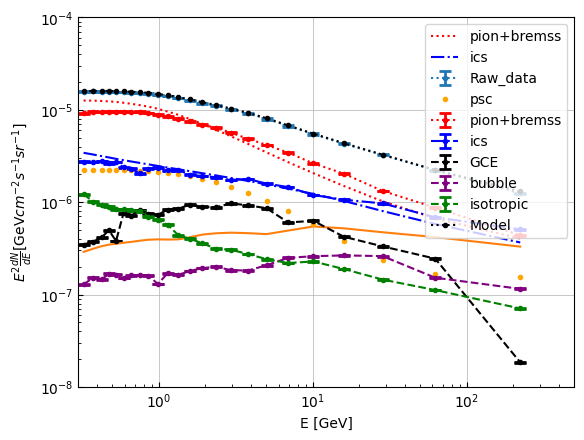

In [84]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
plt.style.use('default')
ax=plt.subplot()

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('E [GeV]')
ax.set_ylabel(r'$E^2 \frac{dN}{dE}$[GeV$cm^{-2}$$s^{-1} sr^{-1}$]')

ax.set_ylim(1e-8, 1e-4)
ax.set_xlim(0.3, 500)

ax.tick_params(axis='y', which='both', direction='in', left=True)
ax.tick_params(axis='x', which='both', direction='in', bottom=True)
ax.minorticks_on()
ax.grid(True, which='Major', linestyle='-', linewidth=0.5)

#m=minuit4
fitted=m.values[:]
fitted_errors=m.errors[:]
fitted=params

sr=0.214411*2

ax.errorbar(E*1e-3, counts_per_exp*(E**2)/(1000*delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(1000*delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')

#ax.plot(E*1e-3, psc*(E**2)/(1000*delta_E*sr))

ax.errorbar(E*1e-3, psc*(E**2)/(1000*delta_E*sr), linestyle='', marker='.', elinewidth=2, capsize=4, capthick=2, label='psc', color='orange')


ax.errorbar(E*1e-3, fitted[0:24]*(pion+bremss)*(E**2)/(1000*delta_E*sr), yerr=fitted_errors[0:24]*(pion+bremss)*(E**2)/(1000*delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='pion+bremss', color='red')
ax.errorbar(E*1e-3, fitted[24:48]*(ics)*(E**2)/(1000*delta_E*sr), yerr=fitted_errors[24:48]*(ics)*(E**2)/(1000*delta_E*sr), linestyle='dashdot', marker='.', elinewidth=2, capsize=4, capthick=2, label='ics', color='blue')

ax.plot(E*1e-3, (pion+bremss)*(E**2)/(1000*delta_E*sr), linestyle='dotted', label='pion+bremss', color='red')

ax.plot(E*1e-3, (ics)*(E**2)/(1000*delta_E*sr), linestyle='dashdot', label='ics', color='blue')



ax.errorbar(E*1e-3,  fitted[48:72]*(GCE)*(E**2)/(1000*delta_E*sr), yerr=np.sqrt((fitted_errors[48:72]*GCE)**2)*(E**2)/(1000*delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')



ax.errorbar(E*1e-3, fitted[72:96]*(bubble)*(E**2)/(1000*delta_E*sr),yerr=fitted_errors[72:96]*(bubble)*(E**2)/(1000*delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='bubble', color='purple')
ax.plot(E*1e-3, bubble*(E**2)/(1000*delta_E*sr) )


ax.errorbar(E*1e-3, fitted[96:120]*(isotropic)*(E**2)/(1000*delta_E*sr),yerr=fitted_errors[96:120]*(isotropic)*(E**2)/(1000*delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='isotropic', color='green')


summed=fitted[0:24]*(pion+bremss) + fitted[24:48]*(ics) + fitted[48:72]*(GCE) + fitted[72:96]*(bubble) + fitted[96:120]*(isotropic) + psc

ax.errorbar(E*1e-3, summed*(E**2)/(1000*delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Model', color='black')

ax.legend()

In [137]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from scipy.interpolate import interp1d
from iminuit import Minuit
#Constraints interpolated function
#Contains constraints for bubble and isotropic as well
#For isotropic, from https://arxiv.org/pdf/1410.3696.pdf Table 3

#Testing exposure per pixel

#Analysis for model F
#Correcting bubble template given from https://arxiv.org/pdf/1407.7905, Table 2

class Likelihood:
    def __init__(self, model, energy_bin):
        self.model=model
        self.energy_bin=energy_bin
    def likelihood_constrained(self, parameter_set):
        data=fits.open('./GC_analysis/GC_ccw_exposure_ccube_masked.fits')
        psc_map=fits.open('./GC_analysis/Model/GC_psc_model.fits')
        pion=fits.open(f'./GC_analysis/Model/GC_pion_model{self.model}.fits')
        ics=fits.open(f'./GC_analysis/Model/GC_ics_model{self.model}.fits')
        bremss=fits.open(f'./GC_analysis/Model/GC_bremss_model{self.model}.fits')
        GCE=fits.open(f'./GC_analysis/Model/GC_GCE_model.fits')
        bubble=fits.open(f'./GC_analysis/Model/GC_fermi_bubble_model.fits')
        isotropic=fits.open(f'./GC_analysis/Model/GC_isotropic_model.fits')
        #####################################
        pion_bremss_param=parameter_set[0]
        ics_param=parameter_set[1]
        GCE_param=parameter_set[2]
        bubble_param=parameter_set[3]
        isotropic_param=parameter_set[4]
        alpha_psc=5
        f_psc=0.1
        ######################################
        #Main body for calculating Poissonian log-likelihood
        #for k in range(0, energy_length, 1):
        observed_pixel=data[0].data[self.energy_bin]
        observed_pixel=observed_pixel.astype('float32')
        psc_pixel=psc_map[0].data[self.energy_bin]
        pion_bremss_pixel=pion[0].data[self.energy_bin] + bremss[0].data[self.energy_bin]
        ics_pixel=ics[0].data[self.energy_bin]
        GCE_pixel=GCE[0].data[self.energy_bin]
        iso_pixel=isotropic[0].data[self.energy_bin]
        bubble_pixel=bubble[0].data[self.energy_bin]
        expected_pixel= pion_bremss_param*pion_bremss_pixel + ics_param*ics_pixel + psc_pixel + GCE_param*GCE_pixel + isotropic_param*iso_pixel + bubble_param*bubble_pixel
        #expected_pixel= pion_bremss_param*pion_bremss_pixel + ics_param*ics_pixel + GCE_param*GCE_pixel + isotropic_param*iso_pixel + bubble_param*bubble_pixel
        expected_pixel[expected_pixel==0] = 1e-10
        
        
        #bgr_pixel=pion_bremss_pixel + ics_pixel
        bgr_pixel = fits.open('./GC_analysis/Model/GC_bremss_modelP.fits')[0].data[self.energy_bin] + fits.open('./GC_analysis/Model/GC_ics_modelP.fits')[0].data[self.energy_bin] + fits.open('./GC_analysis/Model/GC_pion_modelP.fits')[0].data[self.energy_bin]
        
        
        bgr_pixel[bgr_pixel==0] = 1e-10
        psc_pixel[psc_pixel==0] = 1e-10

        w=1/( ( (psc_pixel)/(f_psc*bgr_pixel) )**alpha_psc +1 )
        lhd=2*w*( expected_pixel - observed_pixel*np.log((expected_pixel)) )

        #At the end of the likelihood expression, there's term with ln(observed!) but is omitted since it does not affect overall analysis because it is constant term.

        # Preparing for the constraints

        E_bounds=fits.open('./GC_analysis/GC_ccw_exposure_ccube_masked.fits')[1].data


        E=np.zeros(len(E_bounds))
        for i in range(0, 4, 1):
            E[i] = 1e-3*(E_bounds[i][2] + E_bounds[i][1])/2
        for i in range(4, len(E_bounds), 1):
            E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)

        delta_E=np.zeros(len(E_bounds))
        for i in range(0, len(E_bounds), 1):
            delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-3

        sr=0.214411*2

        exp_cube=np.sqrt(fits.open('./GC_analysis/GC_ccw_exposure_expcube.fits')[0].data[:1]*fits.open('./GC_analysis/GC_ccw_exposure_expcube.fits')[0].data[1:])
        for i in range(0, 4, 1):
            exp_cube[i] = ( fits.open('./GC_analysis/GC_ccw_exposure_expcube.fits')[0].data[i] + fits.open('./GC_analysis/GC_ccw_exposure_expcube.fits')[0].data[i+1] )/2
        for i in range(4, len(exp_cube), 1):
            exp_cube[i] = np.sqrt(fits.open('./GC_analysis/GC_ccw_exposure_expcube.fits')[0].data[i]*fits.open('./GC_analysis/GC_ccw_exposure_expcube.fits')[0].data[i+1])

        
        #Flux assiciated with constraints are considered with it's exposure per pixel values
        
        file_name='./GC_analysis/Model/GC_isotropic_model.fits'
        isotropic=np.zeros(len(fits.open(file_name)[0].data))
        for i in range(0, len(fits.open(file_name)[0].data), 1):
            a=exp_cube[i]
            isotropic[i] = np.sum( fits.open(file_name)[0].data[i]/a )*isotropic_param

        file_name='./GC_analysis/Model/GC_fermi_bubble_model.fits'
        bubble=np.zeros(len(fits.open(file_name)[0].data))
        for i in range(0, len(fits.open(file_name)[0].data), 1):
            a=exp_cube[i]
            bubble[i] = np.sum( fits.open(file_name)[0].data[i]/a )*bubble_param


            
        #constraints=np.loadtxt('./GC_analysis/Model/bubble_constraints.txt')
        bubble_sed=(E**2)*bubble/(1000*delta_E*sr)
        #errint=interp1d(constraints[0:, 0], (constraints[0:, 6]*1e-7),kind='cubic', fill_value="extrapolate")
        #fluxint=interp1d(constraints[0:, 0], (constraints[0:, 3]*1e-7),kind='cubic', fill_value="extrapolate")
        #constraints=np.loadtxt('./GC_analysis/Model/bubble_constraints_conservative_sys.txt')
        constraints=np.loadtxt('./GC_analysis/Model/bubble_constraints_asymmetric.txt')
        constraints_energy=constraints[0:, 0]
        constraints_flux=constraints[0:, 1]
        constraints_lower_error=constraints[0:, 2]
        constraints_upper_error=constraints[0:, 3]
        
        
        fluxint=interp1d(constraints_energy, constraints_flux, fill_value='extrapolate',  kind='cubic')
        lower_errint=interp1d(constraints_energy, constraints_lower_error, fill_value='extrapolate', kind='cubic')
        upper_errint=interp1d(constraints_energy, constraints_upper_error, fill_value='extrapolate', kind='cubic')

        flux_data=fluxint(E*1e-3)
        lower_error_data=lower_errint(E*1e-3)
        upper_error_data=upper_errint(E*1e-3)
        
        flux_data[flux_data<=0] = 1e-20
        lower_error_data[lower_error_data<=0] = 1e-20
        upper_error_data[upper_error_data<=0] = 1e-20

        chi2=np.zeros(len(bubble_sed))
        
        for i in range(len(chi2)):
            larger_error=max([upper_error_data[i], lower_error_data[i]])
            if flux_data[i] > bubble_sed[i]:
                chi2[i] = ((bubble_sed[i] - flux_data[i])/upper_error_data[i])**2
            if flux_data[i] < bubble_sed[i]:
                chi2[i] = ((bubble_sed[i] - flux_data[i])/lower_error_data[i])**2
            if flux_data[i] == bubble_sed[i]:
                chi2[i] = ((bubble_sed[i] - flux_data[i])/larger_error)**2
            #chi2[i] = ((bubble_sed[i] - flux_data[i])/larger_error)**2

        #chi2=((bubble_sed - flux_data)/error_data)**2
        #errint=interp1d(constraints[0:, 0], constraints[0:, 6]*1e-7,kind='cubic', fill_value="extrapolate")
        #fluxint=interp1d(constraints[0:, 0], constraints[0:, 3]*1e-7,kind='cubic', fill_value="extrapolate")
        #chi2 = ( (bubble_sed - fluxint(E*1e-3))/(errint(E*1e-3)) )**2


        ####
        # Preparing isotropic component constraints
        #iso_constraints=np.loadtxt('./GC_analysis/Model/iso_constraints.txt')
        iso_flux=isotropic/(sr*delta_E*1e-3)
        #iso_constraints_energy=np.sqrt(iso_constraints[0:, 0]*iso_constraints[0:, 1]) #GeV
        #iso_constraints_delta=iso_constraints[0:, 1] - iso_constraints[0:, 0]
        #iso_constraints_data=(iso_constraints[0:, 2])/iso_constraints_delta #Will give GeV^-1 cm^-2 s^-1 sr^-1
        #iso_constraints_err=(iso_constraints[0:, 3])/iso_constraints_delta
        iso_constraints=np.loadtxt('./GC_analysis/Model/iso_constraints_conservative_sys.txt')
        iso_constraints_energy=iso_constraints[0:, 0]
        iso_constraints_flux=iso_constraints[0:, 1]
        iso_constraints_full_error=iso_constraints[0:, 2]

        #fluxint=interp1d(iso_constraints_energy, iso_constraints_data, fill_value="extrapolate")
        #errint=interp1d(iso_constraints_energy, iso_constraints_err, fill_value="extrapolate")

        fluxint=interp1d(iso_constraints_energy, iso_constraints_flux, fill_value="extrapolate")
        errint=interp1d(iso_constraints_energy, iso_constraints_full_error, fill_value="extrapolate")    

        iso_constraints_flux=fluxint(E*1e-3)
        iso_constraints_flux_err=errint(E*1e-3)

        iso_constraints_flux[iso_constraints_flux <= 0] = 1e-20
        iso_constraints_flux_err[iso_constraints_flux_err <= 0] = 1e-20

        chi2_iso=((iso_flux - iso_constraints_flux)**2/iso_constraints_flux_err**2) 

        #return np.sum(lhd) + np.sum(chi2) + np.sum(chi2_iso)
        return np.sum(lhd) + chi2[self.energy_bin] + chi2_iso[self.energy_bin]
        #return lhd, w   
            
    def likelihood_module(self, parameters):
        m=Minuit(self.likelihood_constrained, parameters)
        m.migrad()
        return m
    
    def minuit_module(self):
        tol=1e-1
        tol1=tol
        tol2=tol
        tol3=tol
        m=Minuit(self.likelihood_constrained,np.ones(5))
        m.limits=(-10, 10)
        m.strategy=0
        while True:
            if True:
                #m=Minuit(self.likelihood_constrained, np.ones(5))
                m.limits=(-10, 10)
                m.strategy=0
                #m.limits=(0, None)
                m.tol=tol1
                print(f'tol1 = {m.tol}')
                #m.migrad()
                m.migrad()
                if m.valid==True:
                    print(m)
                    break;
                else:
                    tol1*=1e+1
            #if tol1>=1e+15:
            #    m=Minuit(self.likelihood_constrained, np.ones(5))
            #    m.limits=(-10, 10)
            #    m.strategy=1
            #    m.tol=tol2
            #    print(f'tol2 = {m.tol}')
            #    m.migrad()
            #    if m.valid==True:
            #        break;
            #    else:
            #        tol2*=1e+1
            #if tol1>=1e+5 and tol2>=1e+10:
            #    print(tol2)
            #if tol1>=1e+5 and tol2>=1e+5:
            #    m.strategy=0
            #    m.tol=tol3
            #    m.migrad()
            #    if m.valie==True:
            #        print(m.strategy)
            #        break;
            #    else:
            #        tol3*=1e+1
        return m.values[:]
    

In [136]:
Likelihood('F', 0).likelihood_constrained(np.ones(5))

-630600.0514674153

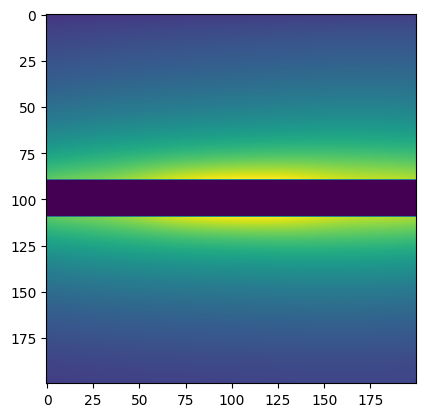

In [113]:
plt.imshow(fits.open(f'./GC_analysis/Model/GC_ics_model{"F"}.fits')[0].data[0])

In [ ]:
# 1) asymmetric error bar for bubble test 2) no PSC template for fitting test

In [129]:
params=np.hstack([pion_bremss_fitted, ics_fitted, GCE_fitted, bubble_fitted, isotropic_fitted])

In [ ]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
plt.style.use('default')
ax=plt.subplot()

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('E [GeV]')
ax.set_ylabel(r'$E^2 \frac{dN}{dE}$[GeV$cm^{-2}$$s^{-1} sr^{-1}$]')

ax.set_ylim(1e-8, 1e-4)
ax.set_xlim(0.3, 500)

ax.tick_params(axis='y', which='both', direction='in', left=True)
ax.tick_params(axis='x', which='both', direction='in', bottom=True)
ax.minorticks_on()
ax.grid(True, which='Major', linestyle='-', linewidth=0.5)

#m=minuit4
#fitted=m.values[:]
fitted_errors=np.zeros(120)
fitted=params

sr=0.214411*2

ax.errorbar(E*1e-3, counts_per_exp*(E**2)/(1000*delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(1000*delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')

#ax.plot(E*1e-3, psc*(E**2)/(1000*delta_E*sr))

ax.errorbar(E*1e-3, psc*(E**2)/(1000*delta_E*sr), linestyle='', marker='.', elinewidth=2, capsize=4, capthick=2, label='psc', color='orange')


ax.errorbar(E*1e-3, fitted[0:24]*(pion+bremss)*(E**2)/(1000*delta_E*sr), yerr=fitted_errors[0:24]*(pion+bremss)*(E**2)/(1000*delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='pion+bremss', color='red')
ax.errorbar(E*1e-3, fitted[24:48]*(ics)*(E**2)/(1000*delta_E*sr), yerr=fitted_errors[24:48]*(ics)*(E**2)/(1000*delta_E*sr), linestyle='dashdot', marker='.', elinewidth=2, capsize=4, capthick=2, label='ics', color='blue')

ax.plot(E*1e-3, (pion+bremss)*(E**2)/(1000*delta_E*sr), linestyle='dotted', label='pion+bremss', color='red')

ax.plot(E*1e-3, (ics)*(E**2)/(1000*delta_E*sr), linestyle='dashdot', label='ics', color='blue')



ax.errorbar(E*1e-3,  fitted[48:72]*(GCE)*(E**2)/(1000*delta_E*sr), yerr=np.sqrt((fitted_errors[48:72]*GCE)**2)*(E**2)/(1000*delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')



ax.errorbar(E*1e-3, fitted[72:96]*(bubble)*(E**2)/(1000*delta_E*sr),yerr=fitted_errors[72:96]*(bubble)*(E**2)/(1000*delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='bubble', color='purple')
ax.plot(E*1e-3, bubble*(E**2)/(1000*delta_E*sr) )


ax.errorbar(E*1e-3, fitted[96:120]*(isotropic)*(E**2)/(1000*delta_E*sr),yerr=fitted_errors[96:120]*(isotropic)*(E**2)/(1000*delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='isotropic', color='green')


summed=fitted[0:24]*(pion+bremss) + fitted[24:48]*(ics) + fitted[48:72]*(GCE) + fitted[72:96]*(bubble) + fitted[96:120]*(isotropic) + psc

ax.errorbar(E*1e-3, summed*(E**2)/(1000*delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Model', color='black')

ax.legend()

In [117]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from scipy.interpolate import interp1d
from iminuit import Minuit
#Constraints interpolated function
#Contains constraints for bubble and isotropic as well
#For isotropic, from https://arxiv.org/pdf/1410.3696.pdf Table 3

#Testing exposure per pixel

#Analysis for model F
#Correcting bubble template given from https://arxiv.org/pdf/1407.7905, Table 2

model='F'
def likelihood_constrained(parameter_set):
    data=fits.open('./GC_analysis/GC_ccw_exposure_ccube_masked.fits')
    psc_map=fits.open('./GC_analysis/Model/GC_psc_model.fits')
    pion=fits.open(f'./GC_analysis/Model/GC_pion_model{model}.fits')
    ics=fits.open(f'./GC_analysis/Model/GC_ics_model{model}.fits')
    bremss=fits.open(f'./GC_analysis/Model/GC_bremss_model{model}.fits')
    GCE=fits.open(f'./GC_analysis/Model/GC_GCE_model.fits')
    bubble=fits.open(f'./GC_analysis/Model/GC_fermi_bubble_model.fits')
    isotropic=fits.open(f'./GC_analysis/Model/GC_isotropic_model.fits')
    #####################################
    pion_bremss_param=parameter_set[0:24]
    ics_param=parameter_set[24:48]
    GCE_param=parameter_set[48:72]
    bubble_param=parameter_set[72:96]
    isotropic_param=parameter_set[96:120]
    alpha_psc=5
    f_psc=0.1
    ######################################
    #Main body for calculating Poissonian log-likelihood
    #for k in range(0, energy_length, 1):
    observed_pixel=data[0].data
    observed_pixel=observed_pixel.astype('float32')
    psc_pixel=psc_map[0].data
    pion_bremss_pixel=pion[0].data + bremss[0].data
    ics_pixel=ics[0].data
    GCE_pixel=GCE[0].data
    iso_pixel=isotropic[0].data
    bubble_pixel=bubble[0].data
    
    expected_pixel=np.zeros(np.shape(observed_pixel))
    for i in range(0, len(observed_pixel), 1):
        expected_pixel[i]= pion_bremss_param[i]*pion_bremss_pixel[i] + ics_param[i]*ics_pixel[i] + psc_pixel[i] + GCE_param[i]*GCE_pixel[i] + isotropic_param[i]*iso_pixel[i] + bubble_param[i]*bubble_pixel[i]
    #expected_pixel= pion_bremss_param*pion_bremss_pixel + ics_param*ics_pixel + GCE_param*GCE_pixel + isotropic_param*iso_pixel + bubble_param*bubble_pixel
    expected_pixel[expected_pixel==0] = 1e-10


    #bgr_pixel=pion_bremss_pixel + ics_pixel
    bgr_pixel = fits.open('./GC_analysis/Model/GC_bremss_modelP.fits')[0].data + fits.open('./GC_analysis/Model/GC_ics_modelP.fits')[0].data + fits.open('./GC_analysis/Model/GC_pion_modelP.fits')[0].data


    bgr_pixel[bgr_pixel==0] = 1e-10
    psc_pixel[psc_pixel==0] = 1e-10

    w=1/( ( (psc_pixel)/(f_psc*bgr_pixel) )**alpha_psc +1 )
    lhd=2*w*( expected_pixel - observed_pixel*np.log((expected_pixel)) )

    #At the end of the likelihood expression, there's term with ln(observed!) but is omitted since it does not affect overall analysis because it is constant term.

    # Preparing for the constraints

    E_bounds=fits.open('./GC_analysis/GC_ccw_exposure_ccube_masked.fits')[1].data


    E=np.zeros(len(E_bounds))
    for i in range(0, 4, 1):
        E[i] = 1e-3*(E_bounds[i][2] + E_bounds[i][1])/2
    for i in range(4, len(E_bounds), 1):
        E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)

    delta_E=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-3

    sr=0.214411*2

    exp_cube=np.sqrt(fits.open('./GC_analysis/GC_ccw_exposure_expcube.fits')[0].data[:1]*fits.open('./GC_analysis/GC_ccw_exposure_expcube.fits')[0].data[1:])
    for i in range(0, 4, 1):
        exp_cube[i] = ( fits.open('./GC_analysis/GC_ccw_exposure_expcube.fits')[0].data[i] + fits.open('./GC_analysis/GC_ccw_exposure_expcube.fits')[0].data[i+1] )/2
    for i in range(4, len(exp_cube), 1):
        exp_cube[i] = np.sqrt(fits.open('./GC_analysis/GC_ccw_exposure_expcube.fits')[0].data[i]*fits.open('./GC_analysis/GC_ccw_exposure_expcube.fits')[0].data[i+1])


    #Flux assiciated with constraints are considered with it's exposure per pixel values

    file_name='./GC_analysis/Model/GC_isotropic_model.fits'
    isotropic=np.zeros(len(fits.open(file_name)[0].data))
    for i in range(0, len(fits.open(file_name)[0].data), 1):
        a=exp_cube[i]
        isotropic[i] = np.sum( fits.open(file_name)[0].data[i]/a )*isotropic_param[i]

    file_name='./GC_analysis/Model/GC_fermi_bubble_model_no_convol.fits'
    bubble=np.zeros(len(fits.open(file_name)[0].data))
    for i in range(0, len(fits.open(file_name)[0].data), 1):
        a=exp_cube[i]
        bubble[i] = np.sum( fits.open(file_name)[0].data[i]/a )*bubble_param[i]


    bubble_sed=(E**2)*bubble/(1000*delta_E*sr)

    constraints=np.loadtxt('./GC_analysis/Model/bubble_constraints_asymmetric.txt')
    constraints_energy=constraints[0:, 0]
    constraints_flux=constraints[0:, 1]
    constraints_lower_error=constraints[0:, 2]
    constraints_upper_error=constraints[0:, 3]


    fluxint=interp1d(constraints_energy, constraints_flux, fill_value='extrapolate',  kind='cubic')
    lower_errint=interp1d(constraints_energy, constraints_lower_error, fill_value='extrapolate', kind='cubic')
    upper_errint=interp1d(constraints_energy, constraints_upper_error, fill_value='extrapolate', kind='cubic')

    flux_data=fluxint(E*1e-3)
    lower_error_data=lower_errint(E*1e-3)
    upper_error_data=upper_errint(E*1e-3)

    flux_data[flux_data<=0] = 1e-20
    lower_error_data[lower_error_data<=0] = 1e-20
    upper_error_data[upper_error_data<=0] = 1e-20

    chi2=np.zeros(len(bubble_sed))
    for i in range(len(chi2)):
        larger_error=max([upper_error_data[i], lower_error_data[i]])
        if flux_data[i] > bubble_sed[i]:
            chi2[i] = ((bubble_sed[i] - flux_data[i])/upper_error_data[i])**2
        if flux_data[i] < bubble_sed[i]:
            chi2[i] = ((bubble_sed[i] - flux_data[i])/lower_error_data[i])**2
        if flux_data[i] == bubble_sed[i]:
            chi2[i] = ((bubble_sed[i] - flux_data[i])/larger_error)**2
        #chi2[i]=((bubble_sed[i] - flux_data[i])/larger_error)**2



    iso_flux=isotropic/(sr*delta_E*1e-3)

    iso_constraints=np.loadtxt('./GC_analysis/Model/iso_constraints_conservative_sys.txt')
    iso_constraints_energy=iso_constraints[0:, 0]
    iso_constraints_flux=iso_constraints[0:, 1]
    iso_constraints_full_error=iso_constraints[0:, 2]

    fluxint=interp1d(iso_constraints_energy, iso_constraints_flux, fill_value="extrapolate")
    errint=interp1d(iso_constraints_energy, iso_constraints_full_error, fill_value="extrapolate")    

    iso_constraints_flux=fluxint(E*1e-3)
    iso_constraints_flux_err=errint(E*1e-3)

    iso_constraints_flux[iso_constraints_flux <= 0] = 1e-20
    iso_constraints_flux_err[iso_constraints_flux_err <= 0] = 1e-20

    chi2_iso=((iso_flux - iso_constraints_flux)**2/iso_constraints_flux_err**2) 

    return np.sum(lhd) + np.sum(chi2) + np.sum(chi2_iso)


In [107]:
likelihood_constrained(params)

-2782829.335453703

In [106]:
m.fval

-2787347.021812592

In [105]:
m=Minuit(likelihood_constrained, params)
m.limits=(-10, 10)
m.migrad()

/tmp/ipykernel_80067/1442644979.py:64: RuntimeWarning: invalid value encountered in log
  lhd=2*w*( expected_pixel - observed_pixel*np.log((expected_pixel)) )


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -2.787e+06                 │             Nfcn = 9925              │
│ EDM = 1.17e-05 (Goal: 0.0002)    │          time = 1433.2 sec           │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌────┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│    │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├────┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0  │ x0   │   0.735   │   0.006   │            │            │   -10   │   10    │       │
│ 1  │ x1   │   0.760   │   0.007   │            │            │   -10   │   10    │       │
│ 2  │ x2   │   0.765   │   0.007   │            │            │   -10   │   10    │       │
│ 3  │ x3   │   0.779   │   0.008   │            │            │   -10   │   10    │       │
│ 4  │ x4   │   0.786   │   0.009   │            │            │   -10   │   10    │       │
│ 5  │ x5   │   0.795   │   0.008   │            │            │   -10   │   10    │       │
│ 6  │ x6   │   0.813   │   0.008   │            │            │   -10   │   10    │       │
│ 7  │ x7   │   0.837   │   0.008   │            │            │   -10   │   10    │       │
│ 8  │ x8   │   0.840   │   0.008   │            │            │   -10   │   10    │       │
│ 9  │ x9   │   0.857   │   0.009   │            │            │   -10   │   10    │       │
│ 10 │ x10  │   0.900   │   0.009   │            │            │   -10   │   10    │       │
│ 11 │ x11  │   0.923   │   0.010   │            │            │   -10   │   10    │       │
│ 12 │ x12  │   0.955   │   0.011   │            │            │   -10   │   10    │       │
│ 13 │ x13  │   0.970   │   0.012   │            │            │   -10   │   10    │       │
│ 14 │ x14  │   1.062   │   0.014   │            │            │   -10   │   10    │       │
│ 15 │ x15  │   1.089   │   0.016   │            │            │   -10   │   10    │       │
│ 16 │ x16  │   1.106   │   0.020   │            │            │   -10   │   10    │       │
│ 17 │ x17  │   1.164   │   0.024   │            │            │   -10   │   10    │       │
│ 18 │ x18  │   1.235   │   0.031   │            │            │   -10   │   10    │       │
│ 19 │ x19  │   1.29    │   0.04    │            │            │   -10   │   10    │       │
│ 20 │ x20  │   1.23    │   0.06    │            │            │   -10   │   10    │       │
│ 21 │ x21  │   1.20    │   0.08    │            │            │   -10   │   10    │       │
│ 22 │ x22  │   1.39    │   0.12    │            │            │   -10   │   10    │       │
│ 23 │ x23  │   1.01    │   0.20    │            │            │   -10   │   10    │       │
│ 24 │ x24  │   0.52    │   0.05    │            │            │   -10   │   10    │       │
│ 25 │ x25  │   0.62    │   0.05    │            │            │   -10   │   10    │       │
│ 26 │ x26  │   0.67    │   0.06    │            │            │   -10   │   10    │       │
│ 27 │ x27  │   0.69    │   0.06    │            │            │   -10   │   10    │       │
│ 28 │ x28  │   0.78    │   0.07    │            │            │   -10   │   10    │       │
│ 29 │ x29  │   0.71    │   0.06    │            │            │   -10   │   10    │       │
│ 30 │ x30  │   0.73    │   0.06    │            │  

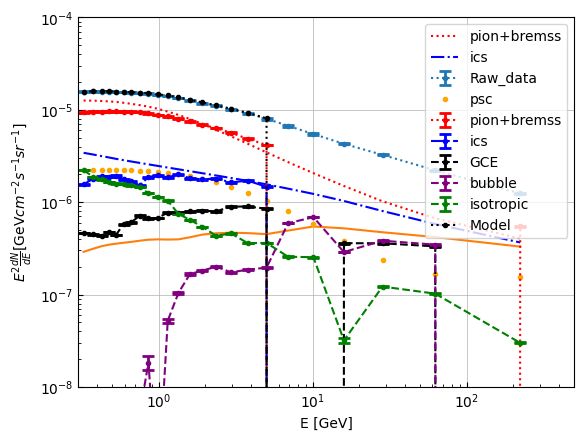

In [249]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
plt.style.use('default')
ax=plt.subplot()

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('E [GeV]')
ax.set_ylabel(r'$E^2 \frac{dN}{dE}$[GeV$cm^{-2}$$s^{-1} sr^{-1}$]')

ax.set_ylim(1e-8, 1e-4)
ax.set_xlim(0.3, 500)

ax.tick_params(axis='y', which='both', direction='in', left=True)
ax.tick_params(axis='x', which='both', direction='in', bottom=True)
ax.minorticks_on()
ax.grid(True, which='Major', linestyle='-', linewidth=0.5)

#m=minuit4
fitted=m.values[:]
fitted_errors=m.errors[:]
fitted=params

sr=0.214411*2

ax.errorbar(E*1e-3, counts_per_exp*(E**2)/(1000*delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(1000*delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')

#ax.plot(E*1e-3, psc*(E**2)/(1000*delta_E*sr))

ax.errorbar(E*1e-3, psc*(E**2)/(1000*delta_E*sr), linestyle='', marker='.', elinewidth=2, capsize=4, capthick=2, label='psc', color='orange')


ax.errorbar(E*1e-3, fitted[0:24]*(pion+bremss)*(E**2)/(1000*delta_E*sr), yerr=fitted_errors[0:24]*(pion+bremss)*(E**2)/(1000*delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='pion+bremss', color='red')
ax.errorbar(E*1e-3, fitted[24:48]*(ics)*(E**2)/(1000*delta_E*sr), yerr=fitted_errors[24:48]*(ics)*(E**2)/(1000*delta_E*sr), linestyle='dashdot', marker='.', elinewidth=2, capsize=4, capthick=2, label='ics', color='blue')

ax.plot(E*1e-3, (pion+bremss)*(E**2)/(1000*delta_E*sr), linestyle='dotted', label='pion+bremss', color='red')

ax.plot(E*1e-3, (ics)*(E**2)/(1000*delta_E*sr), linestyle='dashdot', label='ics', color='blue')



ax.errorbar(E*1e-3,  fitted[48:72]*(GCE)*(E**2)/(1000*delta_E*sr), yerr=np.sqrt((fitted_errors[48:72]*GCE)**2)*(E**2)/(1000*delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')



ax.errorbar(E*1e-3, fitted[72:96]*(bubble)*(E**2)/(1000*delta_E*sr),yerr=fitted_errors[72:96]*(bubble)*(E**2)/(1000*delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='bubble', color='purple')
ax.plot(E*1e-3, bubble*(E**2)/(1000*delta_E*sr) )


ax.errorbar(E*1e-3, fitted[96:120]*(isotropic)*(E**2)/(1000*delta_E*sr),yerr=fitted_errors[96:120]*(isotropic)*(E**2)/(1000*delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='isotropic', color='green')


summed=fitted[0:24]*(pion+bremss) + fitted[24:48]*(ics) + fitted[48:72]*(GCE) + fitted[72:96]*(bubble) + fitted[96:120]*(isotropic) + psc

ax.errorbar(E*1e-3, summed*(E**2)/(1000*delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Model', color='black')

ax.legend()

In [268]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from scipy.interpolate import interp1d
from iminuit import Minuit
#Constraints interpolated function
#Contains constraints for bubble and isotropic as well
#For isotropic, from https://arxiv.org/pdf/1410.3696.pdf Table 3

#Testing exposure per pixel

#Analysis for model F
#Correcting bubble template given from https://arxiv.org/pdf/1407.7905, Table 2

class Likelihood:
    def __init__(self, model, energy_bin):
        self.model=model
        self.energy_bin=energy_bin
    def likelihood_constrained(self, parameter_set):
        data=fits.open('./GC_analysis/GC_all_time_ccube_masked.fits')
        psc_map=fits.open('./GC_analysis/Model/GC_all_time_psc_model.fits')
        pion=fits.open(f'./GC_analysis/Model/GC_all_time_pion_model{self.model}.fits')
        ics=fits.open(f'./GC_analysis/Model/GC_all_time_ics_model{self.model}.fits')
        bremss=fits.open(f'./GC_analysis/Model/GC_all_time_bremss_model{self.model}.fits')
        GCE=fits.open(f'./GC_analysis/Model/GC_all_time_GCE_model.fits')
        bubble=fits.open(f'./GC_analysis/Model/GC_all_time_fermi_bubble_model.fits')
        isotropic=fits.open(f'./GC_analysis/Model/GC_all_time_isotropic_model.fits')
        #####################################
        pion_bremss_param=parameter_set[0]
        ics_param=parameter_set[1]
        GCE_param=parameter_set[2]
        bubble_param=parameter_set[3]
        isotropic_param=parameter_set[4]
        alpha_psc=5
        #alpha_psc=0.5
        f_psc=0.2
        #f_psc=0.1
        
        ######################################
        #Main body for calculating Poissonian log-likelihood
        #for k in range(0, energy_length, 1):
        observed_pixel=data[0].data[self.energy_bin]
        observed_pixel=observed_pixel.astype('float32')
        psc_pixel=psc_map[0].data[self.energy_bin]
        pion_bremss_pixel=pion[0].data[self.energy_bin] + bremss[0].data[self.energy_bin]
        ics_pixel=ics[0].data[self.energy_bin]
        GCE_pixel=GCE[0].data[self.energy_bin]
        iso_pixel=isotropic[0].data[self.energy_bin]
        bubble_pixel=bubble[0].data[self.energy_bin]
        expected_pixel= pion_bremss_param*pion_bremss_pixel + ics_param*ics_pixel + psc_pixel + GCE_param*GCE_pixel + isotropic_param*iso_pixel + bubble_param*bubble_pixel
        #expected_pixel= pion_bremss_param*pion_bremss_pixel + ics_param*ics_pixel + GCE_param*GCE_pixel + isotropic_param*iso_pixel + bubble_param*bubble_pixel
        #expected_pixel[expected_pixel==0] = 1e-20
        
        
        #bgr_pixel=pion_bremss_pixel + ics_pixel
        bgr_pixel = fits.open('./GC_analysis/Model/GC_all_time_bremss_modelP.fits')[0].data[self.energy_bin] + fits.open('./GC_analysis/Model/GC_all_time_ics_modelP.fits')[0].data[self.energy_bin] + fits.open('./GC_analysis/Model/GC_all_time_pion_modelP.fits')[0].data[self.energy_bin]
        
        
        #bgr_pixel[bgr_pixel==0] = 1e-20
        #psc_pixel[psc_pixel==0] = 1e-20

        w=1/( ( (psc_pixel)/(f_psc*bgr_pixel) )**alpha_psc +1 )
        #w[np.isnan(w)]=0
        lhd=2*w*( expected_pixel - observed_pixel*np.log((expected_pixel)) )
        lhd[np.isnan(lhd)]=0

        #At the end of the likelihood expression, there's term with ln(observed!) but is omitted since it does not affect overall analysis because it is constant term.

        # Preparing for the constraints

        E_bounds=fits.open('./GC_analysis/GC_all_time_ccube_masked.fits')[1].data


        E=np.zeros(len(E_bounds))
        for i in range(0, 4, 1):
            E[i] = 1e-3*(E_bounds[i][2] + E_bounds[i][1])/2
        for i in range(4, len(E_bounds), 1):
            E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)

        delta_E=np.zeros(len(E_bounds))
        for i in range(0, len(E_bounds), 1):
            delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-3

        sr=0.214411*2

        exp_cube=np.sqrt(fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[:1]*fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[1:])
        for i in range(0, 4, 1):
            exp_cube[i] = ( fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[i] + fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[i+1] )/2
        for i in range(4, len(exp_cube), 1):
            exp_cube[i] = np.sqrt(fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[i]*fits.open('./GC_analysis/GC_all_time_expcube.fits')[0].data[i+1])

        
        #Flux assiciated with constraints are considered with it's exposure per pixel values
        
        file_name='./GC_analysis/Model/GC_all_time_isotropic_model.fits'
        isotropic=np.zeros(len(fits.open(file_name)[0].data))
        for i in range(0, len(fits.open(file_name)[0].data), 1):
            a=exp_cube[i]
            isotropic[i] = np.sum( fits.open(file_name)[0].data[i]/a )#*isotropic_param
            
        isotropic[self.energy_bin] *= isotropic_param

        file_name='./GC_analysis/Model/GC_all_time_fermi_bubble_model.fits'
        bubble=np.zeros(len(fits.open(file_name)[0].data))
        for i in range(0, len(fits.open(file_name)[0].data), 1):
            a=exp_cube[i]
            bubble[i] = np.sum( fits.open(file_name)[0].data[i]/a )#*bubble_param
            
        bubble[self.energy_bin] *= bubble_param

        bubble_sed=bubble/(1e-3*delta_E*sr)

        constraints=np.loadtxt('./GC_analysis/Model/bubble_constraints_asymmetric.txt')
        constraints_energy=constraints[0:, 0]
        constraints_flux=constraints[0:, 1]/constraints[0:, 0]**2
        constraints_lower_error=constraints[0:, 2]/constraints[0:, 0]**2
        constraints_upper_error=constraints[0:, 3]/constraints[0:, 0]**2
        
        flux_data=constraints_flux
        lower_error_data=constraints_lower_error
        upper_error_data=constraints_upper_error
        #chi2=np.zeros(len(bubble_sed))
        
        #for i in range(len(bubble_sed)):
        chi2=0
        i=self.energy_bin
        larger_error=max([upper_error_data[i], lower_error_data[i]])
        if flux_data[i] < bubble_sed[i]:
            chi2 = ((bubble_sed[i] - flux_data[i])/upper_error_data[i])**2
        if flux_data[i] > bubble_sed[i]:
            chi2 = ((bubble_sed[i] - flux_data[i])/lower_error_data[i])**2
        if flux_data[i] == bubble_sed[i]:
            chi2 = ((bubble_sed[i] - flux_data[i])/larger_error)**2
        #print(chi2)
        iso_flux=isotropic/(sr*delta_E*1e-3)

        iso_constraints=np.loadtxt('./GC_analysis/Model/iso_constraints_conservative_sys.txt')
        iso_constraints_energy=iso_constraints[0:, 0]
        iso_constraints_flux=iso_constraints[0:, 1]
        iso_constraints_full_error=iso_constraints[0:, 2]


        fluxint=interp1d(iso_constraints_energy, iso_constraints_flux, fill_value="extrapolate", kind='quadratic')
        errint=interp1d(iso_constraints_energy, iso_constraints_full_error, fill_value="extrapolate", kind='quadratic')    

        iso_constraints_flux=fluxint(E*1e-3)
        iso_constraints_flux_err=errint(E*1e-3)

        iso_constraints_flux[iso_constraints_flux <= 0] = 1e-20
        iso_constraints_flux_err[iso_constraints_flux_err <= 0] = 1e-20

        chi2_iso=((iso_flux[self.energy_bin] - iso_constraints_flux[self.energy_bin])**2/iso_constraints_flux_err[self.energy_bin]**2) 

        return np.sum(lhd) + chi2 + chi2_iso

    def likelihood_module(self):
        return self.likelihood_constrained(np.ones(5))
    
    def minuit_module(self):
        tol=1e+1
        tol1=tol
        while True:
            if True:
                m=Minuit(self.likelihood_constrained, np.ones(5))
                m.errors[:]=np.ones(5)
                m.errordef=0.5
                m.limits=(-5, 5)
                m.strategy=2
                m.tol=tol1
                print(f'tol1 = {m.tol}')
                m.migrad()
                #m.simplex()
                if m.valid==True:
                    print(m)
                    break;
                else:
                    tol1*=1e+1
        return m.values[:], m.errors[:]
    
class Parameter_estimation():
    def __init__(self, model):
        self.model=model
    def minuit_run(self):
        pion_bremss_fitted=[]
        ics_fitted=[]
        GCE_fitted=[]
        bubble_fitted=[]
        isotropic_fitted=[]
        
        pion_bremss_fitted_errors=[]
        ics_fitted_errors=[]
        GCE_fitted_errors=[]
        bubble_fitted_errors=[]
        isotropic_fitted_errors=[]     
        for i in range(0, 24, 1):
            results=Likelihood(self.model, i).minuit_module()
            pion_bremss_fitted.append(results[0][0])
            ics_fitted.append(results[0][1])
            GCE_fitted.append(results[0][2])
            bubble_fitted.append(results[0][3])
            isotropic_fitted.append(results[0][4])
            
            pion_bremss_fitted_errors.append(results[1][0])
            ics_fitted_errors.append(results[1][1])
            GCE_fitted_errors.append(results[1][2])
            bubble_fitted_errors.append(results[1][3])
            isotropic_fitted_errors.append(results[1][4])
        return np.hstack([pion_bremss_fitted, ics_fitted, GCE_fitted, bubble_fitted, isotropic_fitted]), np.hstack([pion_bremss_fitted_errors, ics_fitted_errors, GCE_fitted_errors, bubble_fitted_errors, isotropic_fitted_errors])

In [269]:
%%time
params, param_errors=Parameter_estimation('F').minuit_run()

tol1 = 10.0


/tmp/ipykernel_87613/3804284930.py:66: RuntimeWarning: invalid value encountered in divide
  w=1/( ( (psc_pixel)/(f_psc*bgr_pixel) )**alpha_psc +1 )
/tmp/ipykernel_87613/3804284930.py:68: RuntimeWarning: divide by zero encountered in log
  lhd=2*w*( expected_pixel - observed_pixel*np.log((expected_pixel)) )
/tmp/ipykernel_87613/3804284930.py:68: RuntimeWarning: invalid value encountered in multiply
  lhd=2*w*( expected_pixel - observed_pixel*np.log((expected_pixel)) )


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -5.664e+06                 │              Nfcn = 557              │
│ EDM = 0.0708 (Goal: 0.01)        │           time = 62.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────

/tmp/ipykernel_87613/3804284930.py:68: RuntimeWarning: invalid value encountered in log
  lhd=2*w*( expected_pixel - observed_pixel*np.log((expected_pixel)) )


tol1 = 100.0
tol1 = 1000.0
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -4.159e+06                 │              Nfcn = 671              │
│ EDM = 0.292 (Goal: 1)            │           time = 76.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────

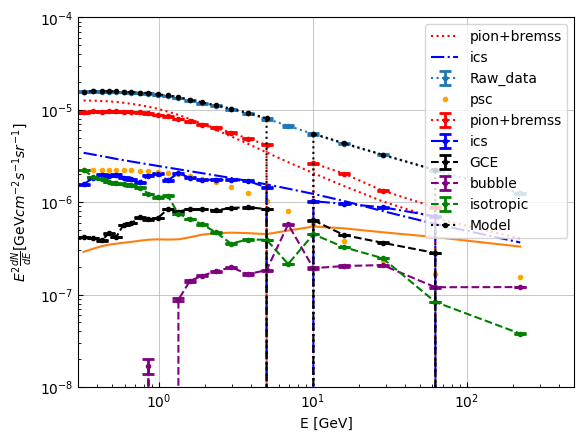

In [270]:
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
plt.style.use('default')
ax=plt.subplot()

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('E [GeV]')
ax.set_ylabel(r'$E^2 \frac{dN}{dE}$[GeV$cm^{-2}$$s^{-1} sr^{-1}$]')

ax.set_ylim(1e-8, 1e-4)
ax.set_xlim(0.3, 500)

ax.tick_params(axis='y', which='both', direction='in', left=True)
ax.tick_params(axis='x', which='both', direction='in', bottom=True)
ax.minorticks_on()
ax.grid(True, which='Major', linestyle='-', linewidth=0.5)

#m=minuit4
fitted=m.values[:]
fitted_errors=m.errors[:]
fitted=params

sr=0.214411*2

ax.errorbar(E*1e-3, counts_per_exp*(E**2)/(1000*delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(1000*delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')

#ax.plot(E*1e-3, psc*(E**2)/(1000*delta_E*sr))

ax.errorbar(E*1e-3, psc*(E**2)/(1000*delta_E*sr), linestyle='', marker='.', elinewidth=2, capsize=4, capthick=2, label='psc', color='orange')


ax.errorbar(E*1e-3, fitted[0:24]*(pion+bremss)*(E**2)/(1000*delta_E*sr), yerr=fitted_errors[0:24]*(pion+bremss)*(E**2)/(1000*delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='pion+bremss', color='red')
ax.errorbar(E*1e-3, fitted[24:48]*(ics)*(E**2)/(1000*delta_E*sr), yerr=fitted_errors[24:48]*(ics)*(E**2)/(1000*delta_E*sr), linestyle='dashdot', marker='.', elinewidth=2, capsize=4, capthick=2, label='ics', color='blue')

ax.plot(E*1e-3, (pion+bremss)*(E**2)/(1000*delta_E*sr), linestyle='dotted', label='pion+bremss', color='red')

ax.plot(E*1e-3, (ics)*(E**2)/(1000*delta_E*sr), linestyle='dashdot', label='ics', color='blue')



ax.errorbar(E*1e-3,  fitted[48:72]*(GCE)*(E**2)/(1000*delta_E*sr), yerr=np.sqrt((fitted_errors[48:72]*GCE)**2)*(E**2)/(1000*delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')



ax.errorbar(E*1e-3, fitted[72:96]*(bubble)*(E**2)/(1000*delta_E*sr),yerr=fitted_errors[72:96]*(bubble)*(E**2)/(1000*delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='bubble', color='purple')
ax.plot(E*1e-3, bubble*(E**2)/(1000*delta_E*sr) )


ax.errorbar(E*1e-3, fitted[96:120]*(isotropic)*(E**2)/(1000*delta_E*sr),yerr=fitted_errors[96:120]*(isotropic)*(E**2)/(1000*delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='isotropic', color='green')


summed=fitted[0:24]*(pion+bremss) + fitted[24:48]*(ics) + fitted[48:72]*(GCE) + fitted[72:96]*(bubble) + fitted[96:120]*(isotropic) + psc

ax.errorbar(E*1e-3, summed*(E**2)/(1000*delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Model', color='black')

ax.legend()

In [ ]:
#Weak masking test